# Machine Learning for Drug Design — Final Project
## Lipophilicity (logD) Prediction
### Group 1 | Lipophilicity_AstraZeneca Dataset

---

## Project Overview

Lipophilicity — the ability of a drug molecule to dissolve in a lipid (fatty) environment relative to water — is one of the most critical physicochemical properties in drug design. It directly influences **Absorption**, **Distribution**, **Metabolism**, and **Excretion (ADME)** properties of a drug candidate:

- **High lipophilicity** → better membrane permeability, but poor aqueous solubility, high metabolic turnover, and risk of toxicity
- **Low lipophilicity** → good solubility, but poor absorption across biological membranes

The target property in this project is the **octanol/water distribution coefficient logD** (Wu et al., 2018; Huang et al., 2021), which  accounts for the ionization state of the molecule at physiological conditions — making it more biologically relevant than the simple partition coefficient logP, which assumes a fully neutral molecule (Avdeef, 2003).

The **AstraZeneca Lipophilicity dataset** (AstraZeneca, 2016), curated from experimental measurements on a set of publicly disclosed compounds and published as part of the MoleculeNet benchmark suite (Wu et al., 2018), contains 4,200 drug-like molecules with experimentally measured logD values at pH 7.4. It is one of the most widely used benchmarks for molecular property prediction in the literature.

---

## Scientific Objectives

This project applies the machine learning concepts and methods covered throughout the ML4DD course to develop, compare, and critically evaluate multiple predictive models for lipophilicity. Specifically, we aim to:

1. **Explore molecular representations** — compare binary fingerprints (MACCS, Morgan/ECFP4, RDKit FP) and physicochemical descriptors as input features
2. **Evaluate splitting strategies** — assess the impact of random vs. scaffold-based splitting on model performance, connecting to the concept of applicability domain
3. **Perform principled feature selection** — apply Clustered Forward Selection (CFS) (among others) to identify non-redundant physicochemical descriptors, separately for each model
4. **Compare multiple ML models** — Linear Regression, Random Forest, and XGBoost, trained on each encoding and evaluated on both splits
5. **Analyse model performance vs. chemical similarity** — test predictions on subsets of the test set grouped by their structural similarity to the training set
6. **Provide explainable predictions** — use Permutation Feature Importance (PFI) to identify which molecular features drive lipophilicity predictions
7. **Define an applicability domain** — flag predictions on molecules that are structurally dissimilar from the training set as less reliable

The methods applied throughout this project are grounded in the practical sessions 
of the ML4DD course, drawing on molecular representations (Sessions 1–2), graph-based models (Session 3), advanced splitting and learning curves (Session 5), and feature selection for model interpretability (Session 6).

---

## References

- AstraZeneca. Experimental in vitro DMPK and physicochemical data on a set of publicly disclosed compounds (2016).
- Avdeef A. Absorption and Drug Development. Wiley (2003).
- Huang K. et al. Therapeutics Data Commons: Machine Learning Datasets and Tasks for Drug Discovery and Development. NeurIPS (2021)
- Wu Z. et al. MoleculeNet: a benchmark for molecular machine learning. Chemical Science 9.2 (2018): 513–530.
- Schroeter T.S. et al. Predicting lipophilicity of drug-discovery molecules using Gaussian process models. ChemMedChem 2.10 (2007): 1533–1541.
- Lenselink E.B. & Stouten P.F.W. Multitask machine learning models for predicting lipophilicity (logP) in the SAMPL7 challenge. J. Comput.-Aided Mol. Des. 35 (2021): 901–909.
- Gleeson M.P. et al. "Probing the links between in vitro potency, ADMET and physicochemical parameters for the design of CNS drugs." J. Med. Chem. 54.20 (2011): 6844–6853.
- Seedat N. et al. DC-Check: A Data-Centric AI Checklist to Guide the Development of Reliable Machine Learning Systems. arXiv:2211.05764 (2022).
- Rogers D. & Hahn M. Extended-Connectivity Fingerprints. J. Chem. Inf. Model. 50.5 (2010): 742–754.
- Lipinski C.A. et al. Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings. Adv. Drug Deliv. Rev. 46 (2001): 3–26.
- McInnes L. et al. UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction. arXiv:1802.03426 (2018).

## Section 1 — Imports & Setup

We configure RDKit drawing settings and suppress verbose logs. All imports are collected here to ensure reproducibility and avoid scattered dependencies.

Key libraries:
- `rdkit` — cheminformatics: SMILES parsing, fingerprints, descriptors (Sessions 1–3)
- `tdc` — Therapeutic Data Commons: standardized dataset access and splits (Session 5)
- `pandas`, `numpy` — tabular data manipulation and numerical computing
- `sklearn` — machine learning models, metrics, cross-validation (Sessions 3, 5, 6)
- `xgboost` — gradient boosted trees for regression
- `scipy` — Spearman correlation for feature selection (Session 6)
- `matplotlib`, `seaborn` — data visualization

In [63]:
# ── Imports ───────────────────────────────────────────────────────────────────

# ── TDC ───────────────────────────────────────────────────────────────────────
from tdc.single_pred import ADME

# ── RDKit ─────────────────────────────────────────────────────────────────────
from rdkit import Chem, RDLogger
from rdkit.Chem import (
    Draw, rdMolDescriptors, Descriptors, Crippen,
    MACCSkeys, RDKFingerprint, AllChem,
    Lipinski, GraphDescriptors, Fragments, QED,
    rdDepictor
)
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator, AdditionalOutput
from rdkit.Chem.rdMolDescriptors import (
    CalcTPSA, CalcKappa1, CalcKappa2, CalcKappa3,
    CalcChi0v, CalcChi1v, CalcChi2v, CalcChi3v, CalcChi4v,
    CalcChi0n, CalcChi1n, CalcChi2n, CalcChi3n, CalcChi4n,
)
from rdkit.DataStructs import ExplicitBitVect, BulkTanimotoSimilarity

# ── General ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from xgboost import XGBRegressor

# ── RDKit Configuration ───────────────────────────────────────────────────────
RDLogger.DisableLog('rdApp.*')
IPythonConsole.ipython_useSVG = True
rdDepictor.SetPreferCoordGen(True)

## Section 2 — Data Loading

The **Lipophilicity_AstraZeneca** dataset is accessed via PyTDC (`tdc.single_pred.ADME`), which provides standardized train/validation/test splits 
using both **random** and **scaffold** splitting strategies, following TDC's default 70/10/20 ratio (Huang et al., 2021).

### Why two splitting strategies?

As covered in Session 5 (Advanced Splitting and Learning Curves), the choice of splitting strategy fundamentally changes what the model is asked to do:

- **Random split**: molecules are assigned randomly to partitions. Structurally similar molecules can appear in both train and test, leading to *optimistic* performance estimates. This is an important baseline but does not reflect real-world deployment.

- **Scaffold split**: molecules are grouped by their **Murcko scaffold** — the core ring system stripped of side chains. Entire scaffold groups are assigned to one partition only, ensuring that test molecules belong to chemical series never seen during training. This is a more *realistic* and *challenging* evaluation that better simulates the drug discovery scenario where models must predict properties of novel chemical series.

The scaffold split is the **primary evaluation metric** for this project, consistent with the MoleculeNet benchmark (Wu et al., 2018) and standard practice in the field.

In this section, both splits are loaded and stored separately for later use. All molecules are combined into a single working DataFrame for cleaning and featurization. The target distribution is visualised below.

Found local copy...
Loading...
Done!
100%|██████████| 4200/4200 [00:03<00:00, 1370.47it/s]


Total molecules loaded: 4200
Columns: ['Drug_ID', 'Drug', 'Y']

Random split  — Train: 2940, Val: 420, Test: 840
Scaffold split — Train: 2940, Val: 420, Test: 840


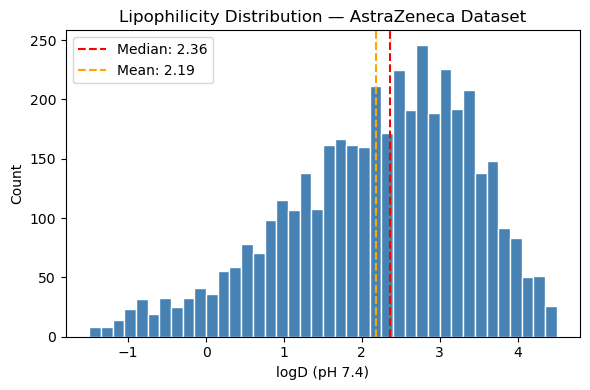

,Drug_ID,Drug,Y
0,CHEMBL596271,Cn1c(CN2CCN(c3ccc(Cl)cc3)CC2)nc2ccccc21,3.54
1,CHEMBL1951080,COc1cc(OC)c(S(=O)(=O)N2c3ccccc3CCC2C)cc1NC(=O)...,-1.18
2,CHEMBL1771,COC(=O)[C@H](c1ccccc1Cl)N1CCc2sccc2C1,3.69
3,CHEMBL317462,OC1(C#Cc2ccc(-c3ccccc3)cc2)CN2CCC1CC2,3.14
4,CHEMBL1940306,CS(=O)(=O)c1ccc(Oc2ccc(C#C[C@]3(O)CN4CCC3CC4)c...,1.51


In [64]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
data = ADME(name='Lipophilicity_AstraZeneca')

# Random split (optimistic baseline)
split_random = data.get_split(method='random')
df_train_r = split_random['train']
df_valid_r = split_random['valid']
df_test_r  = split_random['test']

# Scaffold split (primary evaluation)
split_scaffold = data.get_split(method='scaffold')
df_train_s = split_scaffold['train']
df_valid_s = split_scaffold['valid']
df_test_s  = split_scaffold['test']

# Combined dataframe for cleaning (all unique molecules)
df = pd.concat([df_train_r, df_valid_r, df_test_r], axis=0)
df.reset_index(drop=True, inplace=True)

print(f"Total molecules loaded: {df.shape[0]}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nRandom split  — Train: {len(df_train_r)}, Val: {len(df_valid_r)}, Test: {len(df_test_r)}")
print(f"Scaffold split — Train: {len(df_train_s)}, Val: {len(df_valid_s)}, Test: {len(df_test_s)}")

# Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['Y'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(df['Y'].median(), color='red', linestyle='--',
           label=f'Median: {df["Y"].median():.2f}')
ax.axvline(df['Y'].mean(), color='orange', linestyle='--',
           label=f'Mean: {df["Y"].mean():.2f}')
ax.set_xlabel('logD (pH 7.4)')
ax.set_ylabel('Count')
ax.set_title('Lipophilicity Distribution — AstraZeneca Dataset')
ax.legend()
plt.tight_layout()
plt.show()

# Preview dataset
display(df.head())

As shown above, the dataset contains **4,200 drug-like molecules** with a single continuous target variable (logD at pH 7.4), split into train/validation/test sets of **2,940 / 420 / 840** molecules (70/10/20) for both random and scaffold splits. As expected, the two splitting strategies produce partitions of equal size — they differ in *which* molecules are assigned to each partition, not *how many*.

The logD distribution is approximately bell-shaped and slightly left-skewed, with a mean of 2.19 and a median of 2.36, spanning a range of approximately −1.5 to 4.5. The small difference between mean and median confirms the mild left skew. This range is typical of drug-like compounds, where moderately lipophilic molecules (logD 1–3) are most common — consistent with Lipinski's Rule of Five guideline of logP ≤ 5 (Lipinski et al., 2001). The dataset presents a well-posed regression problem (as suggested by TDC) with no extreme outliers and a continuous, unimodal target distribution.

## Section 3 — Data Cleaning & Exploratory Data Analysis

### Data Cleaning
Following the data cleaning pipeline established in Sessions 1, 3, and 5, we perform three verification steps:

1. **SMILES validity**: convert each SMILES string to an RDKit molecule object using `Chem.MolFromSmiles()`. Invalid SMILES (returning `None`) are removed.
2. **Canonicalization**: convert all SMILES to their canonical form using `Chem.MolToSmiles(mol, canonical=True)`. As covered in Session 1, the same molecule can be represented by many different SMILES strings — canonicalization ensures a unique representation for each molecule.
3. **Deduplication**: remove molecules with identical canonical SMILES, keeping only the first occurrence.

The AstraZeneca dataset is already well-curated, so we expect minimal removals. This step is nonetheless important as good ML practice — verifying 
data quality rather than assuming it, in line with the Data-Centric AI principles discussed in Session 3 (Seedat et al., 2022).

**Note on outlier removal**: unlike some other molecular datasets, we do not apply any logD range filter. The measured values (approximately −1.5 to 4.5) are all physically meaningful for drug-like molecules, and the dataset was carefully curated by AstraZeneca prior to publication (AstraZeneca, 2016). Removing extreme values would bias the model toward "average" drug-like molecules and reduce our ability to predict the full range of lipophilicity.

### Exploratory Data Analysis

Following data cleaning, we explore the dataset to understand its chemical composition and the distribution of key molecular properties. This provides context for the modelling choices that follow — particularly the relationship between logP and logD which foreshadows the feature importance findings in later sections.

We focus on the **Lipinski Rule of Five** descriptors (Lipinski et al., 2001) — logP, molecular weight, TPSA, H-bond donors, H-bond acceptors and rotatable bonds — as these are the most fundamental physicochemical properties in drug design and provide a quick overview of whether the dataset contains typical drug-like molecules.

In [65]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────
n_rows_raw = df.shape[0]

# Step 1: Convert SMILES to RDKit mol objects, drop invalid SMILES
df['mol'] = df['Drug'].apply(Chem.MolFromSmiles)
df.dropna(subset=['mol'], inplace=True)
n_rows_after_invalid = df.shape[0]

# Step 2: Canonicalize SMILES
df['canonical_SMILES'] = df['mol'].apply(
    lambda x: Chem.MolToSmiles(x, canonical=True)
)

# Step 3: Drop duplicate canonical SMILES
df.drop_duplicates(subset='canonical_SMILES', keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
n_rows_after_dedup = df.shape[0]

# Report
print(f"Rows raw:                  {n_rows_raw}")
print(f"Rows after invalid SMILES: {n_rows_after_invalid}  "
      f"(removed {n_rows_raw - n_rows_after_invalid})")
print(f"Rows after deduplication:  {n_rows_after_dedup}  "
      f"(removed {n_rows_after_invalid - n_rows_after_dedup})")

Rows raw:                  4200
Rows after invalid SMILES: 4200  (removed 0)
Rows after deduplication:  4200  (removed 0)


As expected from a well-curated dataset, no molecules were removed — all 4,200 SMILES are valid and unique. We first compute the basic molecular properties and visualise the logD target distribution before moving on to featurization.


logD (pH 7.4) — Basic Statistics:
  Mean:   2.186
  Median: 2.360
  Std:    1.203
  Min:    -1.500
  Max:    4.500


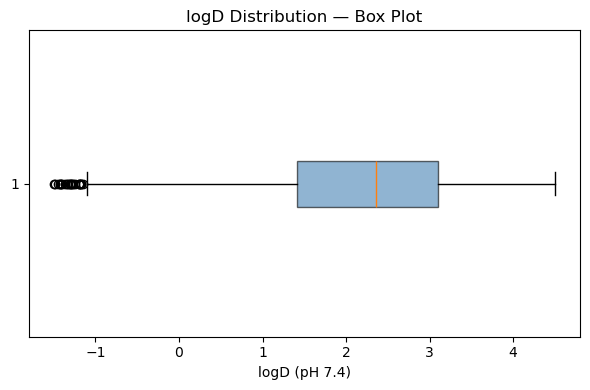

In [66]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────────

# Compute basic molecular properties
df['logp']      = df['mol'].apply(Crippen.MolLogP)
df['mol_wt']    = df['mol'].apply(Descriptors.MolWt)
df['tpsa']      = df['mol'].apply(Descriptors.TPSA)
df['hbd']       = df['mol'].apply(Descriptors.NumHDonors)
df['hba']       = df['mol'].apply(Descriptors.NumHAcceptors)
df['rot_bonds'] = df['mol'].apply(Descriptors.NumRotatableBonds)

# ── 1. Basic statistics of logD ───────────────────────────────────────────────
print("\nlogD (pH 7.4) — Basic Statistics:")
print(f"  Mean:   {df['Y'].mean():.3f}")
print(f"  Median: {df['Y'].median():.3f}")
print(f"  Std:    {df['Y'].std():.3f}")
print(f"  Min:    {df['Y'].min():.3f}")
print(f"  Max:    {df['Y'].max():.3f}")

# Plot distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df['Y'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_xlabel('logD (pH 7.4)')
ax.set_title('logD Distribution — Box Plot')
plt.tight_layout()
plt.show()

The logD distribution spans from −1.5 to 4.5 with a mean of 2.19 and median of 2.36 — the small difference between mean and median indicates a mild left skew, visible in the box plot where a few outliers extend toward negative values. The interquartile range covers approximately 1.3 to 3.0, consistent with a dataset of typical drug-like molecules where moderate lipophilicity is most common (Lipinski et al., 2001).

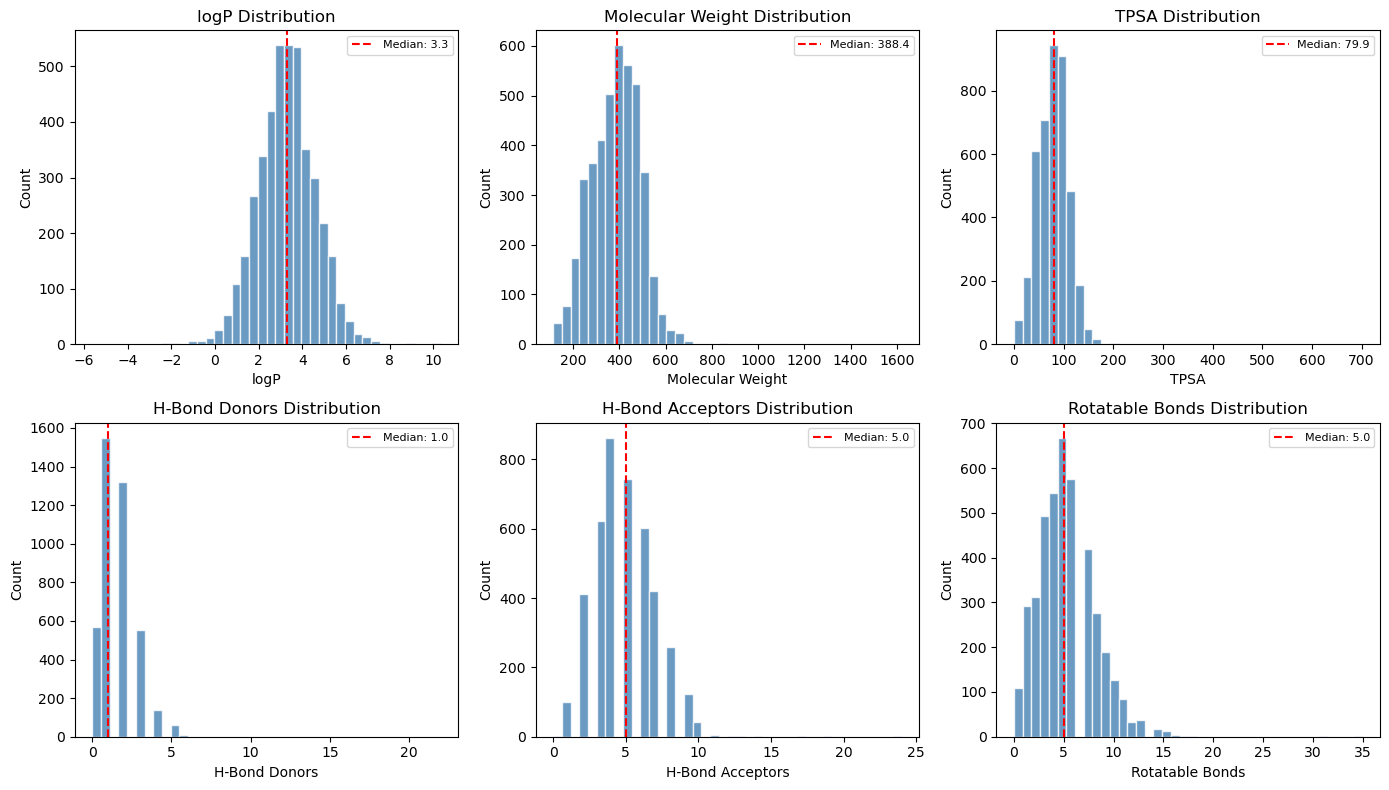

In [67]:
# ── 2. Molecular properties distributions ─────────────────────────────────────
props = {
    'logP':             'logp',
    'Molecular Weight': 'mol_wt',
    'TPSA':             'tpsa',
    'H-Bond Donors':    'hbd',
    'H-Bond Acceptors': 'hba',
    'Rotatable Bonds':  'rot_bonds',
}

# Plot histograms with median lines
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (title, col) in zip(axes.flatten(), props.items()):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].median(), color='red', linestyle='--',
               label=f'Median: {df[col].median():.1f}')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Distribution')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The molecular property distributions confirm that the dataset contains typical drug-like molecules. The majority of compounds satisfy Lipinski's Rule of Five (Lipinski et al., 2001): median molecular weight of 388.4 Da (well below 500 Da), median H-bond donors of 1 (≤5), median H-bond acceptors of 5 (≤10), and median logP of 3.3 (≤5). TPSA is tightly distributed around a median of 79.9 Ų and rotatable bonds around 5, both consistent with orally bioavailable drug candidates. Most distributions show right-skewed tails indicating a small number of larger, more polar or more flexible outliers — consistent with the few low logD outliers observed in the box plot above.

Since logP and logD both measure lipophilicity and are closely related, we expect some correlation between them. We visualise this relationship directly to understand how much of the logD variance can be explained by logP alone — this will help motivate the need for additional features beyond logP in our predictive models.

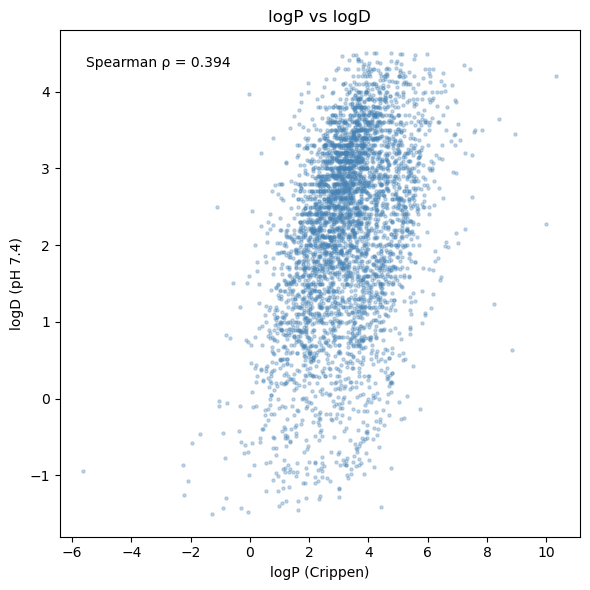


Spearman correlation between logP and logD: 0.394


In [68]:
# ── 3. logP vs logD scatter plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['logp'], df['Y'], alpha=0.3, s=5, color='steelblue')
ax.set_xlabel('logP (Crippen)')
ax.set_ylabel('logD (pH 7.4)')
ax.set_title('logP vs logD')

corr = df[['logp', 'Y']].corr(method='spearman').iloc[0, 1]
ax.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top')

plt.tight_layout()
plt.show()

print(f"\nSpearman correlation between logP and logD: {corr:.3f}")

The logP vs logD scatter plot reveals a moderate positive Spearman correlation (ρ=0.394), confirming that logP is informative for predicting logD but far from perfectly predictive. The wide vertical spread at any given logP value reflects the influence of ionization at pH 7.4 — molecules with the same logP can have very different logD values depending on their ionization state. This suggests that logP alone is not sufficient for accurate logD prediction, and that additional descriptors capturing polarity, charge and functional group composition will be needed to achieve competitive predictive performance.

## Section 4 — Helper Functions

This section defines all featurization functions used throughout the notebook. These are based directly on the implementations from Sessions 2 and 6.

### Molecular Fingerprints (Session 2)

Molecular fingerprints encode structural information as fixed-length binary vectors. We implement three types:

**MACCS Keys** (`smiles2maccs`)
- Type: Structural key fingerprint
- 166 predefined substructure patterns (167 bits in RDKit for compatibility)
- Each bit represents the presence/absence of a specific functional group or structural motif
- Pros: interpretable, compact, fast; Cons: limited expressiveness

**Morgan Fingerprint / ECFP4** (`smiles2morgan`)
- Type: Circular fingerprint (Extended Connectivity)
- Radius 2, 1024 bits → equivalent to ECFP4 (diameter = 4)
- Encodes atom-centred circular neighbourhoods up to a specified radius
- Most widely used fingerprint in the ML4DD literature for property prediction
- Pros: captures local chemical environment; Cons: bit collisions at small sizes

**RDKit Fingerprint** (`smiles2rdkfp`)
- Type: Path-based fingerprint
- 2048 bits, maxPath=7
- Encodes all linear paths in a molecule up to a specified bond length
- Pros: general-purpose; Cons: high dimensionality can cause issues with linear models

### Extended Physicochemical Descriptors (Session 6)

The `smiles2physchem_extended` function computes ~100 continuous molecular descriptors organized into correlated groups:
- Lipophilicity descriptors (logP variants)
- Molecular size/weight descriptors
- Hydrogen bonding descriptors
- Polarity and surface area descriptors
- Flexibility and shape descriptors
- Topological indices
- Ring system descriptors
- Atom-type counts
- Charge/electronic properties
- Drug-likeness descriptors
- Fragment/functional group counts

This large, intentionally redundant descriptor set serves as input to the feature selection we will do later on, where we use Clustered Forward Selection to identify the minimal non-redundant subset for each model.

### Feature Selection Helper Functions (Session 6)

- `spearman_corr_matrix()`: computes pairwise Spearman correlation between features
- `permutation_importance_df()`: computes Permutation Feature Importance (PFI), measuring the drop in R² when each feature is randomly shuffled
- `forward_selection()`: greedy wrapper that adds the feature maximising CV R² at each step
- `clustered_forward_selection()`: extension of forward selection that first groups correlated features into clusters and considers only one candidate per cluster at each round, enforcing diversity in the selected feature set

### `apply_featurizer()` (Sessions 2, 5)

A general-purpose utility that applies any featurization function row-wise to a DataFrame column containing SMILES strings, returning a feature matrix as a DataFrame with consistent column naming.

In [ ]:
def apply_featurizer(df, featurizer, col_name_smiles='SMILES', features_name=None, return_concat=False):
    """
    Apply a featurizer function to a SMILES column in a DataFrame and return the resulting feature matrix.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing a column with SMILES strings.
        
    featurizer : callable
        A function applied to each SMILES string. It must return a fixed-length
        iterable (e.g., list, tuple, numpy array) of numerical features.
        
    col_name_smiles : str, default='SMILES'
        Name of the column in `df` containing SMILES strings.
        
    features_name : str or list of str, optional, default=None
        If a string is provided, feature columns will be named
        `{features_name}_0`, `{features_name}_1`, ..., `{features_name}_n`.
        
        If a list of strings is provided, it must match the number of generated
        features exactly and will be used as column names.
        
        If None, columns will be named `feature_0`, `feature_1`, ..., `feature_n`.
        
    return_concat : bool, default=False
        If True, returns the original DataFrame concatenated with the generated
        feature columns. If False, returns only the feature DataFrame.

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing the generated features, or the concatenation
        of the original DataFrame and the features if `return_concat=True`.

    Raises
    ------
    ValueError
        If `features_name` is a list and its length does not match the number
        of generated features.

    Notes
    -----
    - The `featurizer` must return a fixed-length iterable for every input.
      Inconsistent feature lengths will raise errors when constructing the
      DataFrame.
    - The index of the returned DataFrame matches the index of the input `df`.
    - This function applies the featurizer row-wise using `pandas.Series.apply`,
      which may be slow for very large datasets.
    """

    features_df = pd.DataFrame(df[col_name_smiles].apply(featurizer).tolist(), index=df.index)
    
    if isinstance(features_name, str):
        features_df.columns = [f'{features_name}_{i}' for i in range(features_df.shape[1])]
    elif isinstance(features_name, list):
        if len(features_name) != features_df.shape[1]:
            raise ValueError(f"Length of features_name ({len(features_name)}) does not match number of features ({features_df.shape[1]})")
        features_df.columns = features_name
    else:
        features_df.columns = [f'feature_{i}' for i in range(features_df.shape[1])]
    
    if return_concat:
        return pd.concat([df, features_df], axis=1)
    else:
        return features_df

def smiles2physchem(smiles: str) -> list:
    """
    Compute basic physicochemical features from a molecule's SMILES string.

    Parameters
    ----------
    smiles : str
        A SMILES (Simplified Molecular Input Line Entry System) string representing a chemical molecule.

    Returns
    -------
    list
        A list of 10 physicochemical descriptors in the following order:
        
        1. **logP** (float) – Octanol-water partition coefficient, indicating hydrophobicity. Higher values mean more lipophilic.
        2. **Molecular Weight** (float) – Total molecular mass of the molecule.
        3. **H-Bond Donors** (int) – Number of hydrogen bond donor groups (e.g., –OH, –NH).
        4. **H-Bond Acceptors** (int) – Number of hydrogen bond acceptor atoms (e.g., O, N).
        5. **TPSA** (float) – Topological polar surface area; correlates with drug absorption and permeability.
        6. **Number of Rotatable Bonds** (int) – Flexibility of the molecule; affects conformational freedom.
        7. **Exact Molecular Weight** (float) – Exact mass of the molecule, considering isotopes.
        8. **Number of Aromatic Rings** (int) – Count of aromatic ring structures in the molecule.
        9. **Number of Heteroatoms** (int) – Atoms other than carbon and hydrogen (e.g., N, O, S, P).
        10. **Number of Aliphatic Rings** (int) – Count of non-aromatic ring structures.

    Notes
    -----
    - If the SMILES string cannot be parsed, the function returns a list of 10 `None` values.
    - This function uses RDKit descriptors (`Chem`, `Descriptors`, `Crippen`, `rdMolDescriptors`).
    - Output: ['logp', 'mol_wt', 'hbond_donor', 'hbond_acceptor', 'tpsa', 'num_rotatable_bonds', 'molecular_volume', 'num_aromatic_rings', 'num_heteroatoms', 'num_aliphatic_rings']
    """
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return [None] * 10

    logp = Crippen.MolLogP(molecule)
    mol_wt = Descriptors.MolWt(molecule)
    hbond_donor = Descriptors.NumHDonors(molecule)
    hbond_acceptor = Descriptors.NumHAcceptors(molecule)
    tpsa = rdMolDescriptors.CalcTPSA(molecule)
    num_rotatable_bonds = Descriptors.NumRotatableBonds(molecule)
    molecular_volume = Descriptors.ExactMolWt(molecule)
    num_aromatic_rings = Descriptors.NumAromaticRings(molecule)
    num_heteroatoms = Descriptors.NumHeteroatoms(molecule)
    num_aliphatic_rings = Descriptors.NumAliphaticRings(molecule)

    return [logp, mol_wt, hbond_donor, hbond_acceptor, tpsa, num_rotatable_bonds, molecular_volume, num_aromatic_rings, num_heteroatoms, num_aliphatic_rings]

def smiles2morgan(smiles: str, radius: int = 2, fpSize: int = 2048, return_bitInfo: bool = False) -> list:
    """
    Convert a SMILES string into a Morgan fingerprint vector, with optional bit information.

    This function takes a molecular SMILES string, generates the corresponding
    molecule object, and computes its Morgan fingerprint (circular fingerprint)
    as a binary vector of a specified size. Optionally, it can also return the
    mapping of bits to atom environments used to generate the fingerprint.

    Parameters
    ----------
    smiles : str
        A SMILES (Simplified Molecular Input Line Entry System) string
        representing the molecule.
    radius : int, optional, default=2
        The radius of the Morgan fingerprint, defining how many bonds from
        each atom are considered when generating substructures.
    fpSize : int, optional, default=2048
        The size (length) of the output fingerprint vector.
    return_bitInfo : bool, optional, default=False
        If True, also return a dictionary mapping fingerprint bits to the
        atom environments that contributed to them.

    Returns
    -------
    list or tuple
        - If `return_bitInfo` is False, returns a list of integers (0 or 1)
          representing the binary Morgan fingerprint.
        - If `return_bitInfo` is True, returns a tuple `(fingerprint, bitInfoMap)`:
            - `fingerprint`: list of integers (0 or 1) of length `fpSize`
            - `bitInfoMap`: dictionary mapping each bit index to information about
              the atoms/substructures that set that bit.

        If the SMILES string is invalid or cannot be parsed, returns a list
        of `None` values of length `fpSize`.
    """
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return [None] * fpSize
    generator = GetMorganGenerator(radius=radius, fpSize=fpSize)

    if return_bitInfo:
        ao = AdditionalOutput()
        ao.AllocateBitInfoMap()
        fp = list(generator.GetFingerprint(molecule, additionalOutput=ao))
        return fp,ao.GetBitInfoMap()
    else:
        fp = list(generator.GetFingerprint(molecule))
        return fp

def smiles2maccs(smiles: str) -> list:
    """
    Generate the MACCS fingerprint for a molecule from its SMILES string.

    Parameters
    ----------
    smiles : str
        A SMILES (Simplified Molecular Input Line Entry System) string representing a chemical molecule.

    Returns
    -------
    list
        A list of 167 bits representing the MACCS structural keys fingerprint of the molecule.
        - Each bit is 0 or 1, indicating the presence or absence of a particular structural feature.
        - The MACCS keys capture common chemical substructures, rings, and functional groups.

    Notes
    -----
    - If the SMILES string cannot be parsed, the function returns a list of 167 `None` values.
    - This function uses RDKit's `MACCSkeys` module to generate the fingerprints.
    - MACCS fingerprints are widely used in cheminformatics for similarity searches and machine learning tasks.

    Examples
    --------
    >>> smiles2maccs('CCO')
    [0, 0, 0, 1, 0, 0, 0, ..., 0]  # 167 bits representing ethanol
    """
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return [None] * 167
    return list(MACCSkeys.GenMACCSKeys(molecule))

def smiles2rdkfp(smiles: str, fpSize: int = 2048, maxPath: int = 7, return_bitInfo: bool = False) -> list:
    """
    Convert a SMILES string into an RDKit topological (RDK) fingerprint.

    Parameters
    ----------
    smiles : str
        A SMILES string representing the molecule to be fingerprinted.
    fpSize : int, optional (default=2048)
        The size (number of bits) of the resulting fingerprint.
    maxPath : int, optional (default=7)
        The maximum path length (in bonds) considered when generating the fingerprint.
    return_bitInfo : bool, optional (default=False)
        If True, also return a dictionary mapping fingerprint bits to the atom paths that set them.

    Returns
    -------
    list
        A list of integers (0 or 1) representing the fingerprint bits. If `return_bitInfo=True`, 
        returns a tuple `(fingerprint_list, bitInfo)` where `bitInfo` is a dictionary 
        of the form `{bit_id: [(atom_idx1, atom_idx2, ...), ...]}` mapping bits to the atom paths that contributed to them.

    Notes
    -----
    - If the SMILES string is invalid or cannot be parsed, the function returns a list of `np.nan` 
      values with length equal to `fpSize`.
    - The `bitInfo` dictionary is only populated if `return_bitInfo=True`.
    - This function uses RDKit's `RDKFingerprint` for generating topological fingerprints.

    """
    bitInfo = {}
    try:
        molecule = Chem.MolFromSmiles(smiles)
        if return_bitInfo:
            fp = RDKFingerprint(molecule, fpSize = fpSize, maxPath = maxPath, bitInfo = bitInfo)
        else:
            fp = RDKFingerprint(molecule, fpSize = fpSize, maxPath = maxPath)
        out = list(fp)
    except:
        out = [np.nan]*fpSize
    
    if return_bitInfo:
        return out,bitInfo
    else:
        return out


DESCRIPTOR_NAMES = [
    # --- Lipophilicity (correlated group) ---
    'logp',                       # Wildman-Crippen octanol-water partition coefficient
    'molar_refractivity',         # Crippen molar refractivity
    'logp_rdkit',                 # RDKit built-in logP; slightly different implementation

    # --- Molecular Weight & Size (correlated group) ---
    'mol_wt',                     # Average molecular weight based on atomic masses
    'heavy_atom_mol_wt',          # Molecular weight of heavy (non-H) atoms only
    'heavy_atom_count',           # Number of non-hydrogen atoms
    'num_atoms',                  # Total atom count including explicit hydrogens
    'num_heavy_atoms',            # Heavy atom count via rdMolDescriptors

    # --- Hydrogen Bonding (correlated group) ---
    'hbond_donor',                # Lipinski H-bond donor count (-OH, -NH groups)
    'hbond_acceptor',             # Lipinski H-bond acceptor count (O, N atoms)
    'hbond_donor_rdkit',          # RDKit H-bond donor count; slightly stricter definition
    'hbond_acceptor_rdkit',       # RDKit H-bond acceptor count; slightly stricter definition

    # --- Polarity & Surface Area (correlated group) ---
    'tpsa',                       # Topological polar surface area
    'labute_asa',                 # Labute approximate surface area
    'peoe_vsa1',                  # Surface area contribution from atoms with PEOE partial charge in bin 1
    'peoe_vsa2',                  # Surface area contribution from atoms with PEOE partial charge in bin 2
    'peoe_vsa3',                  # Surface area contribution from atoms with PEOE partial charge in bin 3
    'peoe_vsa4',                  # Surface area contribution from atoms with PEOE partial charge in bin 4
    'peoe_vsa5',                  # Surface area contribution from atoms with PEOE partial charge in bin 5
    'peoe_vsa6',                  # Surface area contribution from atoms with PEOE partial charge in bin 6
    'slogp_vsa1',                 # Surface area contribution from atoms with SlogP contribution in bin 1
    'slogp_vsa2',                 # Surface area contribution from atoms with SlogP contribution in bin 2
    'slogp_vsa3',                 # Surface area contribution from atoms with SlogP contribution in bin 3
    'smr_vsa1',                   # Surface area contribution from atoms with SMR contribution in bin 1
    'smr_vsa2',                   # Surface area contribution from atoms with SMR contribution in bin 2
    'smr_vsa3',                   # Surface area contribution from atoms with SMR contribution in bin 3

    # --- Flexibility & Shape ---
    'num_rotatable_bonds',        # Number of rotatable bonds (Lipinski definition); measure of molecular flexibility
    'num_rotatable_bonds_rdkit',  # Number of rotatable bonds (RDKit definition)
    'kappa1',                     # Hall-Kier kappa index 1; encodes overall molecular shape and size
    'kappa2',                     # Hall-Kier kappa index 2; encodes degree of branching
    'kappa3',                     # Hall-Kier kappa index 3; encodes 3-atom branching patterns

    # --- Connectivity / Topological Indices (highly intercorrelated group) ---
    'chi0v',                      # Valence-weighted zeroth-order chi connectivity index
    'chi1v',                      # Valence-weighted first-order chi connectivity index
    'chi2v',                      # Valence-weighted second-order chi connectivity index
    'chi3v',                      # Valence-weighted third-order chi connectivity index
    'chi4v',                      # Valence-weighted fourth-order chi connectivity index
    'chi0n',                      # Non-H atom zeroth-order chi connectivity index
    'chi1n',                      # Non-H atom first-order chi connectivity index
    'chi2n',                      # Non-H atom second-order chi connectivity index
    'chi3n',                      # Non-H atom third-order chi connectivity index
    'chi4n',                      # Non-H atom fourth-order chi connectivity index
    'ipc',                        # Bonchev-Trinajstic information content index
    'bertz_ct',                   # Bertz complexity index
    'balaban_j',                  # Balaban J topological index; measures molecular branching and cyclicity
    'hallkier_alpha',             # Hall-Kier alpha correction; accounts for atom size deviations from carbon

    # --- Ring Systems (correlated group) ---
    'num_aromatic_rings',         # Number of aromatic rings
    'num_aliphatic_rings',        # Number of aliphatic (non-aromatic) rings
    'num_saturated_rings',        # Number of fully saturated rings; subset of num_aliphatic_rings
    'num_rings',                  # Total ring count (aromatic + aliphatic)
    'num_aromatic_carbocycles',   # Number of aromatic rings containing only carbon; subset of num_aromatic_rings
    'num_aromatic_heterocycles',  # Number of aromatic rings containing heteroatoms
    'num_aliphatic_carbocycles',  # Number of aliphatic carbocyclic rings; subset of num_aliphatic_rings
    'num_aliphatic_heterocycles', # Number of aliphatic rings containing heteroatoms
    'num_saturated_carbocycles',  # Number of saturated carbocyclic rings; subset of num_aliphatic_carbocycles
    'num_saturated_heterocycles', # Number of saturated heterocyclic rings; subset of num_aliphatic_heterocycles
    'ring_count',                 # Total ring count via rdMolDescriptors

    # --- Atom-Type Counts (correlated group) ---
    'num_heteroatoms',            # Total number of non-C, non-H atoms; sum of N, O, S, halogens etc.
    'num_nitrogen',               # Number of nitrogen atoms; subset of num_heteroatoms
    'num_oxygen',                 # Number of oxygen atoms; subset of num_heteroatoms
    'num_sulfur',                 # Number of sulfur atoms; subset of num_heteroatoms
    'num_halogens',               # Total number of halogen atoms (F+Cl+Br+I); subset of num_heteroatoms
    'num_fluorine',               # Number of fluorine atoms; subset of num_halogens
    'num_chlorine',               # Number of chlorine atoms; subset of num_halogens
    'num_bromine',                # Number of bromine atoms; subset of num_halogens
    'fraction_csp3',              # Fraction of sp3 carbons (Fsp3); measure of three-dimensionality

    # --- Charge & Electronic Properties ---
    'max_partial_charge',         # Maximum Gasteiger partial charge over all atoms
    'min_partial_charge',         # Minimum Gasteiger partial charge over all atoms
    'max_abs_partial_charge',     # Maximum absolute Gasteiger partial charge
    'min_abs_partial_charge',     # Minimum absolute Gasteiger partial charge

    # --- Drug-likeness ---
    'qed',                        # Quantitative estimate of drug-likeness (0-1); composite of multiple properties
    'num_lipinskihba',            # Lipinski H-bond acceptor count (explicit RDKit Lipinski definition)
    'num_lipinskihbd',            # Lipinski H-bond donor count (explicit RDKit Lipinski definition)
    'num_stereocenters',          # Number of stereocenters (assigned and unassigned)
    'num_spiro_atoms',            # Number of spiro atoms (atoms shared between two rings via one atom)
    'num_bridgehead_atoms',       # Number of bridgehead atoms (atoms shared between two rings via two+ bonds)

    # --- Fragment / Functional Group Counts (correlated with atom-type counts above) ---
    'fr_NH0',                     # Number of tertiary amines; subset of num_nitrogen
    'fr_NH1',                     # Number of secondary amines; subset of num_nitrogen
    'fr_NH2',                     # Number of primary amines; subset of num_nitrogen
    'fr_Al_OH',                   # Number of aliphatic hydroxyl groups; subset of num_oxygen
    'fr_Al_OH_noTert',            # Number of aliphatic hydroxyl groups excluding tertiary OH
    'fr_Ar_OH',                   # Number of aromatic hydroxyl groups (phenols); subset of num_oxygen
    'fr_ArN',                     # Number of N functional groups attached to aromatics; subset of num_nitrogen
    'fr_Ar_NH',                   # Number of aromatic amine groups
    'fr_C_O',                     # Number of C=O groups (aldehydes, ketones, acids, esters)
    'fr_C_O_noCOO',               # Number of C=O groups excluding carboxylic acids
    'fr_COO',                     # Number of carboxylate groups; subset of fr_C_O
    'fr_COO2',                    # Number of carboxylic acid groups
    'fr_Al_COO',                  # Number of aliphatic carboxylic acids; subset of fr_COO2
    'fr_Ar_COO',                  # Number of aromatic carboxylic acids; subset of fr_COO2
    'fr_halogen',                 # Number of halogen atoms via fragment matching
    'fr_alkyl_halide',            # Number of alkyl halide groups; subset of fr_halogen
    'fr_sulfonamd',               # Number of sulfonamide groups; subset of num_sulfur
    'fr_SH',                      # Number of thiol groups; subset of num_sulfur
    'fr_nitro',                   # Number of nitro groups
    'fr_nitro_arom',              # Number of aromatic nitro groups; subset of fr_nitro
    'fr_nitrile',                 # Number of nitrile groups; subset of num_nitrogen
    'fr_amide',                   # Number of amide groups
    'fr_ester',                   # Number of ester groups
    'fr_ether',                   # Number of ether groups
    'fr_ketone',                  # Number of ketone groups; subset of fr_C_O_noCOO
    'fr_aldehyde',                # Number of aldehyde groups; subset of fr_C_O_noCOO
]


def smiles2physchem_extended(smiles: str) -> list:
    """
    Compute an extended set of physicochemical and topological descriptors from a SMILES string.

    Intentionally includes correlated descriptor groups to serve as a starting point
    for feature selection exercises.

    Parameters
    ----------
    smiles : str
        A SMILES string representing a chemical molecule.

    Returns
    -------
    list
        A list of descriptor values in the order defined by DESCRIPTOR_NAMES.
        Returns a list of None values if the SMILES cannot be parsed.
    """
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return [None] * len(DESCRIPTOR_NAMES)

    AllChem.ComputeGasteigerCharges(molecule)

    def count_atoms(symbol):
        return sum(1 for atom in molecule.GetAtoms() if atom.GetSymbol() == symbol)

    return [
        # Lipophilicity
        Crippen.MolLogP(molecule),
        Crippen.MolMR(molecule),
        Descriptors.MolLogP(molecule),
        # Molecular Weight & Size
        Descriptors.MolWt(molecule),
        Descriptors.HeavyAtomMolWt(molecule),
        Descriptors.HeavyAtomCount(molecule),
        molecule.GetNumAtoms(),
        rdMolDescriptors.CalcNumHeavyAtoms(molecule),
        # Hydrogen Bonding
        Descriptors.NumHDonors(molecule),
        Descriptors.NumHAcceptors(molecule),
        rdMolDescriptors.CalcNumHBD(molecule),
        rdMolDescriptors.CalcNumHBA(molecule),
        # Polarity & Surface Area
        CalcTPSA(molecule),
        rdMolDescriptors.CalcLabuteASA(molecule),
        Descriptors.PEOE_VSA1(molecule),
        Descriptors.PEOE_VSA2(molecule),
        Descriptors.PEOE_VSA3(molecule),
        Descriptors.PEOE_VSA4(molecule),
        Descriptors.PEOE_VSA5(molecule),
        Descriptors.PEOE_VSA6(molecule),
        Descriptors.SlogP_VSA1(molecule),
        Descriptors.SlogP_VSA2(molecule),
        Descriptors.SlogP_VSA3(molecule),
        Descriptors.SMR_VSA1(molecule),
        Descriptors.SMR_VSA2(molecule),
        Descriptors.SMR_VSA3(molecule),
        # Flexibility & Shape
        Descriptors.NumRotatableBonds(molecule),
        rdMolDescriptors.CalcNumRotatableBonds(molecule),
        CalcKappa1(molecule),
        CalcKappa2(molecule),
        CalcKappa3(molecule),
        # Connectivity / Topological Indices
        CalcChi0v(molecule),
        CalcChi1v(molecule),
        CalcChi2v(molecule),
        CalcChi3v(molecule),
        CalcChi4v(molecule),
        CalcChi0n(molecule),
        CalcChi1n(molecule),
        CalcChi2n(molecule),
        CalcChi3n(molecule),
        CalcChi4n(molecule),
        GraphDescriptors.Ipc(molecule),
        GraphDescriptors.BertzCT(molecule),
        GraphDescriptors.BalabanJ(molecule),
        rdMolDescriptors.CalcHallKierAlpha(molecule),
        # Ring Systems
        Descriptors.NumAromaticRings(molecule),
        Descriptors.NumAliphaticRings(molecule),
        Descriptors.NumSaturatedRings(molecule),
        rdMolDescriptors.CalcNumAromaticRings(molecule) + rdMolDescriptors.CalcNumAliphaticRings(molecule),
        Descriptors.NumAromaticCarbocycles(molecule),
        Descriptors.NumAromaticHeterocycles(molecule),
        Descriptors.NumAliphaticCarbocycles(molecule),
        Descriptors.NumAliphaticHeterocycles(molecule),
        Descriptors.NumSaturatedCarbocycles(molecule),
        Descriptors.NumSaturatedHeterocycles(molecule),
        rdMolDescriptors.CalcNumRings(molecule),
        # Atom-Type Counts
        Descriptors.NumHeteroatoms(molecule),
        count_atoms('N'),
        count_atoms('O'),
        count_atoms('S'),
        count_atoms('F') + count_atoms('Cl') + count_atoms('Br') + count_atoms('I'),
        count_atoms('F'),
        count_atoms('Cl'),
        count_atoms('Br'),
        rdMolDescriptors.CalcFractionCSP3(molecule),
        # Charge & Electronic
        Descriptors.MaxPartialCharge(molecule),
        Descriptors.MinPartialCharge(molecule),
        Descriptors.MaxAbsPartialCharge(molecule),
        Descriptors.MinAbsPartialCharge(molecule),
        # Drug-likeness
        QED.qed(molecule),
        rdMolDescriptors.CalcNumLipinskiHBA(molecule),
        rdMolDescriptors.CalcNumLipinskiHBD(molecule),
        len(Chem.FindMolChiralCenters(molecule, includeUnassigned=True)),
        rdMolDescriptors.CalcNumSpiroAtoms(molecule),
        rdMolDescriptors.CalcNumBridgeheadAtoms(molecule),
        # Fragments
        Fragments.fr_NH0(molecule),
        Fragments.fr_NH1(molecule),
        Fragments.fr_NH2(molecule),
        Fragments.fr_Al_OH(molecule),
        Fragments.fr_Al_OH_noTert(molecule),
        Fragments.fr_Ar_OH(molecule),
        Fragments.fr_ArN(molecule),
        Fragments.fr_Ar_NH(molecule),
        Fragments.fr_C_O(molecule),
        Fragments.fr_C_O_noCOO(molecule),
        Fragments.fr_COO(molecule),
        Fragments.fr_COO2(molecule),
        Fragments.fr_Al_COO(molecule),
        Fragments.fr_Ar_COO(molecule),
        Fragments.fr_halogen(molecule),
        Fragments.fr_alkyl_halide(molecule),
        Fragments.fr_sulfonamd(molecule),
        Fragments.fr_SH(molecule),
        Fragments.fr_nitro(molecule),
        Fragments.fr_nitro_arom(molecule),
        Fragments.fr_nitrile(molecule),
        Fragments.fr_amide(molecule),
        Fragments.fr_ester(molecule),
        Fragments.fr_ether(molecule),
        Fragments.fr_ketone(molecule),
        Fragments.fr_aldehyde(molecule),
    ]


# HELPER FUNCTIONS
def spearman_corr_matrix(X: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the pairwise Spearman correlation matrix for all columns of X.

    Parameters
    ----------
    X : pd.DataFrame of shape (n_samples, n_features)
        Feature matrix. All columns must be numeric.

    Returns
    -------
    corr : pd.DataFrame of shape (n_features, n_features)
        Symmetric matrix of Spearman correlation coefficients in [-1, 1].
    """
    corr, _ = spearmanr(X)
    return pd.DataFrame(corr, index=X.columns, columns=X.columns)


def permutation_importance_df(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    n_repeats: int = 10,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Compute permutation feature importance and return a tidy DataFrame.

    Parameters
    ----------
    model : fitted sklearn estimator
    X : pd.DataFrame of shape (n_samples, n_features)
    y : pd.Series of shape (n_samples,)
    n_repeats : int
        Number of times each feature is permuted.
    random_state : int

    Returns
    -------
    df_imp : pd.DataFrame
        Columns: 'feature', 'importance_mean', 'importance_std'.
        Sorted by importance_mean descending.
    """
    result = permutation_importance(
        model, X, y,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring='r2',
    )
    df_imp = pd.DataFrame({
        'feature':          X.columns,
        'importance_mean':  result.importances_mean,
        'importance_std':   result.importances_std,
    }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    return df_imp


def forward_selection(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    max_features: int = 10,
    cv: int = 5,
    random_state: int = 42,
    model = MODEL
) -> list:
    """
    Greedy forward feature selection using cross-validated R² as criterion.

    At each round the feature that maximises CV R² when added to the
    current selected set is chosen. Selection stops when max_features
    is reached.

    Parameters
    ----------
    X_train : pd.DataFrame of shape (n_samples, n_features)
    y_train : pd.Series of shape (n_samples,)
    max_features : int
        Maximum number of features to select.
    cv : int
        Number of cross-validation folds.
    random_state : int

    Returns
    -------
    selected : list of str
        Ordered list of selected feature names.
    scores : list of float
        CV R² score after adding each selected feature.
    """
    remaining = list(X_train.columns)
    selected  = []
    scores    = []

    while len(selected) < max_features and remaining:
        best_score   = -np.inf
        best_feature = None

        for feature in remaining:
            candidate = selected + [feature]
            cv_scores = cross_val_score(
                model, X_train[candidate], y_train,
                cv=cv, scoring='r2',
            )
            score = cv_scores.mean()
            if score > best_score:
                best_score   = score
                best_feature = feature

        selected.append(best_feature)
        remaining.remove(best_feature)
        scores.append(best_score)

    return selected, scores


def clustered_forward_selection(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    corr_matrix: pd.DataFrame,
    corr_threshold: float = THRESHOLD_CORR_FEATURES,
    max_features: int = 10,
    cv: int = 5,
    random_state: int = 42,
    model = MODEL,
) -> list:
    """
    Clustered forward feature selection.

    Features are first grouped by correlation using a threshold on the
    absolute Spearman correlation matrix. At each round only one candidate
    per cluster is considered (the one not yet selected from that cluster).
    The candidate that maximises CV R² is added to the selected set and its
    cluster is locked — no further candidates are drawn from it until all
    other clusters have contributed a feature.

    Parameters
    ----------
    X_train : pd.DataFrame of shape (n_samples, n_features)
    y_train : pd.Series of shape (n_samples,)
    corr_matrix : pd.DataFrame
        Precomputed Spearman correlation matrix (from spearman_corr_matrix).
    corr_threshold : float
        Features with |correlation| >= corr_threshold are placed in the
        same cluster.
    max_features : int
        Maximum number of features to select.
    cv : int
        Number of cross-validation folds.
    random_state : int

    Returns
    -------
    selected : list of str
        Ordered list of selected feature names.
    scores : list of float
        CV R² score after adding each selected feature.
    cluster_labels : dict
        Mapping from feature name to cluster id.
    """
    features = list(X_train.columns)
    abs_corr = corr_matrix.abs()

    # Step 1: assign each feature to a cluster
    cluster_labels = {}
    cluster_id     = 0
    unassigned     = set(features)

    for feat in features:
        if feat not in unassigned:
            continue
        correlated = set(
            abs_corr.index[abs_corr[feat] >= corr_threshold].tolist()
        ) & unassigned
        for f in correlated:
            cluster_labels[f] = cluster_id
        unassigned -= correlated
        cluster_id += 1

    # Step 2: greedy forward selection with one candidate per cluster
    selected         = []
    scores           = []
    locked_clusters  = set()

    while len(selected) < max_features:
        available_clusters = [
            cid for cid in set(cluster_labels.values())
            if cid not in locked_clusters
        ]
        if not available_clusters:
            break

        # one candidate per available cluster
        candidates = []
        for cid in available_clusters:
            cluster_features = [
                f for f, c in cluster_labels.items()
                if c == cid and f not in selected
            ]
            if not cluster_features:
                continue

            best_cluster_score   = -np.inf
            best_cluster_feature = None
            for f in cluster_features:
                score    = cross_val_score(
                    model, X_train[[f]], y_train,
                    cv=cv, scoring='r2',
                ).mean()
                if score > best_cluster_score:
                    best_cluster_score   = score
                    best_cluster_feature = f
            if best_cluster_feature is not None:
                candidates.append(best_cluster_feature)

        if not candidates:
            break

        # evaluate each candidate in context and pick the best one
        best_score   = -np.inf
        best_feature = None

        for feature in candidates:
            candidate_set = selected + [feature]
            cv_score      = cross_val_score(
                model, X_train[candidate_set], y_train,
                cv=cv, scoring='r2',
            ).mean()
            if cv_score > best_score:
                best_score   = cv_score
                best_feature = feature

        if best_feature is None:
            break

        selected.append(best_feature)
        scores.append(best_score)
        locked_clusters.add(cluster_labels[best_feature])

    return selected, scores, cluster_labels


## Section 5 — Molecular Representations

We compute all feature matrices on the full cleaned dataset before splitting, to avoid repeated computation and ensure consistency across all downstream steps.

For fingerprints (binary vectors), no scaling is needed — Tanimoto similarity and tree-based models are scale-invariant. For physicochemical descriptors (continuous values), `StandardScaler` is applied later, fitted only on the training set to avoid data leakage.

We compute four encodings covering complementary aspects of molecular structure:

| Encoding | Bits/Features | Type | Notes |
|---|---|---|---|
| MACCS Keys | 166 | Binary | Predefined substructure keys (Session 2) |
| Morgan / ECFP4 | 1024 | Binary | Circular, radius=2 (Session 2) |
| RDKit Fingerprint | 2048 | Binary | Path-based, maxPath=7 (Session 2) |
| Physchem (extended) | ~100 | Continuous | For feature selection (Session 6) |

In [70]:
# ── Molecular Representations ─────────────────────────────────────────────────

# 1. MACCS Keys (166 bits)
df_maccs = apply_featurizer(
    df, featurizer=smiles2maccs,
    col_name_smiles='canonical_SMILES',
    return_concat=False
)
print(f"MACCS keys shape:        {df_maccs.shape}")

# 2. Morgan Fingerprint / ECFP4 (1024 bits, radius=2)
df_morgan = apply_featurizer(
    df, featurizer=lambda s: smiles2morgan(s, radius=2, fpSize=1024),
    col_name_smiles='canonical_SMILES',
    return_concat=False
)
print(f"Morgan FP shape:         {df_morgan.shape}")

# 3. RDKit Fingerprint (2048 bits)
df_rdkfp = apply_featurizer(
    df, featurizer=lambda s: smiles2rdkfp(s, fpSize=2048, maxPath=7),
    col_name_smiles='canonical_SMILES',
    return_concat=False
)
print(f"RDKit FP shape:          {df_rdkfp.shape}")

# 4. Physicochemical Descriptors (10 features)
PHYSCHEM_NAMES = [
    'logp', 'mol_wt', 'hbond_donor', 'hbond_acceptor',
    'tpsa', 'num_rotatable_bonds', 'exact_mol_wt',
    'num_aromatic_rings', 'num_heteroatoms', 'num_aliphatic_rings'
]

df_physchem = apply_featurizer(
    df, featurizer=smiles2physchem,
    col_name_smiles='canonical_SMILES',
    features_name=PHYSCHEM_NAMES,
    return_concat=False
)
print(f"Physicochemical shape:   {df_physchem.shape}")

# 5. Extended Physicochemical Descriptors (for feature selection)
df_physchem_ext = apply_featurizer(
    df, featurizer=smiles2physchem_extended,
    col_name_smiles='canonical_SMILES',
    features_name=DESCRIPTOR_NAMES,
    return_concat=False
)
print(f"Extended physchem shape: {df_physchem_ext.shape}")

MACCS keys shape:        (4200, 167)
Morgan FP shape:         (4200, 1024)
RDKit FP shape:          (4200, 2048)
Physicochemical shape:   (4200, 10)
Extended physchem shape: (4200, 101)


### NaN Check

Before proceeding, we verify that all feature matrices are free of missing values. NaN values in the input features would cause most ML models to fail at training time and must be handled explicitly.

In [71]:
# ── NaN Check ─────────────────────────────────────────────────────────────────
print("NaN counts per feature matrix:")
print(f"  MACCS:        {df_maccs.isna().sum().sum()}")
print(f"  Morgan:       {df_morgan.isna().sum().sum()}")
print(f"  RDKit FP:     {df_rdkfp.isna().sum().sum()}")
print(f"  Physchem ext: {df_physchem_ext.isna().sum().sum()}")

nan_cols = df_physchem_ext.columns[df_physchem_ext.isna().any()].tolist()
print(f"\nFeatures with NaNs: {nan_cols}")

NaN counts per feature matrix:
  MACCS:        0
  Morgan:       0
  RDKit FP:     0
  Physchem ext: 4

Features with NaNs: ['max_partial_charge', 'min_partial_charge', 'max_abs_partial_charge', 'min_abs_partial_charge']


The fingerprint matrices contain no missing values. The extended physicochemical descriptor matrix contains a small number of NaNs, arising from RDKit descriptors that fail to compute for certain molecular topologies. We impute these with the column median across the full dataset.

In [72]:
# ── Impute NaNs with column median ────────────────────────────────────────────
df_physchem_ext = df_physchem_ext.fillna(df_physchem_ext.median())

print(f"NaNs after imputation: {df_physchem_ext.isna().sum().sum()}")
print("All feature matrices ready!")

NaNs after imputation: 0
All feature matrices ready!


## Section 6 — Splitting Strategies

The TDC splits provide molecules as separate DataFrames, but our feature matrices are indexed by the rows of our cleaned DataFrame `df`. We therefore map each TDC split back to row indices of `df` using canonical SMILES as the common identifier. This gives us index lists (`idx_train_r`, `idx_test_r`, etc.) that we use throughout the rest of the notebook to slice feature matrices and target values for each split and partition.

### Why we use TDC's built-in splits

TDC (Therapeutics Data Commons, Huang et al., 2021) provides standardized, reproducible splits that are widely used as benchmarks in the literature. Using the same splits as other published works allows direct comparison of our results against published MAE values.

#### Visualizing target distributions per split

We plot the logD distribution for train/val/test under each splitting strategy. A key observation from Session 5 applies here: if the scaffold split produces test sets with very different target distributions from training, the model must extrapolate — which is harder and more realistic. If the distributions are similar, it suggests the scaffold split for this dataset may not be dramatically different from random, which we later confirm quantitatively via similarity analysis.

Random split:
  Train: 2940, Val: 420, Test: 840
  Total: 4200

Scaffold split:
  Train: 2940, Val: 420, Test: 840
  Total: 4200


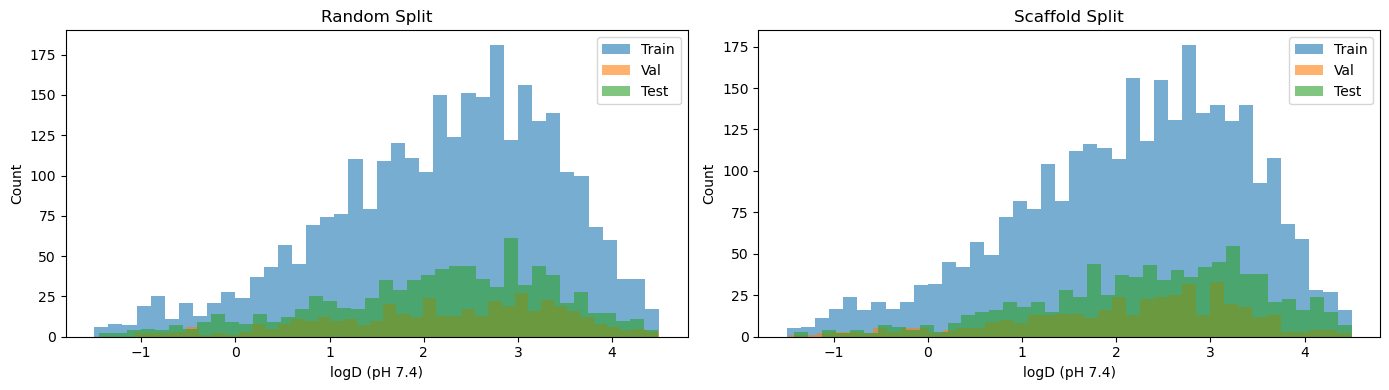

In [73]:
# ── Splitting Strategies ──────────────────────────────────────────────────────
def get_indices(df_full, df_split):
    """
    Given the full cleaned dataframe and a TDC split subset,
    return the indices in df_full that correspond to df_split molecules.
    Matching is done via canonical SMILES.
    """
    split_smiles = set(df_split['Drug'].apply(
        lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
    ))
    return df_full[df_full['canonical_SMILES'].isin(split_smiles)].index.tolist()

# Random Split
idx_train_r = get_indices(df, df_train_r)
idx_valid_r = get_indices(df, df_valid_r)
idx_test_r  = get_indices(df, df_test_r)

# Scaffold Split
idx_train_s = get_indices(df, df_train_s)
idx_valid_s = get_indices(df, df_valid_s)
idx_test_s  = get_indices(df, df_test_s)

# Report
print("Random split:")
print(f"  Train: {len(idx_train_r)}, Val: {len(idx_valid_r)}, Test: {len(idx_test_r)}")
print(f"  Total: {len(idx_train_r) + len(idx_valid_r) + len(idx_test_r)}")

print("\nScaffold split:")
print(f"  Train: {len(idx_train_s)}, Val: {len(idx_valid_s)}, Test: {len(idx_test_s)}")
print(f"  Total: {len(idx_train_s) + len(idx_valid_s) + len(idx_test_s)}")

# Visualise target distribution per split
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (idx_tr, idx_va, idx_te), title in zip(
    axes,
    [(idx_train_r, idx_valid_r, idx_test_r),
     (idx_train_s, idx_valid_s, idx_test_s)],
    ['Random Split', 'Scaffold Split']
):
    ax.hist(df.loc[idx_tr, 'Y'], bins=40, alpha=0.6, label='Train', color='tab:blue')
    ax.hist(df.loc[idx_va, 'Y'], bins=40, alpha=0.6, label='Val',   color='tab:orange')
    ax.hist(df.loc[idx_te, 'Y'], bins=40, alpha=0.6, label='Test',  color='tab:green')
    ax.set_title(title)
    ax.set_xlabel('logD (pH 7.4)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

Both splits produce partitions of the expected sizes (70/10/20). In the **random split**, train, validation and test sets follow very similar logD 
distributions — as expected when molecules are assigned randomly, the three partitions are statistically indistinguishable. In the **scaffold split**, the distributions appear visually similar as well, which is somewhat unexpected — a scaffold split should in theory produce test sets with different chemical coverage from training. Whether this reflects a genuinely similar distribution or is an artefact of the scaffold structure of this particular dataset is investigated quantitatively in the next section via nearest-neighbour Tanimoto similarity analysis.

## Section 7 — Train/Test Similarity Analysis

The distribution plots in Section 6 suggested that the scaffold and random splits produce visually similar target distributions. Before training any model, we want to investigate this further by quantifying how structurally similar the test molecules are to the training set. This analysis serves two purposes.

#### 1. Quantifying split difficulty

As demonstrated in Session 5, a scaffold split should in theory produce test molecules that are structurally less similar to training molecules than a random split. We compute the **nearest-neighbour Tanimoto similarity** for each test molecule — the maximum Tanimoto similarity between that molecule and any molecule in the training set. 

We use **Morgan fingerprints (ECFP4, radius=2, 1024 bits)** for this analysis. Among the four encodings used in this project, Morgan fingerprints are the most appropriate choice for similarity measurement because they capture local atomic environments at multiple scales, are robust to small structural variations, and are the standard representation used for molecular similarity in the cheminformatics literature (Rogers & Hahn, 2010). Physicochemical descriptors are not appropriate here as Tanimoto similarity is not defined for continuous vectors; MACCS keys are too coarse (only 166 predefined patterns); and RDKit fingerprints, while valid, are less commonly used for similarity-based applicability domain assessment than Morgan fingerprints.

Values close to 1 indicate that the test molecule is nearly identical to a training molecule; values close to 0 indicate it is structurally very different from anything the model was trained on.

#### 2. Defining the Applicability Domain

The applicability domain concept (Schroeter et al., 2007) defines the region of chemical space where a model's predictions can be trusted. We store the nearest-neighbour similarity for each test molecule and use it later to group test molecules by structural similarity to the training set and analyse how prediction error varies across similarity bins. This directly connects the data characterization performed here to the model evaluation section.

Converting fingerprints to RDKit bit vectors...
Computing nearest-neighbour similarities...
Done!


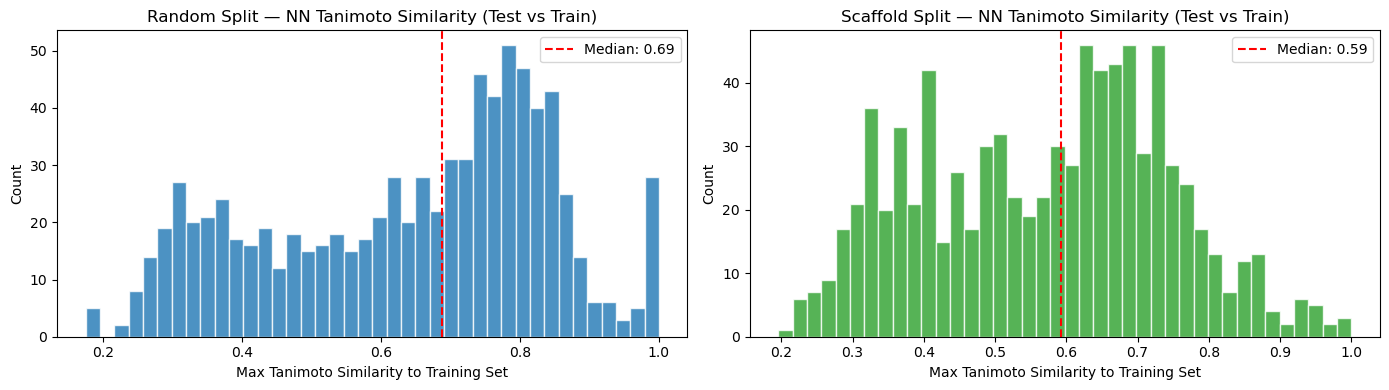

Random   — Mean: 0.639, Median: 0.688
Scaffold — Mean: 0.571, Median: 0.593


In [74]:
# ── Train/Test Similarity Analysis ────────────────────────────────────────────
def rows_to_fps(df_features):
    """Convert feature matrix rows to RDKit bit vectors."""
    fps = []
    for _, row in df_features.iterrows():
        fp = ExplicitBitVect(len(row))
        for i, bit in enumerate(row):
            if bit:
                fp.SetBit(i)
        fps.append(fp)
    return fps

def nearest_neighbor_similarity(test_fps, train_fps):
    """For each test fingerprint, return max Tanimoto to any training fingerprint."""
    nn_sims = []
    for fp_test in test_fps:
        sims = BulkTanimotoSimilarity(fp_test, train_fps)
        nn_sims.append(max(sims))
    return np.array(nn_sims)

# Convert Morgan fingerprints to RDKit bit vectors
print("Converting fingerprints to RDKit bit vectors...")
train_fps_r = rows_to_fps(df_morgan.loc[idx_train_r])
test_fps_r  = rows_to_fps(df_morgan.loc[idx_test_r])
train_fps_s = rows_to_fps(df_morgan.loc[idx_train_s])
test_fps_s  = rows_to_fps(df_morgan.loc[idx_test_s])

# Compute nearest-neighbour similarities
print("Computing nearest-neighbour similarities...")
nn_sim_random   = nearest_neighbor_similarity(test_fps_r, train_fps_r)
nn_sim_scaffold = nearest_neighbor_similarity(test_fps_s, train_fps_s)

# Store for later use in applicability domain (Section 12)
df['nn_sim_random']   = np.nan
df['nn_sim_scaffold'] = np.nan
df.loc[idx_test_r, 'nn_sim_random']   = nn_sim_random
df.loc[idx_test_s, 'nn_sim_scaffold'] = nn_sim_scaffold

# Plot similarity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, nn_sim, title, color in zip(
    axes,
    [nn_sim_random, nn_sim_scaffold],
    ['Random Split', 'Scaffold Split'],
    ['tab:blue', 'tab:green']
):
    ax.hist(nn_sim, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(np.median(nn_sim), color='red', linestyle='--',
               label=f'Median: {np.median(nn_sim):.2f}')
    ax.set_title(f'{title} — NN Tanimoto Similarity (Test vs Train)')
    ax.set_xlabel('Max Tanimoto Similarity to Training Set')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics
for name, nn_sim in [('Random  ', nn_sim_random), ('Scaffold', nn_sim_scaffold)]:
    print(f"{name} — Mean: {nn_sim.mean():.3f}, "
          f"Median: {np.median(nn_sim):.3f}")

The nearest-neighbour Tanimoto similarity analysis confirms that the scaffold split produces a meaningfully harder evaluation than the random split. The median similarity drops from **0.69 (random)** to **0.59 (scaffold)**, meaning that on average, test molecules in the scaffold split are structurally more distant from the training set. The scaffold split also has a broader, more uniform distribution shifted toward lower similarities, while the random split is more concentrated at high similarity values — consistent with the expectation that random splitting allows structurally similar molecules to appear in both train and test.

However, the difference is moderate rather than dramatic. Both splits still have relatively high median similarities, suggesting that while scaffold splitting does create a more realistic evaluation, the chemical space of this particular dataset is relatively homogeneous, limiting how structurally distinct the two splits can be in practice.

These similarity scores are stored for later use, when we empirically determine an applicability domain threshold based on the relationship between structural similarity and prediction error.

## Section 8 — Chemical Space Visualization

Having characterized the splits quantitatively via Tanimoto similarity in Section 7, we now visualize the chemical space of the dataset using **UMAP** (Uniform Manifold Approximation and Projection, McInnes et al., 2018).

While PCA was also covered in Session 2, it is a linear dimensionality reduction method and is not well-suited for high-dimensional binary fingerprint data. The non-linear relationships between molecules in our 1024-dimensional Morgan fingerprint space cannot be adequately captured by linear projections. UMAP preserves both local and global non-linear structure, making it the more appropriate choice for visualizing molecular chemical space.

We use Morgan fingerprints (ECFP4, radius=2, 1024 bits) as input, consistent with the similarity analysis in Section 7, and produce two visualizations:

1. **Property landscape** — all 4,200 molecules colored by their logD value, revealing how lipophilicity varies across chemical space
2. **Split assignment** — the same projection colored by train/validation/test assignment for both random and scaffold splits, providing a visual confirmation of what the similarity analysis showed quantitatively

**Note:** UMAP is used here purely as a **visualization tool** — it is not part of the modelling pipeline. While UMAP preserves local and global 
structure better than PCA for non-linear high-dimensional data, the 2D projection is necessarily a simplification of the full 1024-dimensional 
fingerprint space. Distances and cluster separations in the UMAP plot should be interpreted qualitatively rather than quantitatively.

Fitting UMAP...


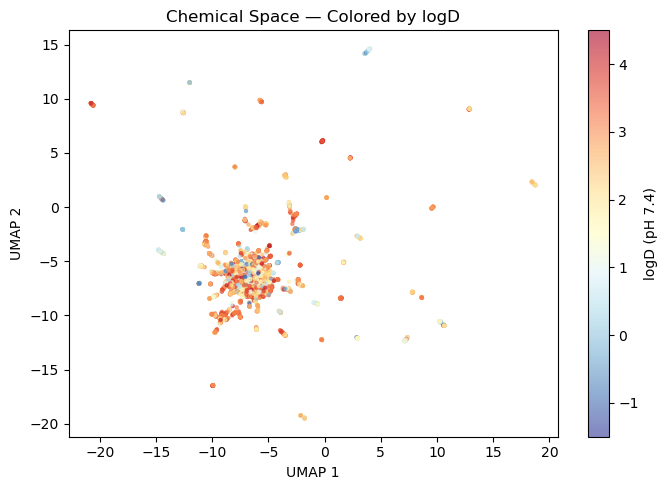

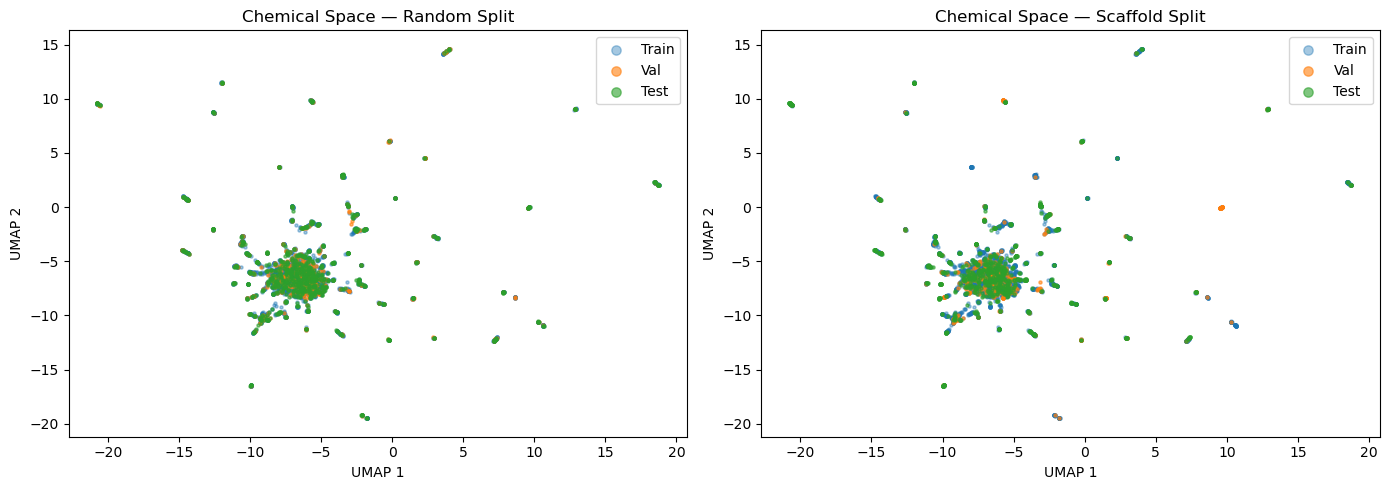

In [99]:
# ── Chemical Space Visualization — UMAP ──────────────────────────────────────
from umap import UMAP

# ── Global Parameters ─────────────────────────────────────────────────────────
random_state = 42
TARGET_COL   = 'Y'

# Fit UMAP on full dataset using Morgan fingerprints
print("Fitting UMAP...")
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=random_state
)
X_umap = umap_model.fit_transform(df_morgan.values)

# ── Plot 1: Property landscape (colored by logD) ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                c=df['Y'].values, cmap='RdYlBu_r',
                s=5, alpha=0.6)
plt.colorbar(sc, ax=ax, label='logD (pH 7.4)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Chemical Space — Colored by logD')
plt.tight_layout()
plt.show()

# ── Plot 2: Split assignment ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (idx_tr, idx_va, idx_te), title in zip(
    axes,
    [(idx_train_r, idx_valid_r, idx_test_r),
     (idx_train_s, idx_valid_s, idx_test_s)],
    ['Random Split', 'Scaffold Split']
):
    ax.scatter(X_umap[idx_tr, 0], X_umap[idx_tr, 1],
               c='tab:blue', s=5, alpha=0.4, label='Train')
    ax.scatter(X_umap[idx_va, 0], X_umap[idx_va, 1],
               c='tab:orange', s=5, alpha=0.6, label='Val')
    ax.scatter(X_umap[idx_te, 0], X_umap[idx_te, 1],
               c='tab:green', s=5, alpha=0.6, label='Test')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'Chemical Space — {title}')
    ax.legend(markerscale=3)

plt.tight_layout()
plt.show()

The UMAP projection reveals that the dataset has a **dense core** of structurally similar drug-like molecules surrounded by a sparse periphery of more unusual compounds. This is typical of pharmaceutical datasets where most compounds share common drug-like scaffolds.

The **property landscape** shows that lipophilicity is not randomly distributed across chemical space — molecules with similar logD values tend to cluster together, confirming that molecular structure is informative for predicting logD.

The **split assignment** plots visually confirm the quantitative findings from Section 7. In the **random split**, the test set (green) is densely present throughout the main cluster and also dominates most of the peripheral regions, with only a few train/val molecules appearing mostly toward the edges of the core blob. In the **scaffold split**, the main cluster shows a more balanced mix of all three partitions, with the training and validation set more visible inside the core, and the peripheral regions contain a greater proportion of train and validation molecules alongside test molecules. This indicates that scaffold splitting more evenly distributes structural diversity across partitions rather than concentrating the test set in any particular region — consistent with the moderate but meaningful difference in median Tanimoto similarity observed in Section 7 (0.59 vs 0.69 for random).

## Section 9 — Baseline Model

Before performing feature selection, we establish a baseline by training **Linear Regression** on all features from each encoding, evaluated on the random split test set. This serves as a reference point for two purposes: first, to quantify the starting performance of each encoding before we do any feature engineering; second, to motivate and justify the feature selection step that follows in the next section.

### Why Linear Regression as baseline?

As discussed in Session 6, Linear Regression is the ideal model for this purpose because it is simple and fully interpretable, has no implicit feature selection (unlike Lasso or Ridge), and every feature can receive a non-zero weight — making redundancy immediately visible. The extended physicochemical descriptor set was intentionally designed to include correlated and redundant features. As covered in Session 6, such redundancy causes two problems: it dilutes permutation feature importance scores through the substitution effect, and it can hurt linear models through multicollinearity. The baseline results will reveal how severely these issues affect performance.

### Why random split for the baseline?

The baseline is evaluated on the random split only. The scaffold split is reserved as the primary evaluation for the full model comparison in the later sections, where all models are compared under identical and fair conditions. Using the random split here gives an optimistic upper bound on performance for each encoding, serving as a useful reference point.

In [76]:
# ── Baseline Model — Linear Regression on All Features ───────────────────────
results_baseline = {}

for enc_name, df_enc in [('MACCS',        df_maccs),
                          ('Morgan',       df_morgan),
                          ('RDKit_FP',     df_rdkfp),
                          ('Physchem_all', df_physchem_ext)]:

    # Get train/test sets
    X_train = df_enc.loc[idx_train_r].values
    y_train = df.loc[idx_train_r, TARGET_COL].values
    X_test  = df_enc.loc[idx_test_r].values
    y_test  = df.loc[idx_test_r, TARGET_COL].values

    # Apply scaling for physicochemical descriptors only
    if enc_name == 'Physchem_all':
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    # Train
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)

    results_baseline[enc_name] = {
        'MAE':   mae,
        'R2':    r2,
        'model': model,
        'y_pred': y_pred,
        'y_test': y_test,
    }

# Summary table
print("Baseline — Linear Regression, Random Split, All Features")
print(f"\n{'Encoding':<15} {'MAE':>8} {'R²':>8}")
print("-" * 35)
for enc_name, res in results_baseline.items():
    print(f"{enc_name:<15} {res['MAE']:>8.3f} {res['R2']:>8.3f}")

Baseline — Linear Regression, Random Split, All Features

Encoding             MAE       R²
-----------------------------------
MACCS              0.772    0.380
Morgan             0.764    0.303
RDKit_FP           1.232   -0.860
Physchem_all       0.691    0.470


The baseline results reveal clear differences across encodings. Physicochemical descriptors perform best (MAE=0.691, R²=0.470), consistent with the known near-linear relationship between logP and logD. MACCS keys and Morgan fingerprints show moderate performance (R²=0.380 and 0.303 respectively), while the RDKit fingerprint produces a **negative R²=−0.860** — meaning the model performs worse than simply predicting the mean logD for every molecule. This is probably a direct consequence of the high dimensionality of the RDKit fingerprint (2048 bits) combined with the limitations of linear regression on sparse binary data — a well-known phenomenon where linear models overfit in very high-dimensional spaces. This result directly motivates the use of tree-based models (Random Forest, XGBoost) later on, which handle high-dimensional sparse data natively.

RDKit FP — average non-zero bits per molecule: 846.4 out of 2048 (41.3%)
Morgan FP — average non-zero bits per molecule: 48.1 out of 1024 (4.7%)
MACCS     — average non-zero bits per molecule: 51.6 out of 166 (31.1%)


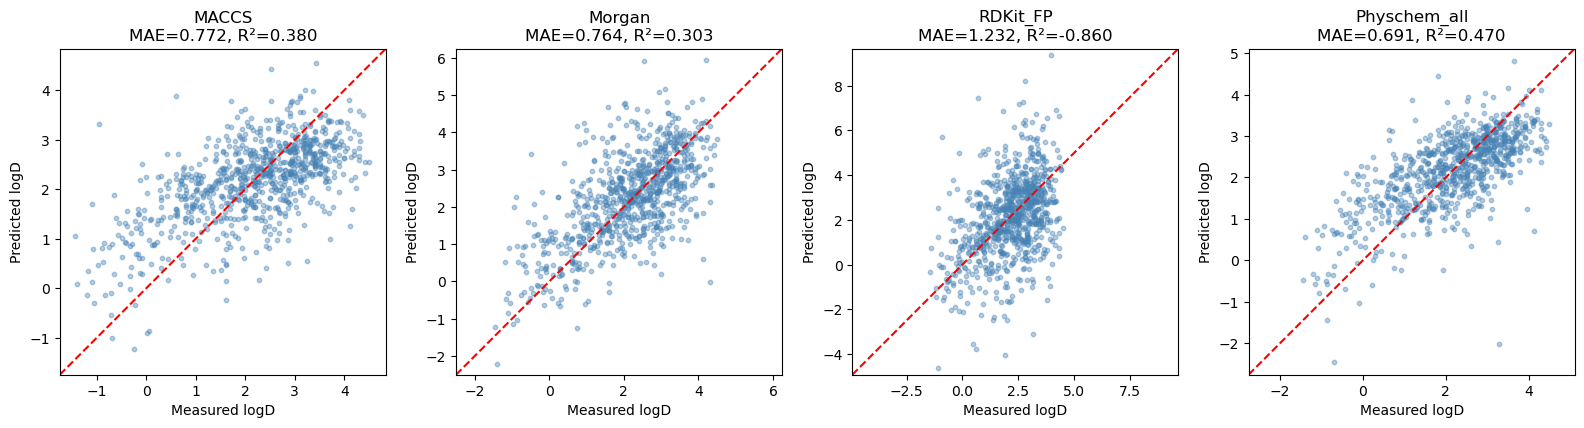

In [77]:
# ── Exploring the negative R² for RDKit fingerprints ─────────────────────────

# How many non-zero features does the average molecule have?
rdkfp_density = (df_rdkfp > 0).sum(axis=1)
print(f"RDKit FP — average non-zero bits per molecule: {rdkfp_density.mean():.1f} "
      f"out of 2048 ({rdkfp_density.mean()/2048*100:.1f}%)")

morgan_density = (df_morgan > 0).sum(axis=1)
print(f"Morgan FP — average non-zero bits per molecule: {morgan_density.mean():.1f} "
      f"out of 1024 ({morgan_density.mean()/1024*100:.1f}%)")

maccs_density = (df_maccs > 0).sum(axis=1)
print(f"MACCS     — average non-zero bits per molecule: {maccs_density.mean():.1f} "
      f"out of 166 ({maccs_density.mean()/166*100:.1f}%)")

# Scatter plot for RDKit FP predictions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (enc_name, res) in zip(axes, results_baseline.items()):
    ax.scatter(res['y_test'], res['y_pred'], alpha=0.4, s=10, color='steelblue')
    lim = [min(res['y_test'].min(), res['y_pred'].min()) - 0.3,
           max(res['y_test'].max(), res['y_pred'].max()) + 0.3]
    ax.plot(lim, lim, 'r--', linewidth=1.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel('Measured logD')
    ax.set_ylabel('Predicted logD')
    ax.set_title(f'{enc_name}\nMAE={res["MAE"]:.3f}, R²={res["R2"]:.3f}')

plt.tight_layout()
plt.show()

The sparsity analysis confirms the hypothesis about the RDKit fingerprint failure. While MACCS keys and Morgan fingerprints have ~52 (31.1%) and ~48 (4.7%) active bits per molecule respectively, the RDKit fingerprint has ~846 active features per molecule (41.3% of 2048 bits) — roughly 16 times more active features than MACCS. This extremely high number of active features creates a severely ill-conditioned problem for linear regression, causing the catastrophic overfitting observed in the scatter plot. The physicochemical descriptor set, despite containing redundant features, provides the most linearly separable signal for logD prediction — setting up the feature selection analysis in the next section.

## Section 10 — Feature Selection

Feature selection is applied exclusively to the **physicochemical descriptors**, as these are the only continuous, potentially redundant features in our pipeline. Fingerprint encodings (MACCS, Morgan, RDKit FP) are used as-is — they are binary by design and tree-based models handle their high dimensionality natively.

All feature selection is performed on the **training set only** to prevent data leakage, and is carried out before the full model comparison because the selected features are a direct input to modelling. The extended physicochemical descriptor set was intentionally designed to include correlated and redundant features — without feature selection, this redundancy would dilute permutation feature importance scores through the substitution effect and reduce model interpretability.

### Strategy

As covered in Session 6, we proceed in the following steps:

1. **Correlation Matrix** — compute the pairwise Spearman correlation matrix between all extended physicochemical descriptors to visualize redundancy and identify correlated feature groups

2. **Three selection methods on Linear Regression** — consistent with the baseline in Section 9 and the Session 6 methodology:

| Method | Description |
|---|---|
| **Filter** | Rank features by absolute Spearman correlation with target |
| **Forward Selection (FS)** | Greedy wrapper — add the feature that maximises CV R² at each step |
| **Clustered Forward Selection (CFS)** | Same as FS, but enforces one candidate per correlated cluster, explicitly preventing redundant features from entering the selected set |

3. **Score curves** — plot CV R² vs number of selected features to identify the optimal feature count for each method

4. **Permutation Feature Importance (PFI)** — compare importance scores before and after feature selection to verify that CFS reduces the substitution effect and produces cleaner, more interpretable importance scores

5. **CFS for Random Forest and XGBoost** — CFS is applied separately for each tree-based model since the optimal feature subset may differ depending on the model's inductive bias. CFS is selected as the most principled method since it explicitly enforces diversity across correlated feature clusters, making it the most robust choice regardless of the downstream model

In [78]:
# ── Feature Selection Parameters ──────────────────────────────────────────────

# Model used for feature selection
MODEL = LinearRegression()

# Feature selection parameters
CV_FOLDS                = 5
MAX_FEATURES            = 60  # increased from 40 after observing the score curve had not plateaued
THRESHOLD_CORR_FEATURES = 0.7

### Step 1 — Spearman Correlation Matrix

We begin by computing the pairwise Spearman rank correlation between all extended physicochemical descriptors using the training set only. Spearman correlation is used rather than Pearson because it is robust to non-linear monotonic relationships and does not assume normally distributed features — more appropriate for molecular descriptors which are often skewed or discrete.

The heatmap visualizes redundancy in the descriptor set. Highly correlated feature groups (dark red or dark blue blocks) represent descriptors that carry essentially the same information — for example, multiple logP implementations, overlapping ring count descriptors, and atom-type counts that are subsets of each other. These correlated groups are exactly what CFS targets in the selection step that follows.

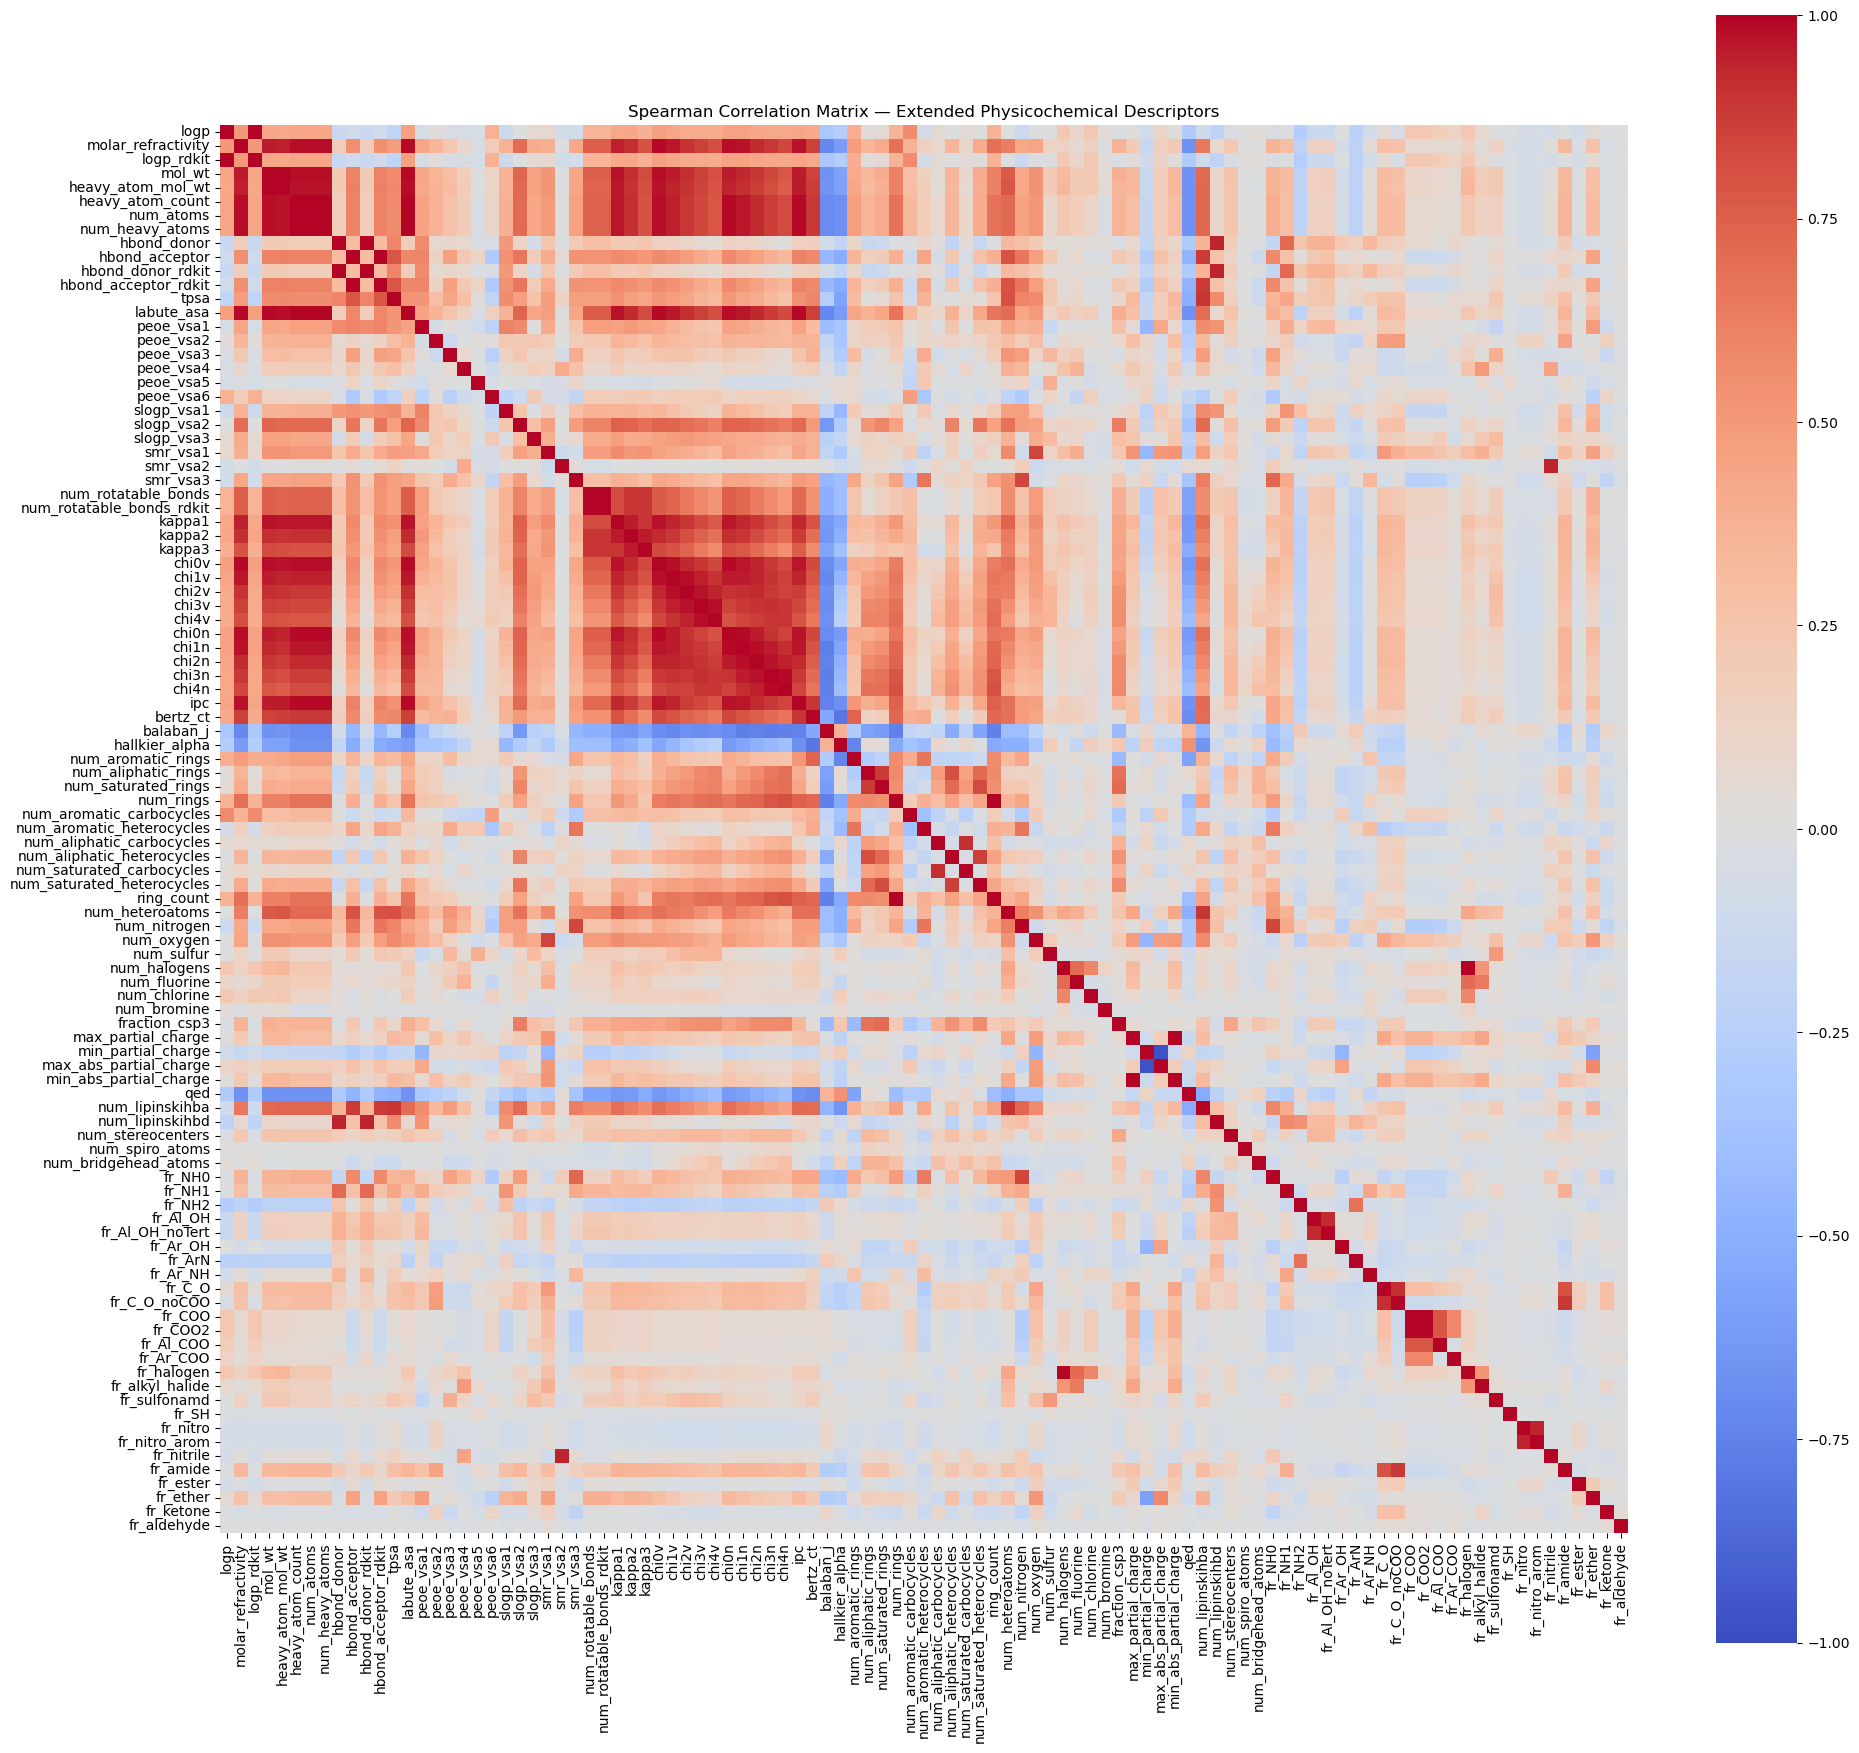

Training set shape: (2940, 101)
Number of descriptors: 101


In [79]:
# ── Step 1: Spearman Correlation Matrix ───────────────────────────────────────

# Use random training split only — never touch test set
X_fs = df_physchem_ext.loc[idx_train_r]
y_fs = df.loc[idx_train_r, TARGET_COL]

# Compute Spearman correlation matrix
corr = spearman_corr_matrix(X_fs)

# Plot heatmap
fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, ax=ax,
    xticklabels=DESCRIPTOR_NAMES,
    yticklabels=DESCRIPTOR_NAMES,
)
ax.set_title('Spearman Correlation Matrix — Extended Physicochemical Descriptors')
plt.tight_layout()
plt.show()

print(f"Training set shape: {X_fs.shape}")
print(f"Number of descriptors: {len(DESCRIPTOR_NAMES)}")

The heatmap confirms the presence of several strongly correlated feature groups in the descriptor set. The most prominent blocks are the **connectivity and topological indices** (chi0v through chi4n, kappa indices, bertz_ct, ipc) which form a large highly intercorrelated cluster, the **molecular size descriptors** (mol_wt, heavy_atom_count, num_atoms) which are near-perfectly correlated, and the **lipophilicity descriptors** (logp, logp_rdkit, molar_refractivity) which are also strongly correlated with each other. The fragment and functional group counts in the lower-right corner form smaller but clearly visible correlated subgroups. This redundancy structure directly motivates the use of CFS, which will select at most one representative from each correlated cluster.

### Step 2 — Feature Selection Methods on Linear Regression

We now apply all three feature selection methods to the training set using 
Linear Regression as the scoring model. The filter method ranks features 
independently by their Spearman correlation with the target. Forward selection 
greedily adds features that maximise cross-validated R² in context. Clustered 
forward selection extends this by enforcing one candidate per correlated cluster 
at each step, directly leveraging the redundancy structure visualized above.

In [80]:
# ── Feature Selection — Step 2: Three Methods ────────────────────────────────

# Method 1: Filter
corr_with_target = spearmanr(X_fs, y_fs)[0][:-1, -1]
filter_ranking = pd.Series(
    np.abs(corr_with_target),
    index=DESCRIPTOR_NAMES,
).sort_values(ascending=False)

selected_filter = filter_ranking.index.tolist()
print("Filter — top 20 features by correlation with logD:")
print(filter_ranking.head(20))

# Method 2: Forward Selection
print("\nRunning Forward Selection...")
selected_fs, scores_fs = forward_selection(
    X_fs, y_fs,
    max_features=MAX_FEATURES,
    cv=CV_FOLDS,
    random_state=random_state,
)
opt_nr_var_fs    = np.argmax(scores_fs) + 1
best_selected_fs = selected_fs[:opt_nr_var_fs]
print(f"\nFS optimal: {opt_nr_var_fs} features (CV R²={scores_fs[opt_nr_var_fs-1]:.3f})")

# Method 3: Clustered Forward Selection
print("\nRunning Clustered Forward Selection...")
selected_cfs, scores_cfs, cluster_labels = clustered_forward_selection(
    X_fs, y_fs,
    corr_matrix=corr,
    corr_threshold=THRESHOLD_CORR_FEATURES,
    max_features=MAX_FEATURES,
    cv=CV_FOLDS,
    random_state=random_state,
)
opt_nr_var_cfs    = np.argmax(scores_cfs) + 1
best_selected_cfs = selected_cfs[:opt_nr_var_cfs]
print(f"\nCFS optimal: {opt_nr_var_cfs} features (CV R²={scores_cfs[opt_nr_var_cfs-1]:.3f})")
print(f"Number of clusters found: {len(set(cluster_labels.values()))}")

Filter — top 20 features by correlation with logD:
logp                        0.403145
logp_rdkit                  0.403145
fr_COO                      0.307308
fr_COO2                     0.307308
num_aromatic_rings          0.298055
num_rings                   0.260134
ring_count                  0.260134
fr_Al_COO                   0.243460
balaban_j                   0.227378
num_lipinskihbd             0.216977
hbond_donor                 0.197446
hbond_donor_rdkit           0.197446
ipc                         0.196342
hallkier_alpha              0.195184
bertz_ct                    0.192342
molar_refractivity          0.191802
num_aromatic_carbocycles    0.184926
labute_asa                  0.175777
chi1n                       0.175066
fr_Ar_COO                   0.174528
dtype: float64

Running Forward Selection...

FS optimal: 50 features (CV R²=0.471)

Running Clustered Forward Selection...

CFS optimal: 33 features (CV R²=0.440)
Number of clusters found: 49


**Filter method** — the top features make strong chemical sense for logD prediction. `logp` and `logp_rdkit` rank highest (|ρ|=0.40), as expected 
since logP and logD are closely related measures of lipophilicity. Carboxylic acid fragments (`fr_COO`, `fr_COO2`), aromatic ring counts, and hydrogen bond donors follow — all known to influence lipophilicity. However, the filter method cannot detect redundancy: `logp` and `logp_rdkit` are two implementations of the same descriptor, `fr_COO` and `fr_COO2` are near-identical, and `num_rings` and `ring_count` are redundant ring count descriptors. All receive high ranks despite carrying no additional information over each other.

**Forward Selection** — optimal at **50 features** (CV R²=0.471), reaching the plateau within our `MAX_FEATURES=60` limit, confirming that increasing from 40 to 60 was the right decision.

**Clustered Forward Selection** — optimal at **33 features** (CV R²=0.440) across **49 clusters**, consistent with the correlation matrix which showed many correlated feature groups. CFS achieves a slightly lower CV R² than FS (0.440 vs 0.471) but with 17 fewer features — a better trade-off between performance and parsimony. The small performance gap confirms that the additional features selected by FS are largely redundant with those already chosen by CFS.

### Step 3 — Score Curves & Final Selection

We plot the CV R² as a function of the number of selected features for both Forward Selection and Clustered Forward Selection. The optimal number of features for each method is identified as the point where the score curve plateaus — adding more features beyond this point provides negligible improvement. The filter method does not produce a score curve since it ranks features independently without evaluating their combined predictive power — this is one of its key limitations compared to wrapper methods.

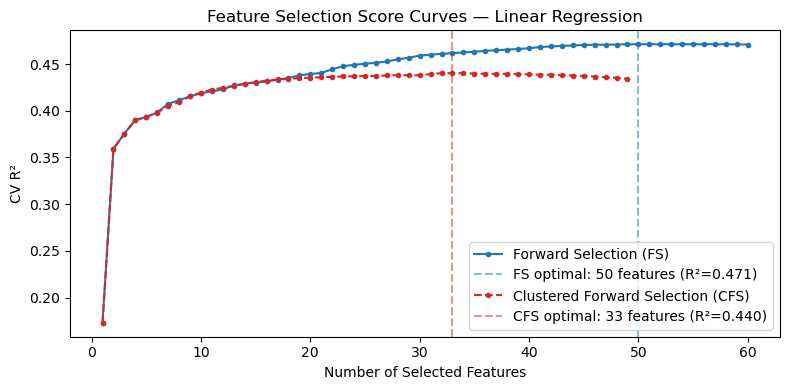

Filter    — top 33 features:
['logp', 'logp_rdkit', 'fr_COO', 'fr_COO2', 'num_aromatic_rings', 'num_rings', 'ring_count', 'fr_Al_COO', 'balaban_j', 'num_lipinskihbd', 'hbond_donor', 'hbond_donor_rdkit', 'ipc', 'hallkier_alpha', 'bertz_ct', 'molar_refractivity', 'num_aromatic_carbocycles', 'labute_asa', 'chi1n', 'fr_Ar_COO', 'heavy_atom_count', 'num_heavy_atoms', 'num_atoms', 'chi0n', 'chi0v', 'fr_NH0', 'chi2n', 'chi3n', 'chi4n', 'heavy_atom_mol_wt', 'mol_wt', 'num_oxygen', 'tpsa']

FS        — 50 optimal features:
['logp', 'fr_COO', 'fr_sulfonamd', 'fr_NH0', 'fraction_csp3', 'smr_vsa1', 'qed', 'num_aliphatic_carbocycles', 'peoe_vsa6', 'num_bridgehead_atoms', 'num_chlorine', 'smr_vsa2', 'fr_nitrile', 'fr_SH', 'fr_ester', 'peoe_vsa1', 'min_partial_charge', 'kappa1', 'slogp_vsa3', 'fr_C_O', 'kappa3', 'num_rotatable_bonds', 'num_aromatic_rings', 'fr_Al_OH', 'num_saturated_carbocycles', 'num_oxygen', 'fr_Ar_NH', 'smr_vsa3', 'heavy_atom_count', 'kappa2', 'max_abs_partial_charge', 'chi0v', 'n

In [81]:
# ── Step 3: Score Curves & Final Selection ────────────────────────────────────

# Score curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(scores_fs) + 1), scores_fs,
        marker='.', label='Forward Selection (FS)', color='tab:blue')
ax.axvline(opt_nr_var_fs, color='tab:blue', linestyle='--', alpha=0.5,
           label=f'FS optimal: {opt_nr_var_fs} features (R²={scores_fs[opt_nr_var_fs-1]:.3f})')
ax.plot(range(1, len(scores_cfs) + 1), scores_cfs,
        marker='.', linestyle='--',
        label='Clustered Forward Selection (CFS)', color='tab:red')
ax.axvline(opt_nr_var_cfs, color='tab:red', linestyle='--', alpha=0.5,
           label=f'CFS optimal: {opt_nr_var_cfs} features (R²={scores_cfs[opt_nr_var_cfs-1]:.3f})')
ax.set_xlabel('Number of Selected Features')
ax.set_ylabel('CV R²')
ax.set_title('Feature Selection Score Curves — Linear Regression')
ax.legend()
plt.tight_layout()
plt.show()

# Print selected features
print(f"Filter    — top {opt_nr_var_cfs} features:")
print(selected_filter[:opt_nr_var_cfs])
print(f"\nFS        — {opt_nr_var_fs} optimal features:")
print(best_selected_fs)
print(f"\nCFS       — {opt_nr_var_cfs} optimal features:")
print(best_selected_cfs)

# Store CFS selected features for Linear Regression
df_physchem_selected_lr = df_physchem_ext[best_selected_cfs]
print(f"\nPhyschem encoding for LR: {df_physchem_selected_lr.shape}")

Both score curves rise steeply for the first 5–10 features and then plateau, confirming that a small subset of descriptors captures most of the predictive signal — consistent with the Session 6 finding that many of the ~100 descriptors are redundant. The FS curve continues to rise slightly beyond 33 features, reaching its optimum at 50, while the CFS curve plateaus and marginally decreases after 33 features — suggesting diminishing returns from additional features under the cluster diversity constraint.

The three methods select notably different features despite a negligible performance difference (R²=0.471 vs 0.440), illustrating their different 
philosophies. The **filter** method selects many redundant features together — `logp` and `logp_rdkit`, `fr_COO` and `fr_COO2`, `num_rings` and `ring_count`, `num_heavy_atoms` and `heavy_atom_count` all appear together, confirming that ranking features independently cannot detect redundancy. For the filter method, we use the same number of features as CFS (33) to ensure a fair comparison — the filter ranking is used only to determine *which* features are selected, not *how many*. **Forward Selection** selects `logp` first and only adds `logp_rdkit` as the very last of its 50 features, suggesting it provides marginal additional value once all other features are already included. **CFS** produces the most parsimonious set — selecting `logp_rdkit` as its first feature while `logp` is not selected at all, correctly identifying them as redundant and keeping only one representative. `fr_COO` is selected by all three methods, confirming its consistent importance for logD prediction. The CFS selected features are stored as the physicochemical encoding for Linear Regression in the full model comparison.

### Step 4 — Permutation Feature Importance Before and After Feature Selection

Having identified the optimal feature subsets for each method, we now evaluate whether feature selection produces cleaner and more interpretable importance scores. As covered in Session 6, **Permutation Feature Importance (PFI)** measures the drop in R² when each feature is randomly shuffled — features that cause a large drop are important; features that cause no drop are irrelevant or substitutable.

When redundant features are present, PFI scores are diluted by the **substitution effect**: shuffling one feature barely hurts the model because  a correlated feature still provides the same signal. After feature selection — especially CFS, which explicitly removes correlated features — each remaining feature should "own" its importance more clearly, producing more reliable and interpretable scores.

We retrain Linear Regression on each selected feature set and compute PFI on the test set, comparing four conditions side by side:
- All ~100 features (redundant baseline)
- Filter-selected features
- Forward Selection features
- CFS-selected features

Method                 N features       R²
--------------------------------------------
All features                  101    0.470
Filter                         33    0.448
FS                             50    0.453
CFS                            33    0.452


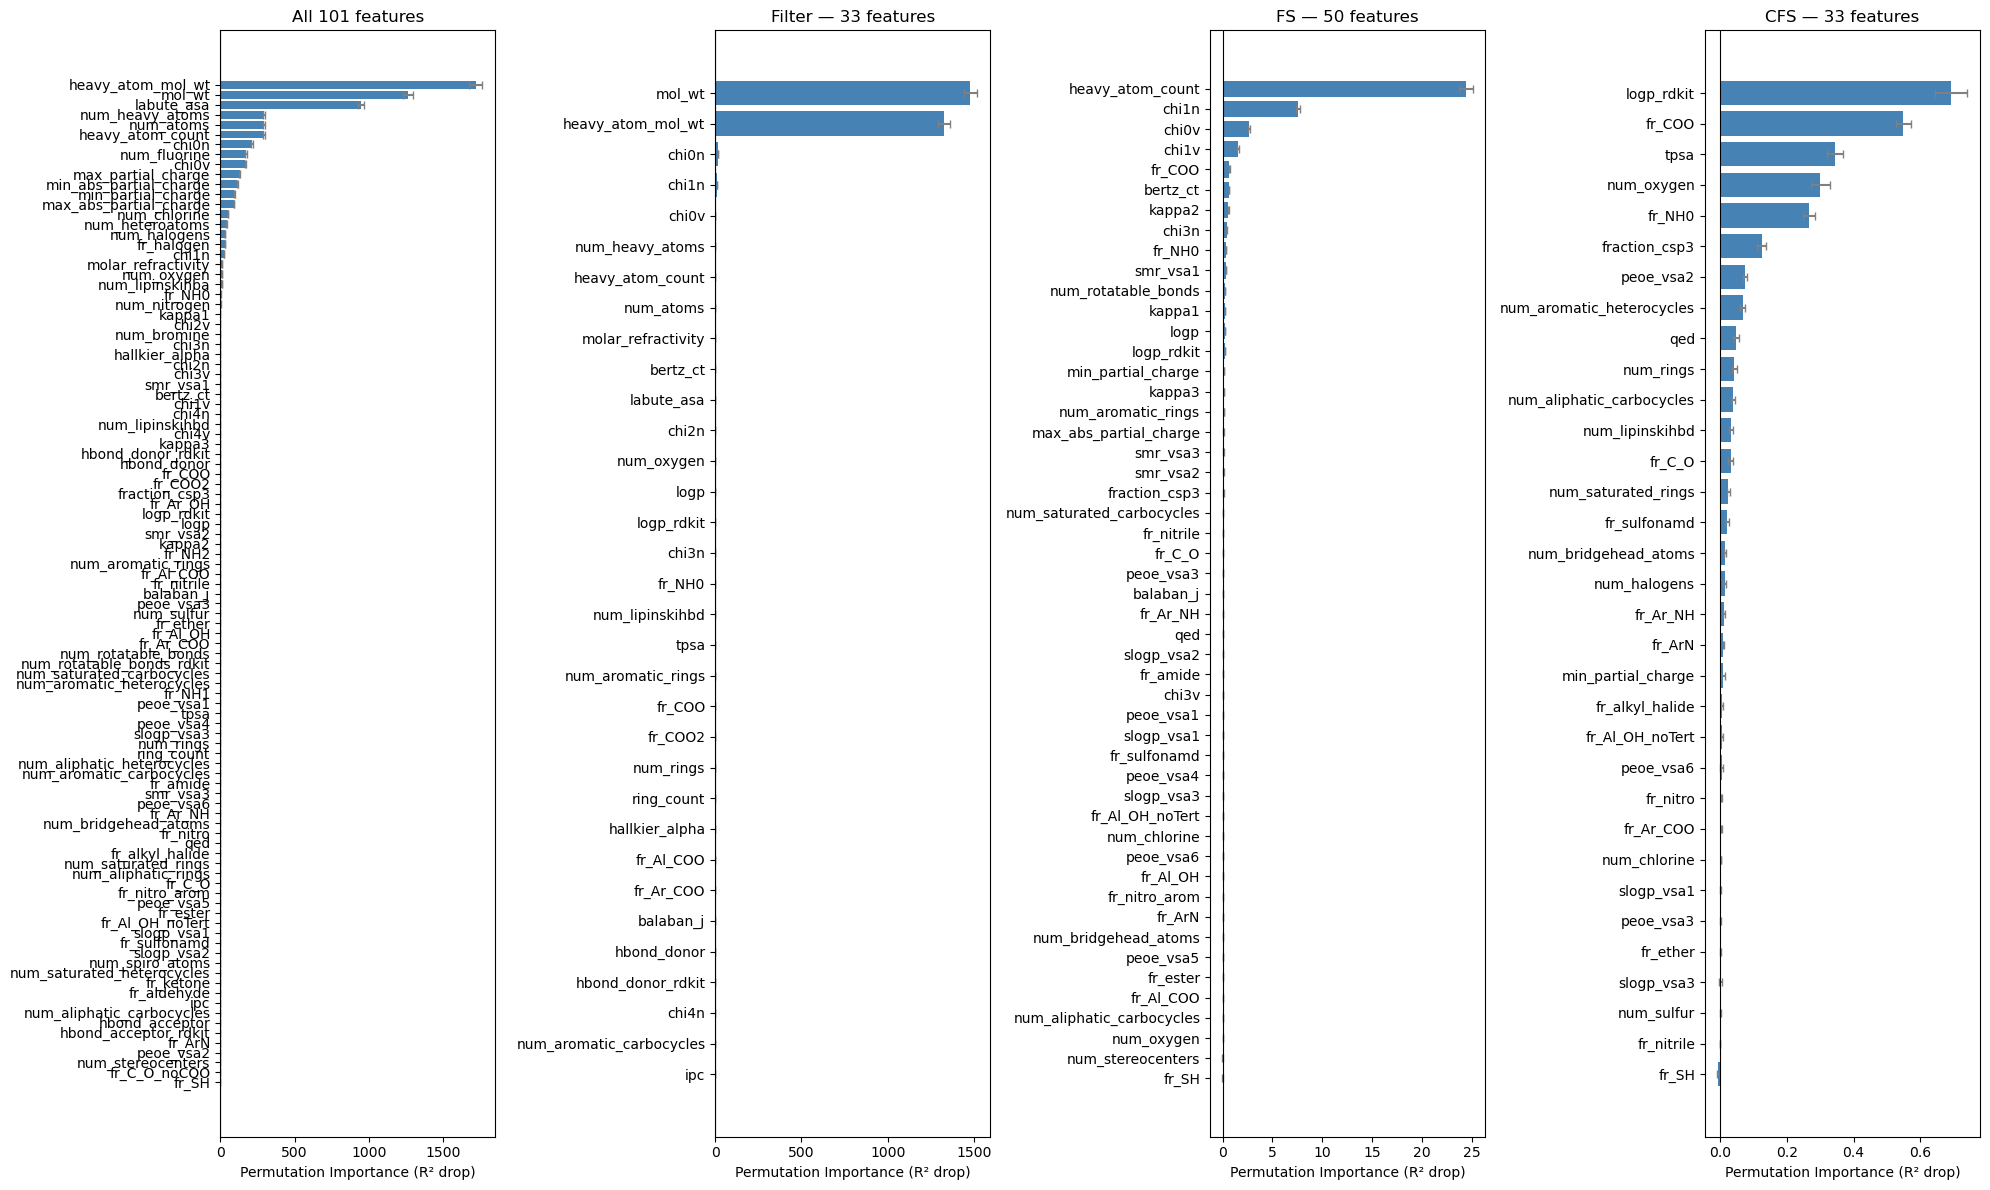

In [82]:
# ── Step 4: Permutation Feature Importance — Before and After Selection ───────

# ── Retrain models on each selected feature set ───────────────────────────────
y_train_pfi = df.loc[idx_train_r, TARGET_COL]
y_test_pfi  = df.loc[idx_test_r,  TARGET_COL]

# All features
scaler_all   = StandardScaler()
X_train_all  = scaler_all.fit_transform(df_physchem_ext.loc[idx_train_r])
X_test_all   = scaler_all.transform(df_physchem_ext.loc[idx_test_r])
model_all    = LinearRegression()
model_all.fit(X_train_all, y_train_pfi)

# Filter selected
scaler_filt  = StandardScaler()
X_train_filt = scaler_filt.fit_transform(
    df_physchem_ext.loc[idx_train_r, selected_filter[:opt_nr_var_cfs]])
X_test_filt  = scaler_filt.transform(
    df_physchem_ext.loc[idx_test_r, selected_filter[:opt_nr_var_cfs]])
model_filt   = LinearRegression()
model_filt.fit(X_train_filt, y_train_pfi)

# FS selected
scaler_fs    = StandardScaler()
X_train_fs   = scaler_fs.fit_transform(
    df_physchem_ext.loc[idx_train_r, best_selected_fs])
X_test_fs    = scaler_fs.transform(
    df_physchem_ext.loc[idx_test_r, best_selected_fs])
model_fs     = LinearRegression()
model_fs.fit(X_train_fs, y_train_pfi)

# CFS selected
scaler_cfs   = StandardScaler()
X_train_cfs  = scaler_cfs.fit_transform(
    df_physchem_ext.loc[idx_train_r, best_selected_cfs])
X_test_cfs   = scaler_cfs.transform(
    df_physchem_ext.loc[idx_test_r, best_selected_cfs])
model_cfs    = LinearRegression()
model_cfs.fit(X_train_cfs, y_train_pfi)

# ── R² comparison ─────────────────────────────────────────────────────────────
print(f"{'Method':<20} {'N features':>12} {'R²':>8}")
print("-" * 44)
print(f"{'All features':<20} {len(DESCRIPTOR_NAMES):>12} {r2_score(y_test_pfi, model_all.predict(X_test_all)):>8.3f}")
print(f"{'Filter':<20} {opt_nr_var_cfs:>12} {r2_score(y_test_pfi, model_filt.predict(X_test_filt)):>8.3f}")
print(f"{'FS':<20} {opt_nr_var_fs:>12} {r2_score(y_test_pfi, model_fs.predict(X_test_fs)):>8.3f}")
print(f"{'CFS':<20} {opt_nr_var_cfs:>12} {r2_score(y_test_pfi, model_cfs.predict(X_test_cfs)):>8.3f}")

# ── Compute PFI ───────────────────────────────────────────────────────────────
y_test_series = pd.Series(y_test_pfi.values, index=idx_test_r)

df_imp_all  = permutation_importance_df(
    model_all,
    pd.DataFrame(X_test_all,  columns=DESCRIPTOR_NAMES,                  index=idx_test_r),
    y_test_series, random_state=random_state)

df_imp_filt = permutation_importance_df(
    model_filt,
    pd.DataFrame(X_test_filt, columns=selected_filter[:opt_nr_var_cfs],  index=idx_test_r),
    y_test_series, random_state=random_state)

df_imp_fs   = permutation_importance_df(
    model_fs,
    pd.DataFrame(X_test_fs,   columns=best_selected_fs,                  index=idx_test_r),
    y_test_series, random_state=random_state)

df_imp_cfs  = permutation_importance_df(
    model_cfs,
    pd.DataFrame(X_test_cfs,  columns=best_selected_cfs,                 index=idx_test_r),
    y_test_series, random_state=random_state)

# ── Plot PFI side by side ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 12))

for ax, df_imp, title in zip(
    axes,
    [df_imp_all, df_imp_filt, df_imp_fs, df_imp_cfs],
    [f'All {len(DESCRIPTOR_NAMES)} features',
     f'Filter — {opt_nr_var_cfs} features',
     f'FS — {opt_nr_var_fs} features',
     f'CFS — {opt_nr_var_cfs} features']
):
    ax.barh(df_imp['feature'], df_imp['importance_mean'],
            xerr=df_imp['importance_std'],
            align='center', color='steelblue', ecolor='gray', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation Importance (R² drop)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

The R² comparison confirms that feature selection successfully reduces the descriptor set without meaningful loss of performance — all three methods maintain R² within 0.025 of the full feature baseline (0.470), while using between 33 and 50 features instead of 101.

The PFI plots clearly demonstrate the **substitution effect** and its resolution. With all 101 features, importance scores are heavily diluted — `heavy_atom_mol_wt`, `mol_wt` and `labute_asa` dominate with very large importance values while most features show near-zero importance, a classic sign of redundancy where correlated features absorb each other's contributions. 

The filter method does not improve this — only `mol_wt` and `heavy_atom_mol_wt` retain any importance while all other selected features drop to near zero, suggesting that selecting the top-ranked features independently still preserves the most correlated redundant group while discarding features that carry independent signal. Forward Selection improves the distribution somewhat, with `heavy_atom_count` dominating but more features showing non-zero importance across the panel.

The CFS panel shows the cleanest result — importance scores are more evenly distributed across features, with `logp_rdkit` and `fr_COO` as the clear top features, followed by `tpsa`, `num_oxygen`, and `fr_NH0`. This is chemically interpretable: logP is the closest proxy to logD, carboxylic acid groups reduce lipophilicity, TPSA captures polarity, and oxygen and amine counts reflect H-bonding capacity. CFS has effectively resolved the substitution effect by ensuring no two highly correlated features compete for the same importance.

### Step 5 — CFS for Random Forest and XGBoost

Having established CFS as the most principled feature selection method through the Linear Regression analysis above, we now apply it separately to Random Forest and XGBoost. Each model is used as the scoring function inside CFS, since the optimal feature subset may differ depending on the model's ability to capture non-linear relationships between descriptors and logD. We use a reduced number of estimators (`n_estimators=20`) and cross-validation folds (`cv=3`) to keep computation tractable — the goal here is feature ranking rather than final model performance. The three cells below run independently so each model can be monitored separately.

In [83]:
# ── CFS for Linear Regression — already done above ───────────────────────────
# best_selected_cfs_lr = best_selected_cfs (stored from Step 2)
best_selected_cfs_lr = best_selected_cfs
print(f"LR  — CFS selected {len(best_selected_cfs_lr)} features")
print(best_selected_cfs_lr)

LR  — CFS selected 33 features
['logp_rdkit', 'fr_COO', 'fr_sulfonamd', 'fr_NH0', 'fraction_csp3', 'fr_C_O', 'peoe_vsa2', 'qed', 'num_oxygen', 'min_partial_charge', 'fr_Al_OH_noTert', 'slogp_vsa3', 'num_aliphatic_carbocycles', 'num_chlorine', 'num_bridgehead_atoms', 'fr_SH', 'num_aromatic_heterocycles', 'fr_ether', 'peoe_vsa6', 'num_halogens', 'fr_Ar_COO', 'fr_nitro', 'num_saturated_rings', 'peoe_vsa3', 'fr_nitrile', 'fr_Ar_NH', 'num_rings', 'fr_alkyl_halide', 'num_sulfur', 'fr_ArN', 'tpsa', 'num_lipinskihbd', 'slogp_vsa1']


In [84]:
# ── CFS for Random Forest ─────────────────────────────────────────────────────
print("Running CFS for Random Forest model...")

selected_cfs_rf, scores_cfs_rf, cluster_labels_rf = clustered_forward_selection(
    X_fs, y_fs,
    corr_matrix=corr,
    corr_threshold=THRESHOLD_CORR_FEATURES,
    max_features=MAX_FEATURES,
    cv=3,
    random_state=random_state,
    model=RandomForestRegressor(
        n_estimators=20,
        random_state=random_state,
        n_jobs=-1
    ),
)
opt_rf = np.argmax(scores_cfs_rf) + 1
best_selected_cfs_rf = selected_cfs_rf[:opt_rf]
print(f"RF  — CFS optimal: {opt_rf} features (CV R²={scores_cfs_rf[opt_rf-1]:.3f})")
print(best_selected_cfs_rf)

Running CFS for Random Forest model...
RF  — CFS optimal: 26 features (CV R²=0.601)
['fr_COO2', 'num_rings', 'slogp_vsa1', 'logp_rdkit', 'max_partial_charge', 'slogp_vsa2', 'peoe_vsa3', 'smr_vsa2', 'fr_NH2', 'fr_sulfonamd', 'peoe_vsa2', 'num_aromatic_rings', 'fr_Ar_OH', 'peoe_vsa4', 'fr_ArN', 'num_bridgehead_atoms', 'fr_SH', 'num_stereocenters', 'num_lipinskihbd', 'num_aromatic_heterocycles', 'num_chlorine', 'fr_Ar_COO', 'heavy_atom_count', 'fr_C_O', 'hbond_acceptor_rdkit', 'fr_NH0']


In [85]:
# ── CFS for XGBoost ───────────────────────────────────────────────────────────
print("Running CFS for XGBoost model...")

selected_cfs_xgb, scores_cfs_xgb, cluster_labels_xgb = clustered_forward_selection(
    X_fs, y_fs,
    corr_matrix=corr,
    corr_threshold=THRESHOLD_CORR_FEATURES,
    max_features=MAX_FEATURES,
    cv=3,
    random_state=random_state,
    model=XGBRegressor(
        n_estimators=20,
        random_state=random_state,
        verbosity=0,
        n_jobs=-1
    ),
)
opt_xgb = np.argmax(scores_cfs_xgb) + 1
best_selected_cfs_xgb = selected_cfs_xgb[:opt_xgb]
print(f"XGB — CFS optimal: {opt_xgb} features (CV R²={scores_cfs_xgb[opt_xgb-1]:.3f})")
print(best_selected_cfs_xgb)

Running CFS for XGBoost model...
XGB — CFS optimal: 37 features (CV R²=0.607)
['logp_rdkit', 'fr_COO', 'max_partial_charge', 'slogp_vsa1', 'num_aromatic_rings', 'tpsa', 'peoe_vsa2', 'peoe_vsa1', 'smr_vsa2', 'fr_sulfonamd', 'fr_Ar_OH', 'num_stereocenters', 'fr_ketone', 'num_chlorine', 'fr_nitro_arom', 'smr_vsa3', 'num_bromine', 'fr_aldehyde', 'fr_NH2', 'num_rings', 'fr_ArN', 'num_spiro_atoms', 'fr_Ar_COO', 'num_halogens', 'fr_ester', 'fr_alkyl_halide', 'fr_SH', 'fr_Ar_NH', 'slogp_vsa2', 'peoe_vsa3', 'num_lipinskihbd', 'num_aliphatic_rings', 'fr_C_O', 'balaban_j', 'fr_Al_OH', 'peoe_vsa4', 'fr_ether']


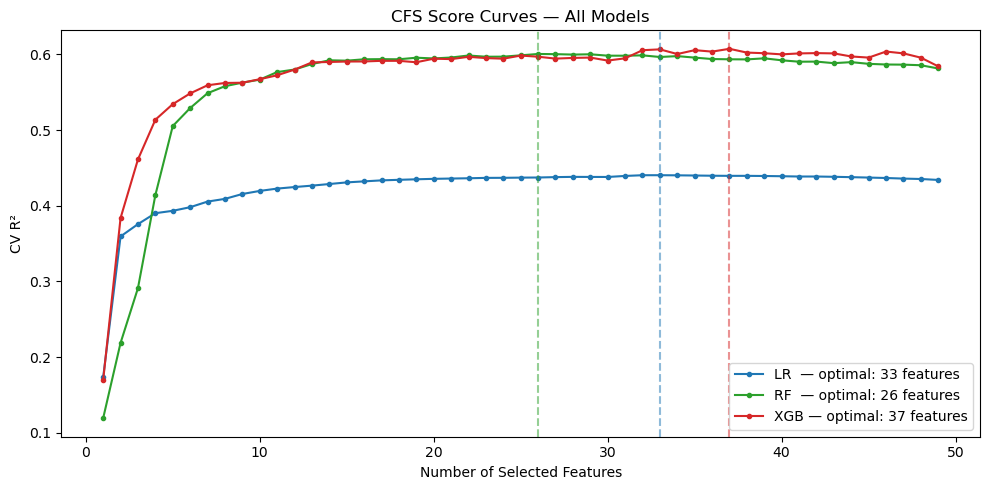


Model                  Optimal Features    CV R²
--------------------------------------------------
LinearRegression                     33    0.440
RandomForest                         26    0.601
XGBoost                              37    0.607

Physchem LR  shape: (4200, 33)
Physchem RF  shape: (4200, 26)
Physchem XGB shape: (4200, 37)

All feature matrices ready for full model comparison!


In [86]:
# ── Feature Selection Summary ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(scores_cfs) + 1),    scores_cfs,
        marker='.', label=f'LR  — optimal: {len(best_selected_cfs_lr)} features',
        color='tab:blue')
ax.plot(range(1, len(scores_cfs_rf) + 1), scores_cfs_rf,
        marker='.', label=f'RF  — optimal: {opt_rf} features',
        color='tab:green')
ax.plot(range(1, len(scores_cfs_xgb) + 1), scores_cfs_xgb,
        marker='.', label=f'XGB — optimal: {opt_xgb} features',
        color='tab:red')
ax.axvline(len(best_selected_cfs_lr), color='tab:blue',  linestyle='--', alpha=0.5)
ax.axvline(opt_rf,                    color='tab:green', linestyle='--', alpha=0.5)
ax.axvline(opt_xgb,                   color='tab:red',   linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Selected Features')
ax.set_ylabel('CV R²')
ax.set_title('CFS Score Curves — All Models')
ax.legend()
plt.tight_layout()
plt.show()

# ── Store selected features per model ─────────────────────────────────────────
print(f"\n{'Model':<20} {'Optimal Features':>18} {'CV R²':>8}")
print("-" * 50)
print(f"{'LinearRegression':<20} {len(best_selected_cfs_lr):>18} {scores_cfs[len(best_selected_cfs_lr)-1]:>8.3f}")
print(f"{'RandomForest':<20} {opt_rf:>18} {scores_cfs_rf[opt_rf-1]:>8.3f}")
print(f"{'XGBoost':<20} {opt_xgb:>18} {scores_cfs_xgb[opt_xgb-1]:>8.3f}")

# Store as physchem encodings for full modelling
df_physchem_selected_lr  = df_physchem_ext[best_selected_cfs_lr]
df_physchem_selected_rf  = df_physchem_ext[best_selected_cfs_rf]
df_physchem_selected_xgb = df_physchem_ext[best_selected_cfs_xgb]

print(f"\nPhyschem LR  shape: {df_physchem_selected_lr.shape}")
print(f"Physchem RF  shape: {df_physchem_selected_rf.shape}")
print(f"Physchem XGB shape: {df_physchem_selected_xgb.shape}")
print("\nAll feature matrices ready for full model comparison!")

The CFS score curves and results reveal clear differences across models, both in the number of features selected and in predictive performance.

All three curves follow the same pattern — steep initial rise followed by a plateau — but at very different R² levels. **Linear Regression** plateaus at R²=0.440 with 33 features, confirming the limited capacity of a linear model to capture the non-linear structure-property relationships in this dataset. **Random Forest** achieves R²=0.601 with only 26 features — the fewest of the three models — suggesting that tree-based ensembles can extract more information from a smaller, well-chosen feature set. **XGBoost** achieves the highest CV R²=0.607 with 37 features, benefiting from gradient boosting's ability to iteratively correct residual errors.

The selected feature sets differ meaningfully across models. Several features appear in all three — most notably `logp_rdkit`, confirming it as the most universally important descriptor for logD prediction, alongside `fr_COO`-related descriptors, surface area terms and hydrogen bond donors. Features such as `max_partial_charge`, `smr_vsa2`, `fr_Ar_OH` and `num_stereocenters` are selected by both RF and XGBoost but not LR, suggesting these capture non-linear signals that only tree-based models can exploit.

## Section 11 — Full Model Comparison

We now train and evaluate all model/encoding/split combinations using the CFS-selected features for physicochemical descriptors and all bits for  fingerprints.

### Experimental Design

- **3 models**: Linear Regression, Random Forest, XGBoost
- **4 encodings**: MACCS, Morgan, RDKit FP, Physchem (CFS-selected)
- **2 splits**: Random, Scaffold
- **24 combinations total**

For each combination:
1. Train on the training set
2. Tune hyperparameters using the **validation set** 
3. Report final performance on the **test set only**

The validation set is used exclusively for hyperparameter tuning — it is never used to make final performance claims. The test set is touched only once per combination, at the very end.

### Hyperparameters Tuned

| Model | Hyperparameters |
|---|---|
| Linear Regression | None — no hyperparameters |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf` |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate` |

### Metrics

- **MAE** (Mean Absolute Error, primary) — average absolute difference between predicted and true logD values in log units. Lower is better. Most directly interpretable: "on average our predictions are off by X log units"
- **RMSE** (Root Mean Squared Error, secondary) — similar to MAE but penalizes larger errors more heavily. This is the metric reported by the MoleculeNet benchmark (Wu et al., 2018) for the lipophilicity dataset on random split, enabling direct comparison with published results
- **R²** (coefficient of determination, tertiary) — proportion of variance in logD explained by the model. Higher is better, maximum is 1.0. A value of 0 means the model performs no better than predicting the mean, negative values indicate worse than mean performance

In [87]:
# ── Full Model Comparison ─────────────────────────────────────────────────────
from sklearn.model_selection import ParameterGrid

# ── Hyperparameter grids ──────────────────────────────────────────────────────
# Random Forest: 4x4x3 = 48 combinations
rf_param_grid = {
    'n_estimators':     [50, 100, 200, 500],  # number of trees
    'max_depth':        [None, 5, 10, 20],    # max tree depth (None = fully grown)
    'min_samples_leaf': [1, 2, 5],            # min samples per leaf node
}

# XGBoost: 4x4x4 = 64 combinations
xgb_param_grid = {
    'n_estimators':  [50, 100, 200, 500],     # number of boosting rounds
    'max_depth':     [3, 5, 7, 9],            # shallower than RF since boosting adds complexity iteratively
    'learning_rate': [0.01, 0.05, 0.1, 0.15], # contribution of each tree
}

# ── Encodings ─────────────────────────────────────────────────────────────────
encodings = {
    'MACCS':    df_maccs,
    'Morgan':   df_morgan,
    'RDKit_FP': df_rdkfp,
    'Physchem': None,  # model-specific CFS-selected features, handled below
}

# ── Results storage ───────────────────────────────────────────────────────────
results = {}

# ── Training loop ─────────────────────────────────────────────────────────────
for split_name, (idx_tr, idx_va, idx_te) in [
    ('Random',   (idx_train_r, idx_valid_r, idx_test_r)),
    ('Scaffold', (idx_train_s, idx_valid_s, idx_test_s)),
]:
    for enc_name, df_enc in encodings.items():
        for model_name, ModelClass, param_grid, physchem_df in [
            ('LR',  LinearRegression,      None,           df_physchem_selected_lr),
            ('RF',  RandomForestRegressor, rf_param_grid,  df_physchem_selected_rf),
            ('XGB', XGBRegressor,          xgb_param_grid, df_physchem_selected_xgb),
        ]:
            # Select correct feature matrix
            if enc_name == 'Physchem':
                df_use = physchem_df
            else:
                df_use = df_enc

            # Get train/val/test sets
            X_train = df_use.loc[idx_tr].values
            y_train = df.loc[idx_tr, TARGET_COL].values
            X_val   = df_use.loc[idx_va].values
            y_val   = df.loc[idx_va, TARGET_COL].values
            X_test  = df_use.loc[idx_te].values
            y_test  = df.loc[idx_te, TARGET_COL].values

            # Scale physicochemical descriptors only
            # Scaler fitted on training set only to avoid data leakage
            if enc_name == 'Physchem':
                scaler  = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_val   = scaler.transform(X_val)
                X_test  = scaler.transform(X_test)

            # ── Hyperparameter tuning on validation set ───────────────────────
            if param_grid is None:
                # Linear Regression — no hyperparameters to tune
                best_model  = LinearRegression()
                best_model.fit(X_train, y_train)
                best_params = None
            else:
                best_val_mae = np.inf
                best_model   = None
                best_params  = None
                for params in ParameterGrid(param_grid):
                    if model_name == 'RF':
                        m = RandomForestRegressor(
                            **params,
                            random_state=random_state,
                            n_jobs=-1
                        )
                    else:
                        m = XGBRegressor(
                            **params,
                            random_state=random_state,
                            verbosity=0,
                            device='cuda',  # GPU acceleration
                            n_jobs=-1
                        )
                    m.fit(X_train, y_train)
                    val_mae = mean_absolute_error(y_val, m.predict(X_val))
                    if val_mae < best_val_mae:
                        best_val_mae = val_mae
                        best_model   = m
                        best_params  = params

            # ── Final evaluation on test set ──────────────────────────────────
            y_pred = best_model.predict(X_test)
            mae    = mean_absolute_error(y_test, y_pred)
            rmse   = np.sqrt(np.mean((y_test - y_pred) ** 2))
            r2     = r2_score(y_test, y_pred)

            key = f"{model_name}_{enc_name}_{split_name}"
            results[key] = {
                'MAE':         mae,
                'RMSE':        rmse,
                'R2':          r2,
                'model':       best_model,
                'y_pred':      y_pred,
                'y_test':      y_test,
                'split':       split_name,
                'enc':         enc_name,
                'model_name':  model_name,
                'best_params': best_params,
            }

            if best_params is not None:
                print(f"{key:<35} MAE: {mae:.3f}   RMSE: {rmse:.3f}   R²: {r2:.3f}   "
                      f"Best params: {best_params}")
            else:
                print(f"{key:<35} MAE: {mae:.3f}   RMSE: {rmse:.3f}   R²: {r2:.3f}")

LR_MACCS_Random                     MAE: 0.772   RMSE: 0.957   R²: 0.380
RF_MACCS_Random                     MAE: 0.628   RMSE: 0.819   R²: 0.545   Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 500}
XGB_MACCS_Random                    MAE: 0.593   RMSE: 0.786   R²: 0.582   Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}
LR_Morgan_Random                    MAE: 0.764   RMSE: 1.015   R²: 0.303
RF_Morgan_Random                    MAE: 0.655   RMSE: 0.876   R²: 0.480   Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
XGB_Morgan_Random                   MAE: 0.613   RMSE: 0.824   R²: 0.540   Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500}
LR_RDKit_FP_Random                  MAE: 1.232   RMSE: 1.658   R²: -0.860
RF_RDKit_FP_Random                  MAE: 0.699   RMSE: 0.916   R²: 0.432   Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
XGB_RDKit_FP_Random             


Full Model Comparison — Test Set Performance

Model  Encoding     Split           MAE     RMSE       R²   Best Params
------------------------------------------------------------------------------------------
LR     MACCS        Random        0.772    0.957    0.380   N/A
RF     MACCS        Random        0.628    0.819    0.545   {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 500}
XGB    MACCS        Random        0.593    0.786    0.582   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}
LR     Morgan       Random        0.764    1.015    0.303   N/A
RF     Morgan       Random        0.655    0.876    0.480   {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
XGB    Morgan       Random        0.613    0.824    0.540   {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500}
LR     RDKit_FP     Random        1.232    1.658   -0.860   N/A
RF     RDKit_FP     Random        0.699    0.916    0.432   {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimato

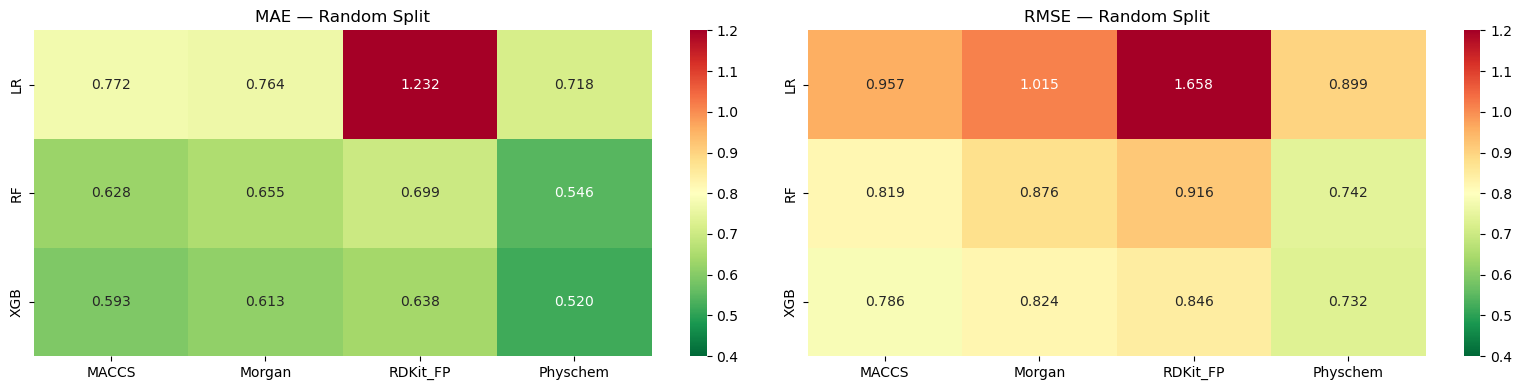

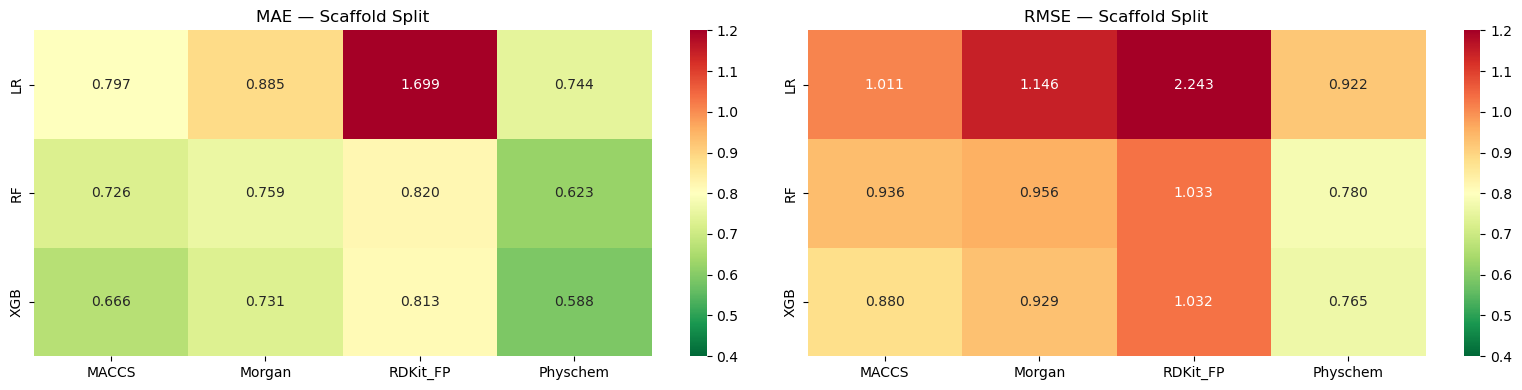


Best model per split (by MAE):
  Random: XGB_Physchem_Random — MAE=0.520, RMSE=0.732, R²=0.637
  Scaffold: XGB_Physchem_Scaffold — MAE=0.588, RMSE=0.765, R²=0.584


In [88]:
# ── Summary Table ─────────────────────────────────────────────────────────────
print("\nFull Model Comparison — Test Set Performance")
print(f"\n{'Model':<6} {'Encoding':<12} {'Split':<10} {'MAE':>8} {'RMSE':>8} {'R²':>8}   {'Best Params'}")
print("-" * 90)
for key, res in results.items():
    params_str = str(res['best_params']) if res['best_params'] is not None else 'N/A'
    print(f"{res['model_name']:<6} {res['enc']:<12} {res['split']:<10} "
          f"{res['MAE']:>8.3f} {res['RMSE']:>8.3f} {res['R2']:>8.3f}   {params_str}")

# ── Heatmaps — MAE and RMSE across all combinations ──────────────────────────
for split_name in ['Random', 'Scaffold']:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    for ax, metric in zip(axes, ['MAE', 'RMSE']):
        matrix = pd.DataFrame(
            index=['LR', 'RF', 'XGB'],
            columns=['MACCS', 'Morgan', 'RDKit_FP', 'Physchem']
        )
        for model_name in ['LR', 'RF', 'XGB']:
            for enc_name in ['MACCS', 'Morgan', 'RDKit_FP', 'Physchem']:
                key = f"{model_name}_{enc_name}_{split_name}"
                matrix.loc[model_name, enc_name] = results[key][metric]

        matrix = matrix.astype(float)
        sns.heatmap(matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
                    ax=ax, vmin=0.4, vmax=1.2)
        ax.set_title(f'{metric} — {split_name} Split')

    plt.tight_layout()
    plt.show()


# ── Identify best model overall ───────────────────────────────────────────────
print("\nBest model per split (by MAE):")
for split_name in ['Random', 'Scaffold']:
    split_results = {k: v for k, v in results.items()
                     if v['split'] == split_name}
    best_key = min(split_results, key=lambda k: split_results[k]['MAE'])
    best_res  = split_results[best_key]
    print(f"  {split_name}: {best_key} — "
          f"MAE={best_res['MAE']:.3f}, RMSE={best_res['RMSE']:.3f}, "
          f"R²={best_res['R2']:.3f}")

The results reveal consistent patterns across all 24 combinations.

**Best overall model:** XGBoost with CFS-selected physicochemical descriptors achieves the lowest MAE on both splits — **MAE=0.520, RMSE=0.732** on random split and **MAE=0.588, RMSE=0.765** on scaffold split. The RMSE of 0.732 on random split is competitive with the MoleculeNet benchmark of RMSE~0.65 reported for graph convolution models (Wu et al., 2018), which is remarkable since our approach uses simple hand-crafted descriptors rather than learned molecular representations.

**Model ranking** is consistent across all encodings and splits: XGBoost > Random Forest > Linear Regression — confirming that gradient boosting's ability to iteratively correct residual errors is well suited to the non-linear structure-property relationships in lipophilicity prediction.

**Encoding ranking** is also consistent across most  models and splits: Physchem > MACCS > Morgan > RDKit_FP — the CFS-selected physicochemical descriptors outperform all fingerprint encodings, suggesting that explicit chemical knowledge encoded in these descriptors is more informative for logD prediction than substructural pattern matching alone. RDKit fingerprints remain the weakest encoding across all models, consistent with the high feature density analysis in Section 9.

**Split effect** is clearly visible — all models show higher MAE on the scaffold split than the random split, confirming that generalising to unseen chemical series is genuinely harder. The performance gap varies by model: Linear Regression suffers the most (MAE increase of 0.025–0.467) while XGBoost is the most robust (MAE increase of 0.068–0.175), suggesting that tree-based models generalise better to new scaffolds.

**Hyperparameter patterns:** XGBoost consistently prefers `n_estimators=500` and `learning_rate=0.05–0.15` with shallow to medium depth trees (`max_depth=5–9`). Random Forest consistently prefers `max_depth=None` (fully grown trees) and `n_estimators=100–500` with `min_samples_leaf=1`, suggesting this dataset benefits from low-bias, high-variance models that are then corrected by ensemble averaging.

The best model — **XGBoost with Physchem descriptors, scaffold split** — is carried forward to Sections 12 and 13 for applicability domain analysis and explainability.

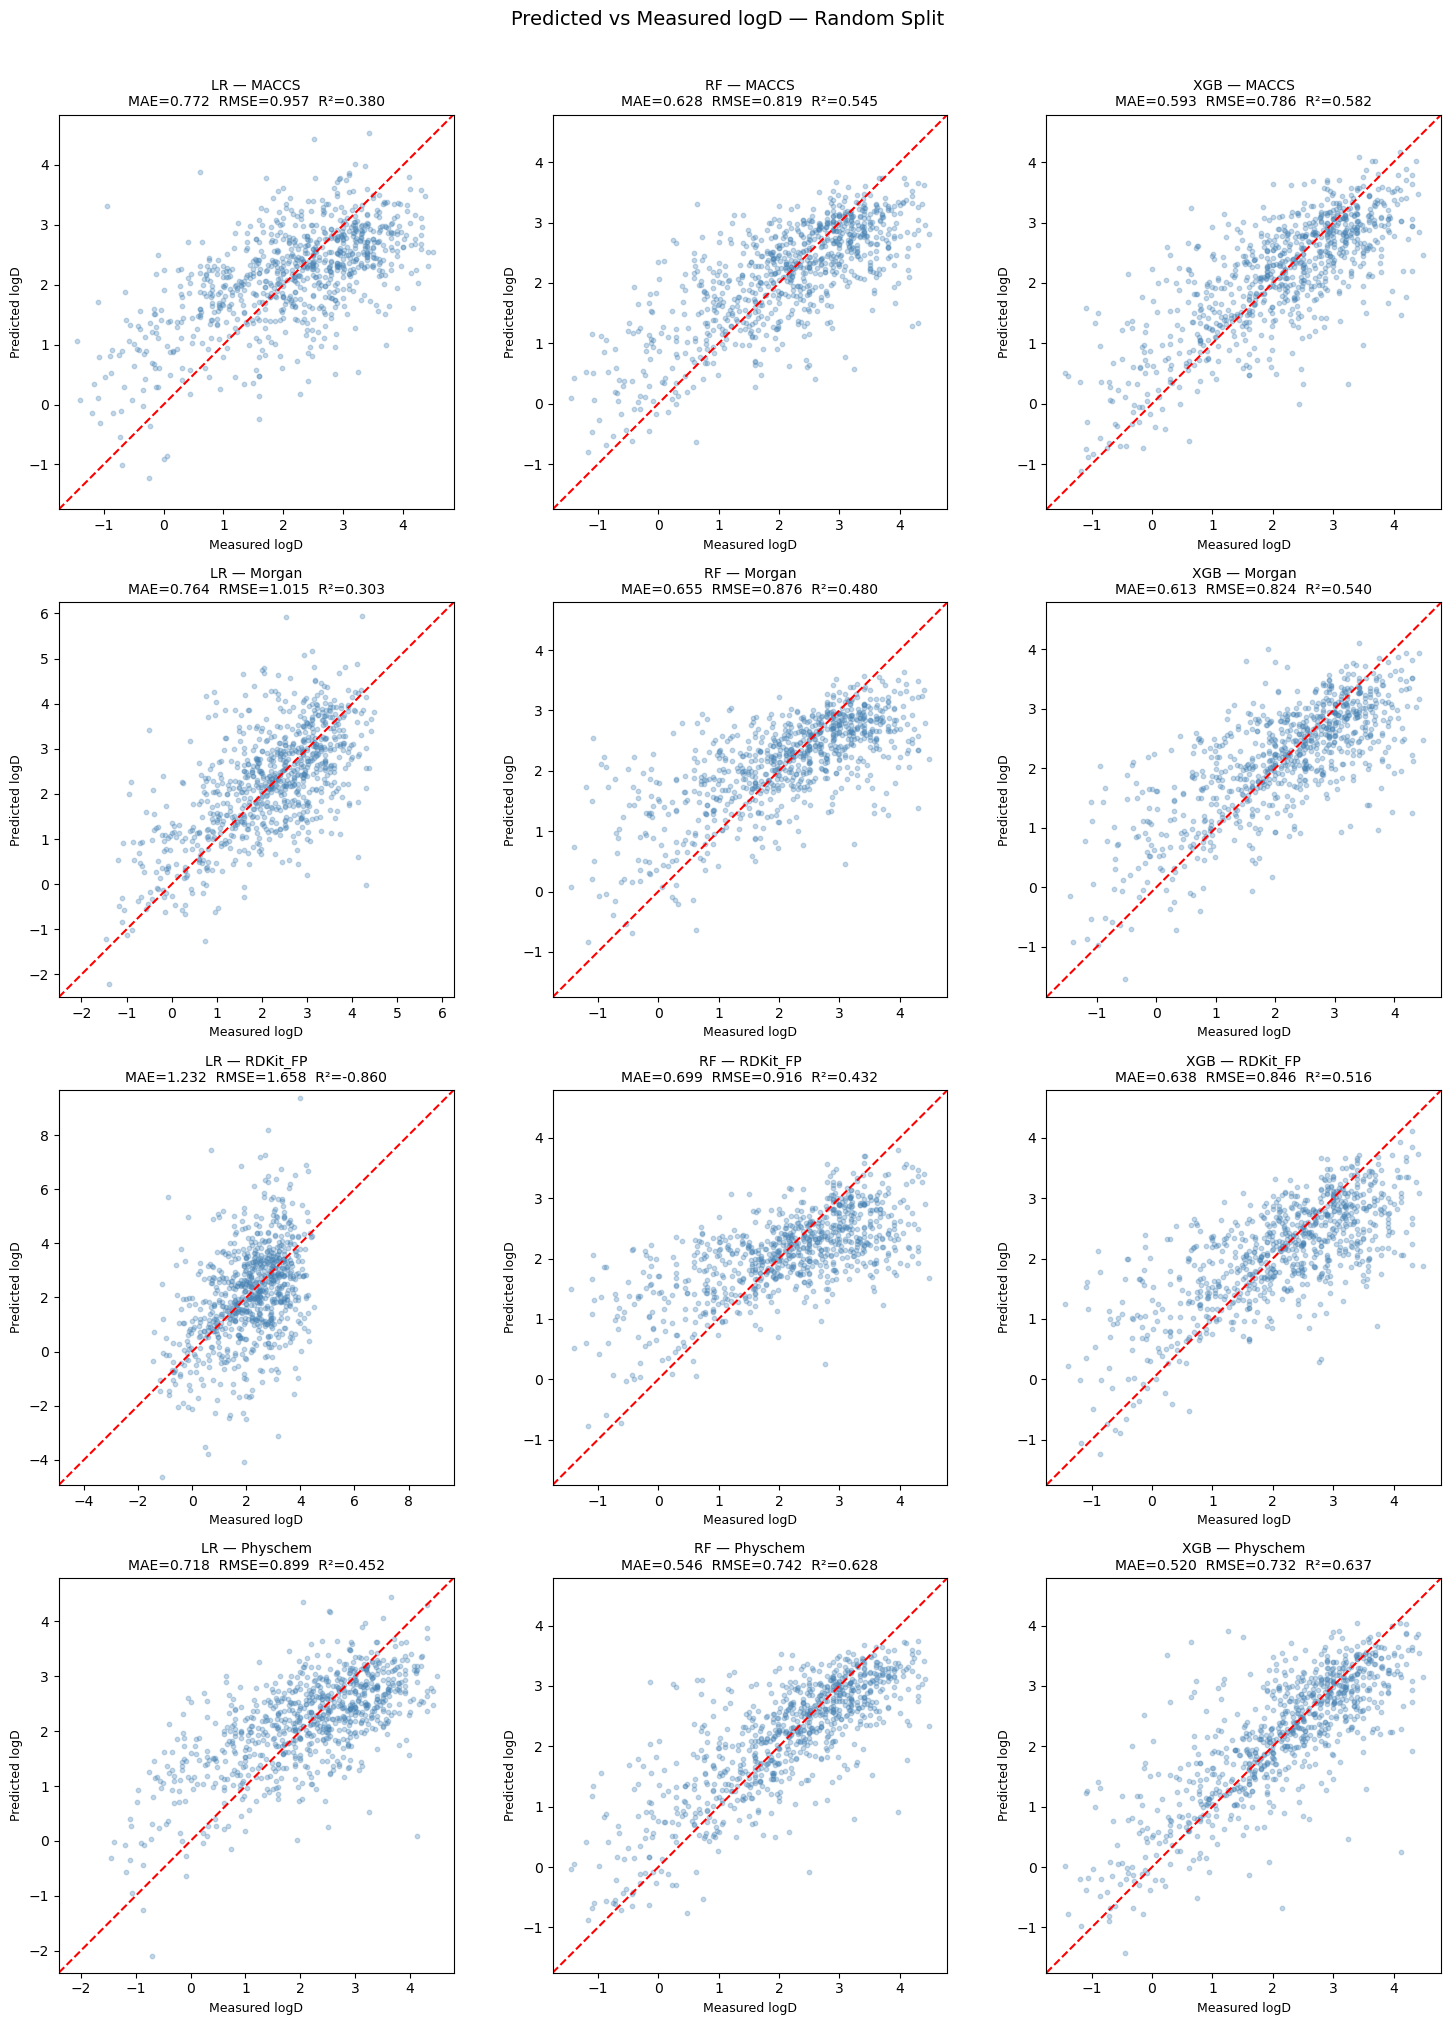

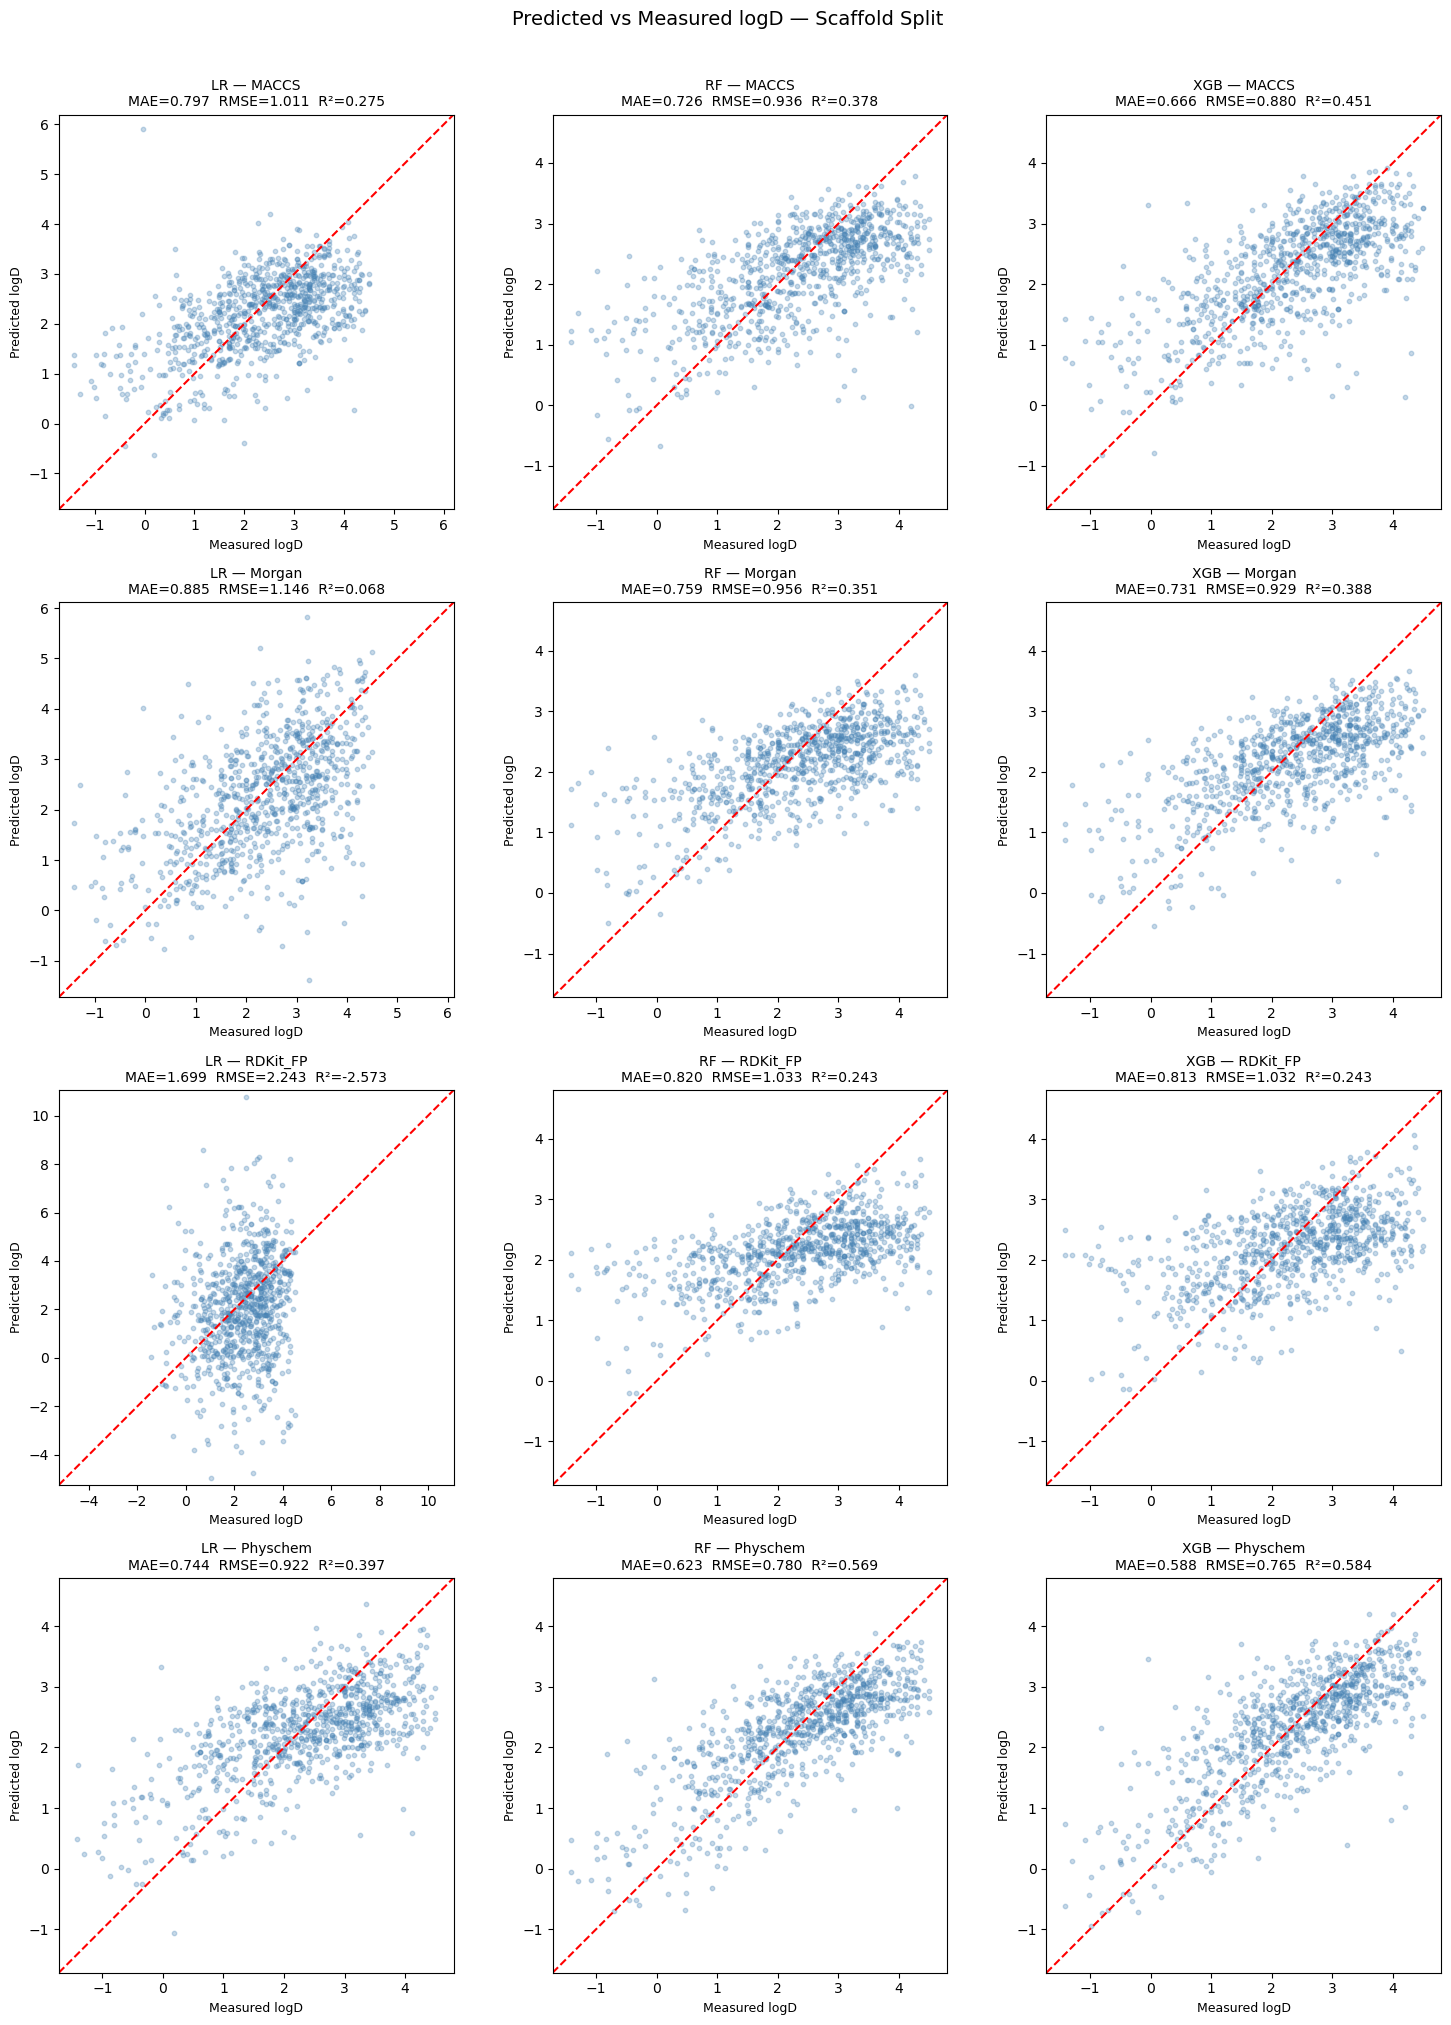

In [89]:
# ── Scatter plots — separate figure per split ─────────────────────────────────
for split_name in ['Random', 'Scaffold']:
    fig, axes = plt.subplots(4, 3, figsize=(15, 20))
    fig.suptitle(f'Predicted vs Measured logD — {split_name} Split',
                 fontsize=14, y=1.01)

    split_keys = [k for k in results.keys() if results[k]['split'] == split_name]

    for ax, key in zip(axes.flatten(), split_keys):
        res = results[key]
        ax.scatter(res['y_test'], res['y_pred'], alpha=0.3, s=10, color='steelblue')
        lim = [min(res['y_test'].min(), res['y_pred'].min()) - 0.3,
               max(res['y_test'].max(), res['y_pred'].max()) + 0.3]
        ax.plot(lim, lim, 'r--', linewidth=1.5)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_aspect('equal')
        ax.set_title(f"{res['model_name']} — {res['enc']}\n"
                     f"MAE={res['MAE']:.3f}  RMSE={res['RMSE']:.3f}  R²={res['R2']:.3f}",
                     fontsize=10)
        ax.set_xlabel('Measured logD', fontsize=9)
        ax.set_ylabel('Predicted logD', fontsize=9)

    plt.tight_layout()
    plt.show()

### Performance vs Number of Features

Having identified XGBoost with physicochemical descriptors as the best model, we now investigate how performance varies with the number of selected features. The CFS score curves in Section 10 showed diminishing returns beyond a certain number of features during cross-validation — here we verify whether this pattern holds on the actual test set with the fully tuned XGBoost model.

We retrain XGBoost using the best hyperparameters found above, progressively adding features in the order they were selected by CFS — from the most to least important according to the selection order — and evaluate MAE, RMSE and R² on the scaffold test set at each step. This analysis reveals how many features are actually needed to reach near-optimal performance, and whether the full CFS-selected set is justified or if a smaller subset would suffice.

Using best XGBoost params: {'learning_rate': 0.15, 'max_depth': 5, 'n_estimators': 500}


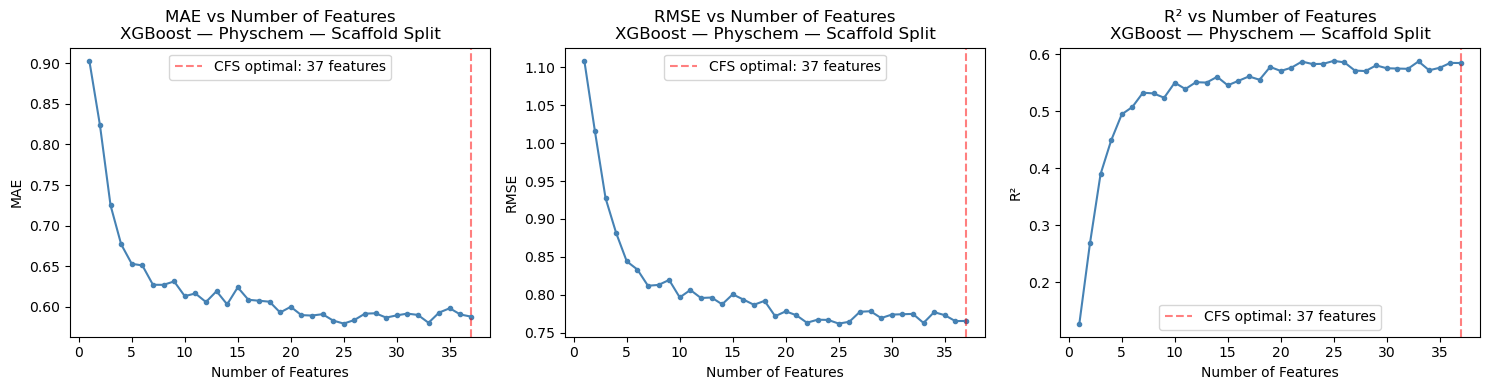

Optimal number of features by test MAE: 25
MAE at 25 features:  0.580
RMSE at 25 features: 0.762
R²  at 25 features:  0.588

Comparison at all 37 CFS-selected features:
MAE:  0.588
RMSE: 0.765
R²:   0.584


In [90]:
# ── MAE vs Number of Features — Best Model (XGBoost, Physchem, Scaffold) ──────

# Best hyperparameters from Section 11
best_xgb_params = results['XGB_Physchem_Scaffold']['best_params']
print(f"Using best XGBoost params: {best_xgb_params}")

# Features in CFS selection order
features_ordered = best_selected_cfs_xgb
n_features_range = range(1, len(features_ordered) + 1)

mae_vs_nfeatures  = []
rmse_vs_nfeatures = []
r2_vs_nfeatures   = []

for n in n_features_range:
    selected = features_ordered[:n]

    # Train/val/test sets
    X_train = df_physchem_ext.loc[idx_train_s, selected].values
    y_train = df.loc[idx_train_s, TARGET_COL].values
    X_val   = df_physchem_ext.loc[idx_valid_s, selected].values
    y_val   = df.loc[idx_valid_s, TARGET_COL].values
    X_test  = df_physchem_ext.loc[idx_test_s,  selected].values
    y_test  = df.loc[idx_test_s,  TARGET_COL].values

    # Scale
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    # Train with best hyperparameters
    model = XGBRegressor(
        **best_xgb_params,
        random_state=random_state,
        verbosity=0,
        device='cuda',
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Evaluate on test set
    y_pred = model.predict(X_test)
    mae_vs_nfeatures.append(mean_absolute_error(y_test, y_pred))
    rmse_vs_nfeatures.append(np.sqrt(np.mean((y_test - y_pred) ** 2)))
    r2_vs_nfeatures.append(r2_score(y_test, y_pred))

# Plot MAE, RMSE, and R² vs number of features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, values, label in zip(
    axes,
    ['MAE', 'RMSE', 'R²'],
    [mae_vs_nfeatures, rmse_vs_nfeatures, r2_vs_nfeatures],
    ['MAE', 'RMSE', 'R²']
):
    ax.plot(list(n_features_range), values, marker='.', color='steelblue')
    ax.axvline(len(features_ordered), color='red', linestyle='--', alpha=0.5,
               label=f'CFS optimal: {len(features_ordered)} features')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Number of Features\n'
                 f'XGBoost — Physchem — Scaffold Split')
    ax.legend()

plt.tight_layout()
plt.show()

# Print summary 
best_n = np.argmin(mae_vs_nfeatures) + 1
print(f"Optimal number of features by test MAE: {best_n}")
print(f"MAE at {best_n} features:  {mae_vs_nfeatures[best_n-1]:.3f}")
print(f"RMSE at {best_n} features: {rmse_vs_nfeatures[best_n-1]:.3f}")
print(f"R²  at {best_n} features:  {r2_vs_nfeatures[best_n-1]:.3f}")

print(f"\nComparison at all {len(features_ordered)} CFS-selected features:")
print(f"MAE:  {mae_vs_nfeatures[-1]:.3f}")
print(f"RMSE: {rmse_vs_nfeatures[-1]:.3f}")
print(f"R²:   {r2_vs_nfeatures[-1]:.3f}")

The curves confirm the diminishing returns pattern observed in the CFS score curves in Section 10, now validated on the actual test set. All three metrics improve steeply for the first 5–10 features and then plateau, with only marginal 
gains beyond 15–20 features.

Interestingly, the optimal number of features by test MAE is **25** (MAE=0.580, RMSE=0.762, R²=0.588) — slightly fewer than the 37 features selected by CFS. The difference in performance between 25 and 37 features is negligible (MAE=0.580 vs 0.588, RMSE=0.762 vs 0.765, R²=0.588 vs 0.584) — differences well within the noise of the evaluation. This confirms that CFS successfully identified a compact, non-redundant feature set where most of the predictive signal is captured by the first 20–25 features, and the remaining features provide only marginal additional value.

This finding has a practical implication — in a production setting, one could use only the top 25 CFS-selected features and achieve near-identical performance with a simpler, faster model. For this project we retain all 37 CFS-selected features as they were determined by the principled cross-validation procedure in Section 10.

### Learning Curves

Next we want to examine how performance scales with training set size — a learning curve analysis as covered in Session 5. This addresses a practical question: would collecting more training data meaningfully improve our model, or has performance already plateaued?

We train XGBoost with the best hyperparameters on progressively larger subsets of the scaffold training set and evaluate on the fixed scaffold test set at each step. We use the same random subsampling approach from Session 5, averaging over multiple repetitions to reduce variance.

Computing learning curves...
Done!


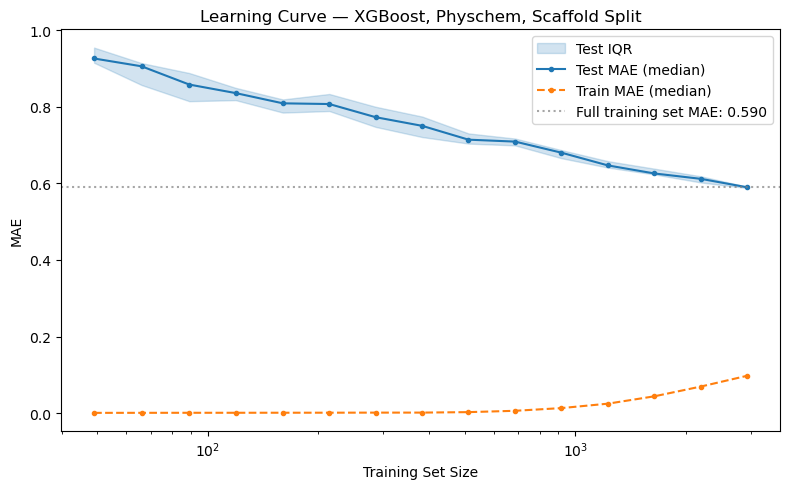


MAE at smallest training size (n=49):  0.927
MAE at full training size   (n=2939): 0.590
Improvement: 0.337 MAE units


In [91]:
# ── Learning Curves — Best Model (XGBoost, Physchem, Scaffold) ───────────────

N_REPS        = 10   # repetitions per training set size
N_POINTS      = 15   # number of training set sizes
train_sizes   = np.unique(
    np.logspace(np.log10(50), np.log10(len(idx_train_s)), N_POINTS).astype(int)
)

# Prepare full train/test sets
scaler_lc    = StandardScaler()
X_train_full = scaler_lc.fit_transform(
    df_physchem_selected_xgb.loc[idx_train_s].values)
y_train_full = df.loc[idx_train_s, TARGET_COL].values
X_test_lc    = scaler_lc.transform(
    df_physchem_selected_xgb.loc[idx_test_s].values)
y_test_lc    = df.loc[idx_test_s, TARGET_COL].values

mae_train_all = np.zeros((N_REPS, len(train_sizes)))
mae_test_all  = np.zeros((N_REPS, len(train_sizes)))

print("Computing learning curves...")
for rep in range(N_REPS):
    rng = np.random.default_rng(random_state + rep)
    for j, n in enumerate(train_sizes):
        # Randomly subsample training set
        idx = rng.choice(len(X_train_full), size=n, replace=False)
        X_tr = X_train_full[idx]
        y_tr = y_train_full[idx]

        model_lc = XGBRegressor(
            **best_xgb_params,
            random_state=random_state,
            verbosity=0,
            device='cuda',
            n_jobs=-1
        )
        model_lc.fit(X_tr, y_tr)

        mae_train_all[rep, j] = mean_absolute_error(y_tr, model_lc.predict(X_tr))
        mae_test_all[rep, j]  = mean_absolute_error(y_test_lc, model_lc.predict(X_test_lc))

print("Done!")

# Plot learning curves with median and interquartile range
fig, ax = plt.subplots(figsize=(8, 5))

# Median and confidence intervals
mae_test_median  = np.median(mae_test_all,  axis=0)
mae_train_median = np.median(mae_train_all, axis=0)
mae_test_q25     = np.percentile(mae_test_all,  25, axis=0)
mae_test_q75     = np.percentile(mae_test_all,  75, axis=0)

ax.fill_between(train_sizes, mae_test_q25, mae_test_q75,
                alpha=0.2, color='tab:blue', label='Test IQR')
ax.plot(train_sizes, mae_test_median,  color='tab:blue',
        marker='.', label='Test MAE (median)')
ax.plot(train_sizes, mae_train_median, color='tab:orange',
        marker='.', linestyle='--', label='Train MAE (median)')

ax.axhline(mae_test_median[-1], color='gray', linestyle=':', alpha=0.7,
           label=f'Full training set MAE: {mae_test_median[-1]:.3f}')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('MAE')
ax.set_xscale('log')
ax.set_title('Learning Curve — XGBoost, Physchem, Scaffold Split')
ax.legend()
plt.tight_layout()
plt.show()

# Summary
print(f"\nMAE at smallest training size (n={train_sizes[0]}):  {mae_test_median[0]:.3f}")
print(f"MAE at full training size   (n={train_sizes[-1]}): {mae_test_median[-1]:.3f}")
print(f"Improvement: {mae_test_median[0] - mae_test_median[-1]:.3f} MAE units")

The learning curve shows consistent improvement in test MAE as training set size increases — from MAE=0.927 at n=49 to MAE=0.590 at the full training set of n=2,939, an improvement of 0.337 MAE units. The curve has not fully plateaued at the full training set size, suggesting that additional training data would likely yield further gains. The train MAE (orange) starts near zero at small training sizes — indicating overfitting when data is scarce — and gradually rises to ~0.10 at the full training set size, showing that the model becomes slightly less overfit as more data is added. The gap between train and test MAE narrows consistently with more data. Overall, this dataset appears to be in a data-limited regime for scaffold-based generalisation, and expanding the training set with additional logD measurements would be expected to meaningfully improve performance.

##### Saving

In [92]:
# ── Save Models and Results ───────────────────────────────────────────────────
import joblib
import os

# Create output directory
os.makedirs('./models', exist_ok=True)

# Save all trained models
for key, res in results.items():
    joblib.dump(res['model'], f'./models/{key}.joblib')

# Save results dictionary (without model objects — too large)
results_to_save = {}
for key, res in results.items():
    results_to_save[key] = {
        'MAE':         res['MAE'],
        'RMSE':        res['RMSE'],
        'R2':          res['R2'],
        'y_pred':      res['y_pred'],
        'y_test':      res['y_test'],
        'split':       res['split'],
        'enc':         res['enc'],
        'model_name':  res['model_name'],
        'best_params': res['best_params'],
    }
joblib.dump(results_to_save, './models/results.joblib')

# Save selected features per model
joblib.dump({
    'lr':  best_selected_cfs_lr,
    'rf':  best_selected_cfs_rf,
    'xgb': best_selected_cfs_xgb,
}, './models/selected_features.joblib')

print("All models and results saved to ./models/")
print(f"Files saved: {os.listdir('./models/')}")

All models and results saved to ./models/
Files saved: ['LR_MACCS_Random.joblib', 'LR_MACCS_Scaffold.joblib', 'LR_Morgan_Random.joblib', 'LR_Morgan_Scaffold.joblib', 'LR_Physchem_Random.joblib', 'LR_Physchem_Scaffold.joblib', 'LR_RDKit_FP_Random.joblib', 'LR_RDKit_FP_Scaffold.joblib', 'results.joblib', 'RF_MACCS_Random.joblib', 'RF_MACCS_Scaffold.joblib', 'RF_Morgan_Random.joblib', 'RF_Morgan_Scaffold.joblib', 'RF_Physchem_Random.joblib', 'RF_Physchem_Scaffold.joblib', 'RF_RDKit_FP_Random.joblib', 'RF_RDKit_FP_Scaffold.joblib', 'selected_features.joblib', 'XGB_MACCS_Random.joblib', 'XGB_MACCS_Scaffold.joblib', 'XGB_Morgan_Random.joblib', 'XGB_Morgan_Scaffold.joblib', 'XGB_Physchem_Random.joblib', 'XGB_Physchem_Scaffold.joblib', 'XGB_RDKit_FP_Random.joblib', 'XGB_RDKit_FP_Scaffold.joblib']


## Section 12 — Performance vs Similarity Analysis

Having established the best model in Section 11, we now investigate a fundamental question in applied machine learning for drug discovery: **does prediction error increase as test molecules become structurally more different from the training set?**

We group test molecules into four similarity bins based on their nearest-neighbour Tanimoto similarity to the training set — computed in Section 7 — and compute MAE, RMSE and R² per bin for the best model (XGBoost, Physchem, Scaffold split). A clear degradation of performance at low similarity values would confirm that the model's predictions are less reliable for molecules that are structurally distant from the training set, justifying the definition of an applicability domain threshold.

The similarity threshold for the applicability domain is determined **empirically** from this analysis — we identify the similarity value below which prediction error increases substantially, rather than imposing an arbitrary threshold.

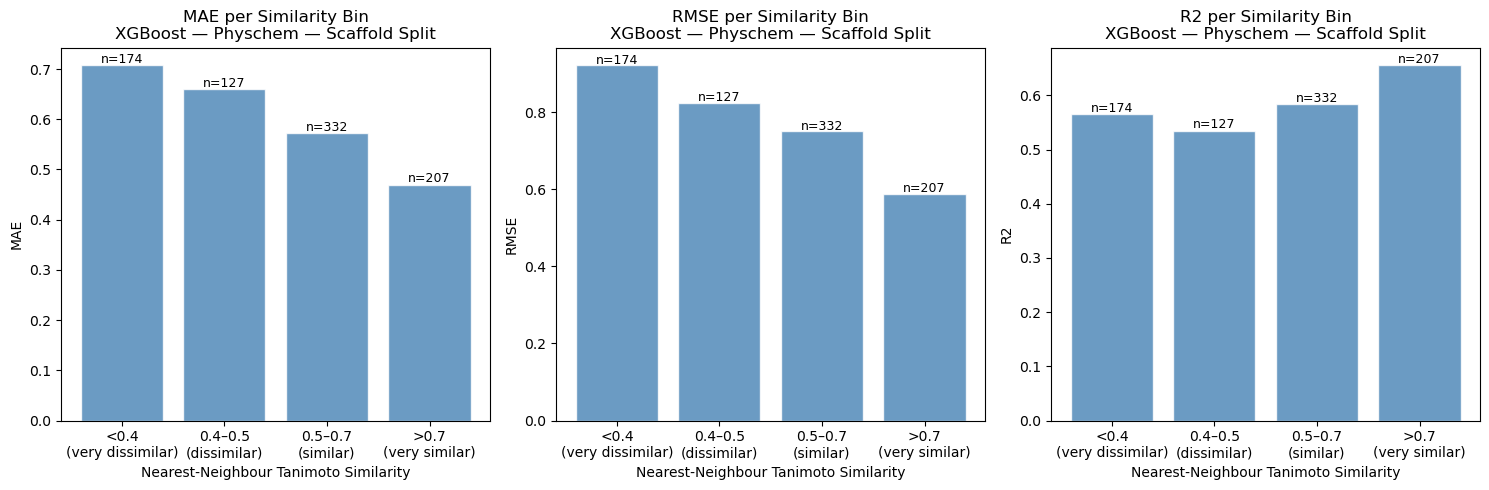


Bin                            N      MAE     RMSE       R²
-------------------------------------------------------
<0.4 (very dissimilar)       174    0.707    0.921    0.565
0.4–0.5 (dissimilar)         127    0.660    0.824    0.535
0.5–0.7 (similar)            332    0.572    0.750    0.583
>0.7 (very similar)          207    0.470    0.587    0.655


In [93]:
# ── Performance vs Similarity Analysis ──────────────────────────

# Retrieve best model
best_model_s = results['XGB_Physchem_Scaffold']['model']

# Get predictions and similarities for scaffold test set
scaler_best  = StandardScaler()
X_train_best = scaler_best.fit_transform(
    df_physchem_selected_xgb.loc[idx_train_s].values)
X_test_best  = scaler_best.transform(
    df_physchem_selected_xgb.loc[idx_test_s].values)
y_test_best  = df.loc[idx_test_s, TARGET_COL].values
y_pred_best  = best_model_s.predict(X_test_best)
nn_sim_test  = df.loc[idx_test_s, 'nn_sim_scaffold'].values

# Define four similarity bins
bins       = [0.0, 0.4, 0.5, 0.7, 1.01]
bin_labels = ['<0.4\n(very dissimilar)',
              '0.4–0.5\n(dissimilar)',
              '0.5–0.7\n(similar)',
              '>0.7\n(very similar)']

bin_indices = np.digitize(nn_sim_test, bins) - 1

# Compute metrics per bin
bin_results = []
for i, label in enumerate(bin_labels):
    mask = bin_indices == i
    n    = mask.sum()
    if n < 5:
        continue
    mae  = mean_absolute_error(y_test_best[mask], y_pred_best[mask])
    rmse = np.sqrt(np.mean((y_test_best[mask] - y_pred_best[mask]) ** 2))
    r2   = r2_score(y_test_best[mask], y_pred_best[mask])
    bin_results.append({
        'bin':  label,
        'n':    n,
        'MAE':  mae,
        'RMSE': rmse,
        'R2':   r2,
    })

df_bin = pd.DataFrame(bin_results)

# Plot metrics per similarity bin
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(df_bin['bin'], df_bin[metric],
           color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Nearest-Neighbour Tanimoto Similarity')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} per Similarity Bin\n'
                 f'XGBoost — Physchem — Scaffold Split')
    for j, (val, n) in enumerate(zip(df_bin[metric], df_bin['n'])):
        ax.text(j, val + 0.005, f'n={n}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'Bin':<25} {'N':>6} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
for _, row in df_bin.iterrows():
    print(f"{row['bin'].replace(chr(10), ' '):<25} {int(row['n']):>6} "
          f"{row['MAE']:>8.3f} {row['RMSE']:>8.3f} {row['R2']:>8.3f}")

The results confirm a clear and consistent relationship between structural similarity to the training set and prediction error. As similarity decreases, MAE and RMSE increase monotonically while R² decreases — exactly the pattern expected from the applicability domain concept introduced in Section 7.

For molecules very similar to the training set (nn_sim > 0.7, n=207), the model achieves MAE=0.470 and R²=0.655 — its best performance. For very dissimilar molecules (nn_sim < 0.4, n=174), MAE rises to 0.707 and R² drops to 0.565 — a meaningful degradation despite still being a reasonable prediction.

Interestingly, the R² plot shows a non-monotonic pattern — the dissimilar bin (0.4–0.5, n=127) has a slightly lower R² (0.535) than the very dissimilar bin (<0.4, n=174, R²=0.565). This is likely a sample size effect rather than a true pattern — the 0.4–0.5 bin contains fewer molecules (n=127 vs n=174) and R² is sensitive to sample size, making this difference unreliable. The MAE and RMSE trends remain monotonic and are therefore the more robust indicators of performance degradation with decreasing similarity.

Based on this empirical analysis, we define the **applicability domain threshold at nn_sim = 0.5** — below this value, prediction error is substantially higher and the model's predictions should be treated with caution. This threshold is used in Section 13 to flag predictions as reliable or outside the applicability domain.

Bootstrap confidence intervals for R² (n_bootstrap=1000)

Bin                            N       R²   95% CI lower   95% CI upper
----------------------------------------------------------------------
<0.4 (very dissimilar)       174    0.556          0.405          0.667
0.4–0.5 (dissimilar)         127    0.525          0.378          0.650
0.5–0.7 (similar)            332    0.581          0.486          0.665
>0.7 (very similar)          207    0.653          0.566          0.722


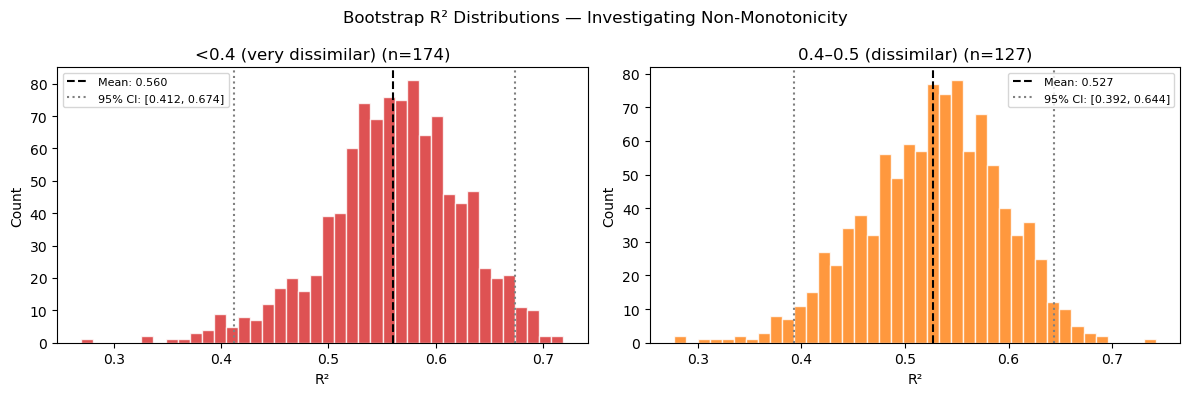

In [94]:
# ── Investigating R² non-monotonicity ────────────────────────────────────────
# The 0.4-0.5 bin shows lower R² than the <0.4 bin despite being more similar
# to training. We investigate whether this is a sample size effect by computing
# bootstrap confidence intervals for R² in each bin.

from sklearn.utils import resample

n_bootstrap = 1000
bins_to_investigate = ['<0.4\n(very dissimilar)', '0.4–0.5\n(dissimilar)']

print("Bootstrap confidence intervals for R² (n_bootstrap=1000)")
print(f"\n{'Bin':<25} {'N':>6} {'R²':>8} {'95% CI lower':>14} {'95% CI upper':>14}")
print("-" * 70)

for i, label in enumerate(bin_labels):
    mask = bin_indices == i
    n    = mask.sum()
    if n < 5:
        continue
    
    y_true_bin = y_test_best[mask]
    y_pred_bin = y_pred_best[mask]
    
    # Bootstrap R²
    r2_bootstrap = []
    for _ in range(n_bootstrap):
        y_true_bs, y_pred_bs = resample(
            y_true_bin, y_pred_bin, random_state=None
        )
        r2_bootstrap.append(r2_score(y_true_bs, y_pred_bs))
    
    r2_mean = np.mean(r2_bootstrap)
    ci_lower = np.percentile(r2_bootstrap, 2.5)
    ci_upper = np.percentile(r2_bootstrap, 97.5)
    
    print(f"{label.replace(chr(10), ' '):<25} {n:>6} {r2_mean:>8.3f} "
          f"{ci_lower:>14.3f} {ci_upper:>14.3f}")

# Plot bootstrap distributions for the two bins of interest
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Bootstrap R² Distributions — Investigating Non-Monotonicity')

for ax, i, label, color in zip(
    axes,
    [0, 1],
    ['<0.4 (very dissimilar)', '0.4–0.5 (dissimilar)'],
    ['tab:red', 'tab:orange']
):
    mask = bin_indices == i
    y_true_bin = y_test_best[mask]
    y_pred_bin = y_pred_best[mask]
    
    r2_bootstrap = [
        r2_score(*resample(y_true_bin, y_pred_bin, random_state=None))
        for _ in range(n_bootstrap)
    ]
    
    ax.hist(r2_bootstrap, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(r2_bootstrap), color='black', linestyle='--',
               label=f'Mean: {np.mean(r2_bootstrap):.3f}')
    ax.axvline(np.percentile(r2_bootstrap, 2.5), color='gray', linestyle=':',
               label=f'95% CI: [{np.percentile(r2_bootstrap, 2.5):.3f}, '
                     f'{np.percentile(r2_bootstrap, 97.5):.3f}]')
    ax.axvline(np.percentile(r2_bootstrap, 97.5), color='gray', linestyle=':')
    ax.set_xlabel('R²')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} (n={mask.sum()})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Bootstrap analysis (n=1,000 resamples, no fixed random seed to ensure independent samples across resamples) confirms this is a sample size effect rather than a genuine pattern: the 95% confidence intervals for the two bins overlap substantially ([0.405, 0.667] for <0.4 vs [0.378, 0.650] for 0.4–0.5), meaning the difference is not statistically reliable.

## Section 13 — Explainability & Applicability Domain

In this final section we address two complementary questions:

1. **What drives the model's predictions?** — we apply Permutation Feature Importance (PFI) to the best model (XGBoost, Physchem, Scaffold split) to identify which molecular descriptors most influence logD predictions. Unlike the PFI analysis in Section 10 which was a diagnostic tool for feature selection quality, this analysis is the final scientific interpretation of our model — connecting the learned feature importance back to known chemistry of lipophilicity.

2. **When can we trust the model's predictions?** — we implement the applicability domain (AD) flagging system, using the empirically determined threshold of nn_sim = 0.4 from Section 12 to flag predictions on molecules that are structurally dissimilar from the training set as potentially unreliable.

Together these two analyses provide a complete picture of what the model has learned and where it can be trusted — essential requirements for any model intended for use in a real drug discovery setting (Schroeter et al., 2007).

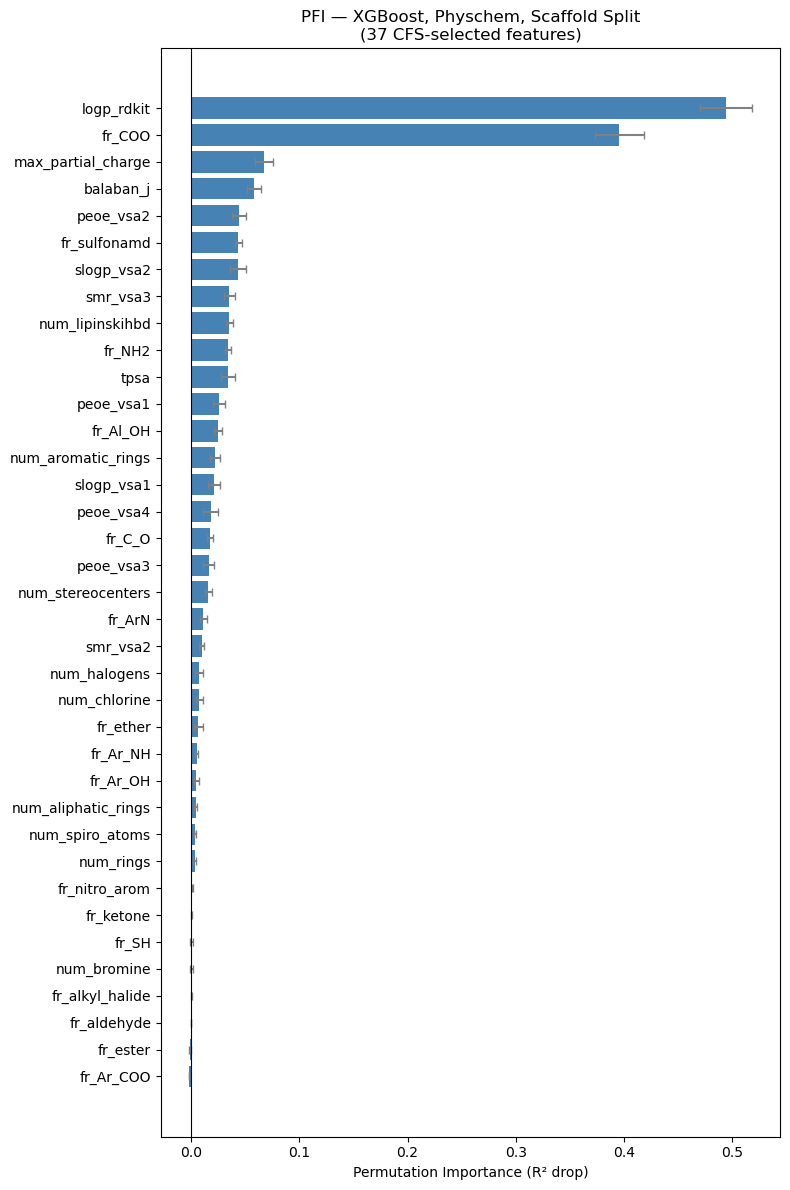


Top 10 most important features:
           feature  importance_mean  importance_std
        logp_rdkit         0.494263        0.024067
            fr_COO         0.395759        0.022627
max_partial_charge         0.067062        0.008333
         balaban_j         0.058054        0.006208
         peoe_vsa2         0.043713        0.006435
      fr_sulfonamd         0.043581        0.003621
        slogp_vsa2         0.043088        0.007447
          smr_vsa3         0.035248        0.005375
   num_lipinskihbd         0.035029        0.003365
            fr_NH2         0.034026        0.002742


In [95]:
# ── Explainability & Applicability Domain ────────────────────────────────────

# Step 1: Permutation Feature Importance on Best Model

# Retrain best model on scaffold split with selected features
scaler_pfi   = StandardScaler()
X_train_pfi  = scaler_pfi.fit_transform(
    df_physchem_selected_xgb.loc[idx_train_s].values)
X_test_pfi   = scaler_pfi.transform(
    df_physchem_selected_xgb.loc[idx_test_s].values)
y_train_pfi  = df.loc[idx_train_s, TARGET_COL].values
y_test_pfi   = df.loc[idx_test_s,  TARGET_COL].values

# Wrap as DataFrame for permutation_importance_df helper
X_test_pfi_df = pd.DataFrame(
    X_test_pfi,
    columns=best_selected_cfs_xgb,
    index=idx_test_s
)
y_test_pfi_s = pd.Series(y_test_pfi, index=idx_test_s)

# Compute PFI
df_imp_best = permutation_importance_df(
    best_model_s,
    X_test_pfi_df,
    y_test_pfi_s,
    n_repeats=10,
    random_state=random_state
)

# Plot PFI
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(df_imp_best['feature'], df_imp_best['importance_mean'],
        xerr=df_imp_best['importance_std'],
        align='center', color='steelblue', ecolor='gray', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (R² drop)')
ax.set_title('PFI — XGBoost, Physchem, Scaffold Split\n'
             f'({len(best_selected_cfs_xgb)} CFS-selected features)')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(df_imp_best.head(10).to_string(index=False))

The PFI analysis reveals a clear hierarchy of feature importance for logD prediction. **`logp_rdkit`** is by far the most important feature (importance=0.494), confirming that the octanol-water partition coefficient is the strongest predictor of logD — as expected given that logP and logD both measure lipophilicity, differing only in their treatment of ionization (Gleeson et al., 2011). **`fr_COO`** (carboxylic acid count, importance=0.396) is the second most important feature. Together these two features dominate the importance distribution, while the remaining features show a gradual and continuous decrease from `max_partial_charge` (0.067) down to near-zero importance — a direct consequence of CFS ensuring that each selected feature contributes independently. The long tail of near-zero importance features suggests these descriptors capture edge cases rather than general lipophilicity trends, but are nonetheless retained as they may improve predictions for structurally unusual molecules.

AD threshold: nn_sim >= 0.5
Inside AD:  539 molecules (64.2%)
Outside AD: 301 molecules (35.8%)

Inside AD (n=539):
  MAE:  0.533
  RMSE: 0.692

Outside AD (n=301):
  MAE:  0.687
  RMSE: 0.881


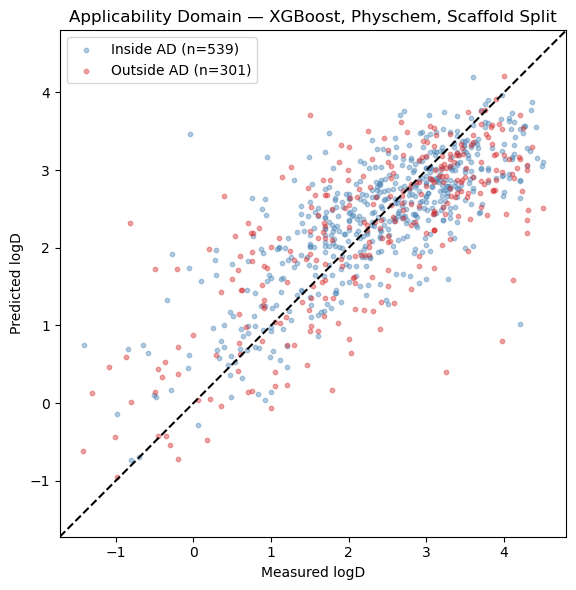

In [96]:
# ── Step 2: Applicability Domain Flagging ────────────────────────────────────

AD_THRESHOLD = 0.5  # empirically determined in Section 12

# Flag test molecules
df_test_ad = pd.DataFrame({
    'y_true':    y_test_best,
    'y_pred':    y_pred_best,
    'nn_sim':    nn_sim_test,
    'inside_AD': nn_sim_test >= AD_THRESHOLD,
    'error':     np.abs(y_test_best - y_pred_best),
})

n_inside  = df_test_ad['inside_AD'].sum()
n_outside = (~df_test_ad['inside_AD']).sum()

print(f"AD threshold: nn_sim >= {AD_THRESHOLD}")
print(f"Inside AD:  {n_inside} molecules ({n_inside/len(df_test_ad)*100:.1f}%)")
print(f"Outside AD: {n_outside} molecules ({n_outside/len(df_test_ad)*100:.1f}%)")

# Performance inside vs outside AD
for label, mask in [('Inside AD',  df_test_ad['inside_AD']),
                     ('Outside AD', ~df_test_ad['inside_AD'])]:
    subset = df_test_ad[mask]
    mae  = subset['error'].mean()
    rmse = np.sqrt((subset['error']**2).mean())
    print(f"\n{label} (n={mask.sum()}):")
    print(f"  MAE:  {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")

# Plot: predicted vs true colored by AD flag
fig, ax = plt.subplots(figsize=(7, 6))

inside  = df_test_ad[df_test_ad['inside_AD']]
outside = df_test_ad[~df_test_ad['inside_AD']]

ax.scatter(inside['y_true'],  inside['y_pred'],
           alpha=0.4, s=10, color='steelblue', label=f'Inside AD (n={n_inside})')
ax.scatter(outside['y_true'], outside['y_pred'],
           alpha=0.4, s=10, color='tab:red',   label=f'Outside AD (n={n_outside})')

lim = [df_test_ad['y_true'].min() - 0.3, df_test_ad['y_true'].max() + 0.3]
ax.plot(lim, lim, 'k--', linewidth=1.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_aspect('equal')
ax.set_xlabel('Measured logD')
ax.set_ylabel('Predicted logD')
ax.set_title('Applicability Domain — XGBoost, Physchem, Scaffold Split')
ax.legend()
plt.tight_layout()
plt.show()

With an empirically determined threshold of nn_sim = 0.5 — chosen because the largest MAE drop occurs at this boundary, with the 0.4–0.5 bin showing MAE=0.660 compared to MAE=0.572 for the 0.5–0.7 bin — **64.2% of test molecules (539 out of 840) fall inside the applicability domain** and 35.8% (301 molecules) fall outside.

The performance difference between the two groups confirms the validity of the threshold. Inside the AD, the model achieves MAE=0.533 and RMSE=0.692 — competitive performance for a classical ML model on this dataset. Outside the AD, MAE rises to 0.687 and RMSE to 0.881 — a degradation of 0.154 MAE units and 0.189 RMSE units respectively, corresponding to a 29% increase in MAE for out-of-AD molecules. This is visible in the scatter plot — outside AD molecules (red) tend to show somewhat larger deviations from the diagonal, though both groups are broadly mixed across the logD range.

This result validates the applicability domain concept — structural similarity to the training set is a meaningful indicator of prediction reliability, and users of this model should treat predictions for molecules with nn_sim < 0.5 with appropriate caution. In a real drug discovery setting, such molecules would either require experimental measurement or additional model development targeting that region of chemical space (Schroeter et al., 2007).

## Bonus — Kernel Ridge Regression with Tanimoto and Gaussian Kernels

As a bonus extension, we implement **Kernel Ridge Regression (KRR)** — the approach used by Schroeter et al. (2007) for lipophilicity prediction, which is one of the benchmark papers we reference throughout this project. KRR was also covered in Session 5 alongside the learning curves analysis.

We evaluate two variants on the scaffold split and compare directly against our best model (XGBoost, Physchem, MAE=0.588):

- **KRR with Tanimoto kernel** on Morgan fingerprints — directly connects to our similarity-based applicability domain analysis, using the same Tanimoto similarity between Morgan fingerprints that underpins Sections 7 and 12
- **KRR with Gaussian kernel** on CFS-selected physicochemical descriptors — uses the same feature set as our best XGBoost model, allowing a direct comparison between gradient boosting and kernel-based regression on identical inputs

For both variants, the regularization parameter lambda is tuned on the validation set. For the Gaussian kernel, the lengthscale is tuned as well.

In [97]:
import torch
import gpytorch
from gpytorch.kernels import Kernel
from torch import Tensor

# Kernels

class TanimotoKernel(Kernel):
    """
    Tanimoto (Jaccard) kernel for binary/real-valued fingerprint vectors.

    k(x, z) = <x, z> / (||x||² + ||z||² - <x, z>)
    """
    has_lengthscale = False

    def forward(self, x1: Tensor, x2: Tensor, **params) -> Tensor:
        dot    = torch.matmul(x1, x2.transpose(-1, -2))        # (..., n, m)
        x1_norm = x1.pow(2).sum(dim=-1, keepdim=True)          # (..., n, 1)
        x2_norm = x2.pow(2).sum(dim=-1, keepdim=True)          # (..., m, 1)
        denom  = x1_norm + x2_norm.transpose(-1, -2) - dot
        return dot / denom.clamp(min=1e-8)


class GaussianKernel(Kernel):
    """
    Gaussian (RBF) kernel.

    k(x, z) = exp(-||x - z||² / (2 * l²))

    Parameters
    ----------
    lengthscale : float, optional, default=1.0
        Initial value for the lengthscale. Can be a scalar (shared across
        all dimensions) or a tensor of shape (d,) for ARD.
    ard_num_dims : int, optional, default=None
        If set, use one lengthscale per feature dimension (ARD).
    """
    has_lengthscale = True

    def __init__(self, lengthscale: float = 1.0, **kwargs):
        super().__init__(**kwargs)
        self.lengthscale = lengthscale

    def forward(self, x1: Tensor, x2: Tensor, **params) -> Tensor:
        diff = x1.unsqueeze(-2) - x2.unsqueeze(-3)             # (..., n, m, d)
        sq_dist = diff.pow(2).sum(dim=-1)                       # (..., n, m)
        return torch.exp(-sq_dist / (2 * self.lengthscale ** 2))
    
# Kernel Ridge Regression

class KRR:
    """
    Kernel Ridge Regression with a pluggable kernel.

    Closed-form solution:  alpha = (K + lambda * I)^{-1} y
    Prediction:            y*    = K(X*, X) @ alpha

    Parameters
    ----------
    kernel : Kernel
        Any GPyTorch Kernel instance, e.g. TanimotoKernel() or GaussianKernel().
    lam : float, default=1e-2
        Regularization strength (ridge penalty).

    Examples
    --------
    >>> model = KRR(kernel=TanimotoKernel(), lam=1e-2)
    >>> model = KRR(kernel=GaussianKernel(), lam=1e-2)
    >>> # Fix the lengthscale manually for the Gaussian kernel
    >>> gk = GaussianKernel(); gk.lengthscale = 1.0
    >>> model = KRR(kernel=gk, lam=1e-2)
    """
    def __init__(self, kernel: Kernel, lam: float = 1e-2):
        self.kernel = kernel
        self.lam = lam
        self.alpha = None
        self.X_train = None

    def fit(self, X: Tensor, y: Tensor):
        self.X_train = X
        with torch.no_grad():
            K = self.kernel(X, X).evaluate()
            n = K.shape[0]
            A = K + self.lam * torch.eye(n)
            L = torch.linalg.cholesky(A) # A = L @ L^T
            self.alpha = torch.cholesky_solve(y.unsqueeze(-1), L).squeeze(-1)

    def predict(self, X_test: Tensor) -> Tensor:
        with torch.no_grad():
            K_star = self.kernel(X_test, self.X_train).evaluate()
            return K_star @ self.alpha

Tuning KRR Tanimoto lambda on validation set...
  lambda=1e-04   Val MAE=0.637
  lambda=1e-03   Val MAE=0.637
  lambda=1e-02   Val MAE=0.635
  lambda=1e-01   Val MAE=0.633
  lambda=1e+00   Val MAE=0.667
  lambda=1e+01   Val MAE=0.787

Best lambda: 0.1 (Val MAE=0.633)

KRR Tanimoto — Morgan — Scaffold:
  MAE: 0.664   RMSE: 0.847   R²: 0.490

Tuning KRR Gaussian lambda and lengthscale on validation set...
Best lambda=0.1, lengthscale=5.0 (Val MAE=0.554)

KRR Gaussian — Physchem — Scaffold:
  MAE: 0.597   RMSE: 0.793   R²: 0.554

Model                                    MAE     RMSE       R²
---------------------------------------------------------------
XGBoost Physchem Scaffold              0.588    0.765    0.584
KRR Tanimoto Morgan Scaffold           0.664    0.847    0.490
KRR Gaussian Physchem Scaffold         0.597    0.793    0.554


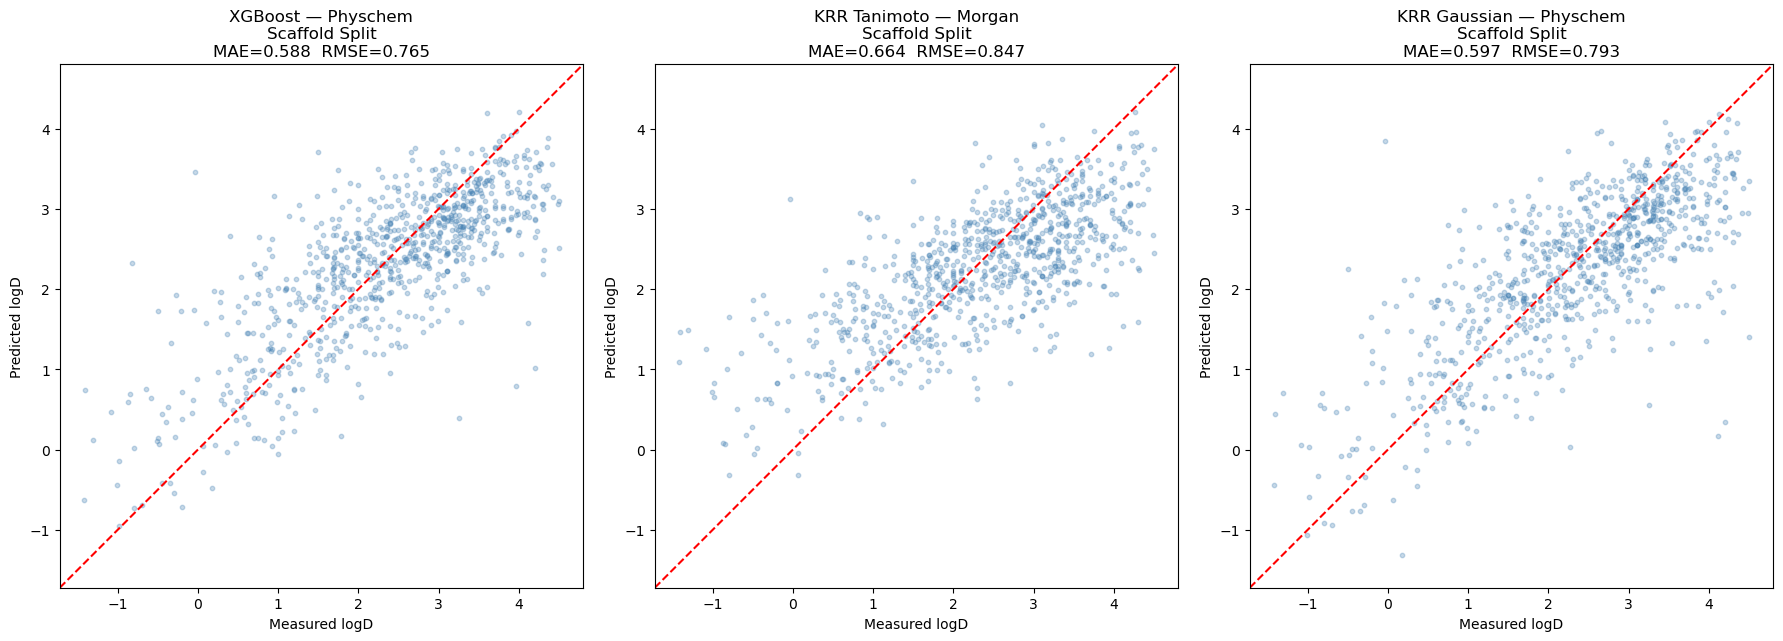

In [98]:
# ── Bonus — KRR with Tanimoto and Gaussian Kernels ───────────────────────────

# ── KRR Tanimoto — Morgan fingerprints ───────────────────────────────────────
X_train_krr = torch.from_numpy(
    df_morgan.loc[idx_train_s].values.astype(np.float32))
y_train_krr = torch.from_numpy(
    df.loc[idx_train_s, TARGET_COL].values.astype(np.float32))
X_val_krr   = torch.from_numpy(
    df_morgan.loc[idx_valid_s].values.astype(np.float32))
y_val_krr   = torch.from_numpy(
    df.loc[idx_valid_s, TARGET_COL].values.astype(np.float32))
X_test_krr  = torch.from_numpy(
    df_morgan.loc[idx_test_s].values.astype(np.float32))
y_test_krr  = df.loc[idx_test_s, TARGET_COL].values

# Tune lambda on validation set
lam_grid     = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
best_val_mae = np.inf
best_lam     = None

print("Tuning KRR Tanimoto lambda on validation set...")
for lam in lam_grid:
    model_krr = KRR(kernel=TanimotoKernel(), lam=lam)
    model_krr.fit(X_train_krr, y_train_krr)
    val_mae   = mean_absolute_error(y_val_krr.numpy(),
                                    model_krr.predict(X_val_krr).numpy())
    print(f"  lambda={lam:.0e}   Val MAE={val_mae:.3f}")
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_lam     = lam

print(f"\nBest lambda: {best_lam} (Val MAE={best_val_mae:.3f})")

# Train final Tanimoto KRR
model_krr_final = KRR(kernel=TanimotoKernel(), lam=best_lam)
model_krr_final.fit(X_train_krr, y_train_krr)
y_pred_krr = model_krr_final.predict(X_test_krr).numpy()

mae_krr  = mean_absolute_error(y_test_krr, y_pred_krr)
rmse_krr = np.sqrt(np.mean((y_test_krr - y_pred_krr) ** 2))
r2_krr   = r2_score(y_test_krr, y_pred_krr)

print(f"\nKRR Tanimoto — Morgan — Scaffold:")
print(f"  MAE: {mae_krr:.3f}   RMSE: {rmse_krr:.3f}   R²: {r2_krr:.3f}")

# ── KRR Gaussian — Physchem descriptors ──────────────────────────────────────
scaler_krr   = StandardScaler()
X_train_gk   = torch.from_numpy(
    scaler_krr.fit_transform(
        df_physchem_selected_xgb.loc[idx_train_s].values
    ).astype(np.float32))
X_val_gk     = torch.from_numpy(
    scaler_krr.transform(
        df_physchem_selected_xgb.loc[idx_valid_s].values
    ).astype(np.float32))
X_test_gk    = torch.from_numpy(
    scaler_krr.transform(
        df_physchem_selected_xgb.loc[idx_test_s].values
    ).astype(np.float32))

# Tune lambda and lengthscale on validation set
lam_grid         = [1e-3, 1e-2, 1e-1, 1.0]
lengthscale_grid = [0.5, 1.0, 2.0, 5.0]
best_val_mae_gk  = np.inf
best_lam_gk      = None
best_ls_gk       = None

print("\nTuning KRR Gaussian lambda and lengthscale on validation set...")
for lam in lam_grid:
    for ls in lengthscale_grid:
        gk      = GaussianKernel(lengthscale=ls)
        m       = KRR(kernel=gk, lam=lam)
        m.fit(X_train_gk, y_train_krr)
        val_mae = mean_absolute_error(
            y_val_krr.numpy(), m.predict(X_val_gk).numpy())
        if val_mae < best_val_mae_gk:
            best_val_mae_gk = val_mae
            best_lam_gk     = lam
            best_ls_gk      = ls

print(f"Best lambda={best_lam_gk}, lengthscale={best_ls_gk} "
      f"(Val MAE={best_val_mae_gk:.3f})")

# Train final Gaussian KRR
gk_final   = GaussianKernel(lengthscale=best_ls_gk)
model_gkrr = KRR(kernel=gk_final, lam=best_lam_gk)
model_gkrr.fit(X_train_gk, y_train_krr)
y_pred_gkrr = model_gkrr.predict(X_test_gk).numpy()

mae_gkrr  = mean_absolute_error(y_test_krr, y_pred_gkrr)
rmse_gkrr = np.sqrt(np.mean((y_test_krr - y_pred_gkrr) ** 2))
r2_gkrr   = r2_score(y_test_krr, y_pred_gkrr)

print(f"\nKRR Gaussian — Physchem — Scaffold:")
print(f"  MAE: {mae_gkrr:.3f}   RMSE: {rmse_gkrr:.3f}   R²: {r2_gkrr:.3f}")

# ── Final comparison ──────────────────────────────────────────────────────────
print(f"\n{'Model':<35} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 63)
print(f"{'XGBoost Physchem Scaffold':<35} {'0.588':>8} {'0.765':>8} {'0.584':>8}")
print(f"{'KRR Tanimoto Morgan Scaffold':<35} {mae_krr:>8.3f} {rmse_krr:>8.3f} {r2_krr:>8.3f}")
print(f"{'KRR Gaussian Physchem Scaffold':<35} {mae_gkrr:>8.3f} {rmse_gkrr:>8.3f} {r2_gkrr:>8.3f}")

# ── Scatter plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, y_pred, title, mae, rmse in zip(
    axes,
    [results['XGB_Physchem_Scaffold']['y_pred'], y_pred_krr, y_pred_gkrr],
    ['XGBoost — Physchem', 'KRR Tanimoto — Morgan', 'KRR Gaussian — Physchem'],
    [0.588, mae_krr, mae_gkrr],
    [0.765, rmse_krr, rmse_gkrr],
):
    ax.scatter(y_test_krr, y_pred, alpha=0.3, s=10, color='steelblue')
    lim = [min(y_test_krr.min(), y_pred.min()) - 0.3,
           max(y_test_krr.max(), y_pred.max()) + 0.3]
    ax.plot(lim, lim, 'r--', linewidth=1.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel('Measured logD')
    ax.set_ylabel('Predicted logD')
    ax.set_title(f'{title}\nScaffold Split\n'
                 f'MAE={mae:.3f}  RMSE={rmse:.3f}')

plt.tight_layout()
plt.show()

The results reveal an interesting pattern across the three models. **KRR Tanimoto** (MAE=0.664) is the weakest of the three — consistent with the 
fingerprint-based models from Section 11 where Morgan fingerprints alone were less informative than physicochemical descriptors for logD prediction.

**KRR Gaussian** with physicochemical descriptors (MAE=0.597, RMSE=0.793) performs remarkably close to XGBoost (MAE=0.588, RMSE=0.765) — a difference of only 0.009 MAE units. This is a noteworthy finding: a simple kernel method with a single lengthscale parameter (ls=5.0, lambda=0.1) achieves nearly identical performance to a gradient boosted model with 500 trees and carefully tuned hyperparameters. This suggests that the physicochemical descriptor space has a smooth, well-structured relationship with logD that can be captured effectively by a Gaussian kernel — and that XGBoost's additional complexity provides only marginal gains.

The scatter plots confirm these findings visually — XGBoost and KRR Gaussian show very similar prediction quality and scatter around the diagonal, while KRR Tanimoto shows noticeably more scatter throughout the logD range.